# Wildfire ML Project — Temporal-Windowed Exploratory Modeling

This notebook consolidates the original temporal-windowed exploratory analysis. The final row-level one-day benchmark is handled in the companion notebook.

In [ ]:
# =========================
# Runtime tracker
# =========================
import os
import time
from datetime import datetime

# Keep linear algebra and tree learners from oversubscribing CPU threads.
# This makes the notebook more stable in Colab and local notebook runtimes.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

NOTEBOOK_START_TIME = time.time()
print(f"[START] Notebook started at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

[START] Notebook started at 2026-05-08 02:06:30


## 1. Colab setup and imports

The notebook is written for Colab. It also runs locally when the dataset path is available. GPU is used automatically for PyTorch and XGBoost if the runtime supports it.

In [ ]:
# Safe to run more than once in Colab.
%pip install -q numpy pandas matplotlib scipy statsmodels scikit-learn xgboost torch packaging

In [ ]:
# =========================
# Imports
# =========================
import os
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Sequence, Tuple, Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from packaging.version import parse as parse_version
from scipy import stats
from statsmodels.tsa.stattools import acf as compute_acf, pacf as compute_pacf

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
import xgboost

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## 2. Configuration

All important settings are centralized here. Standard ML names like `X_train` and `y_train` are used where appropriate; otherwise, names describe the object being stored.

In [ ]:
# =========================
# Project configuration
# =========================
DATE_COL = "DATE"
TARGET_COL = "FIRE_START_DAY"
RANDOM_STATE = 42
TEMPORAL_INPUT_WINDOW_SIZE = 6
WINDOW_SIZE = TEMPORAL_INPUT_WINDOW_SIZE  # Backward-compatible alias used by existing helper functions.
ENGINEERING_WINDOWS = [3, 7, 14]
DATA_CUTOFF = "2023-12-31"

PRIMARY_TRAIN_YEARS = (1984, 2017)
PRIMARY_VAL_YEARS = (2018, 2020)
PRIMARY_TEST_YEARS = (2021, 2023)

BROAD_HORIZONS = [1, 3, 7, 10, 14, 21, 30]
SHORTLIST_HORIZONS = [1, 3, 7, 10]

# Runtime switches. Keep these True for the full project run.
RUN_TEMPORAL_EDA = True
RUN_PRIMARY_MODELS = True
RUN_RECENT_HISTORY_SENSITIVITY = True
RUN_FEATURE_ABLATION = True
RUN_BROAD_HORIZON_SWEEP = True
RUN_SHORTLIST_SWEEP = True
RUN_TEMPORAL_ROBUSTNESS = True
RUN_ADVANCED_MODELS = True
RUN_SEQUENCE_MODELS = True
RUN_TEMPORAL_WINDOWED_CALIBRATION = True

# Set FAST_RUN=True only to debug notebook structure. Final results should use False.
FAST_RUN = False
SAVE_OUTPUTS = True
OUTPUT_DIR = Path("/content/wildfire_temporal_windowed_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

USE_CUDA = torch.cuda.is_available()
TORCH_DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
XGB_DEVICE = "cuda" if USE_CUDA else "cpu"
# Bound XGBoost CPU threads to avoid oversubscription in Colab/local runtimes.
XGB_N_JOBS = min(4, os.cpu_count() or 1)

BASE_FEATURES = [
    "PRECIPITATION",
    "MAX_TEMP",
    "MIN_TEMP",
    "AVG_WIND_SPEED",
    "TEMP_RANGE",
    "WIND_TEMP_RATIO",
    "MONTH",
    "DAY_OF_YEAR",
    "LAGGED_PRECIPITATION",
    "LAGGED_AVG_WIND_SPEED",
    "SEASON_ENC",
]

WEATHER_FEATURES = [
    "PRECIPITATION",
    "MAX_TEMP",
    "MIN_TEMP",
    "AVG_WIND_SPEED",
    "TEMP_RANGE",
    "WIND_TEMP_RATIO",
    "LAGGED_PRECIPITATION",
    "LAGGED_AVG_WIND_SPEED",
]

CALENDAR_FEATURES = ["MONTH", "DAY_OF_YEAR", "SEASON_ENC"]

KEEPER_FEATURE_SET_BY_HORIZON = {
    1: "baseline_features",
    3: "engineered_features",
    7: "engineered_features",
    10: "engineered_features",
}


def set_global_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(RANDOM_STATE)

print(f"Temporal input window size: {TEMPORAL_INPUT_WINDOW_SIZE} rows")
print(f"Engineered feature windows: {ENGINEERING_WINDOWS}")
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {USE_CUDA}")
print(f"Torch device: {TORCH_DEVICE}")
print(f"XGBoost version: {xgboost.__version__}")
print(f"XGBoost device target: {XGB_DEVICE}")

Temporal input window size: 6 rows
Engineered feature windows: [3, 7, 14]
Torch version: 2.10.0+cu128
CUDA available: True
Torch device: cuda
XGBoost version: 3.2.0
XGBoost device target: cuda


## 3. Data path resolution

In Colab, place the CSV in the top level of Google Drive or upload it into `/content`. The code checks common locations before raising an error.

In [ ]:
# =========================
# Data path resolution
# =========================
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Not running inside Colab, or Google Drive mount was skipped.")

candidate_data_paths = [
    Path("/content/drive/MyDrive/CA_Weather_Fire_Dataset_1984-2025.csv"),
    Path("/content/drive/MyDrive/CA_Weather_Fire_Dataset_1984-2025(2).csv"),
    Path("/content/CA_Weather_Fire_Dataset_1984-2025.csv"),
    Path("/content/CA_Weather_Fire_Dataset_1984-2025(2).csv"),
    Path("/mnt/data/CA_Weather_Fire_Dataset_1984-2025.csv"),
    Path("/mnt/data/CA_Weather_Fire_Dataset_1984-2025(2).csv"),
]

wildfire_dataset_path = None
for candidate_path in candidate_data_paths:
    if candidate_path.exists():
        wildfire_dataset_path = candidate_path
        break

if wildfire_dataset_path is None:
    raise FileNotFoundError(
        "Could not find the dataset CSV. Upload it to Colab or place it in the top level of Google Drive."
    )

print(f"Using dataset: {wildfire_dataset_path}")

Mounted at /content/drive
Using dataset: /content/drive/MyDrive/CA_Weather_Fire_Dataset_1984-2025.csv


## 4. Shared data, modeling, and evaluation helpers

In [ ]:
# =========================
# Data loading and feature engineering
# =========================
def load_daily_data(dataset_path: Path, cutoff_date: str = DATA_CUTOFF) -> pd.DataFrame:
    daily_data = pd.read_csv(dataset_path).copy()
    daily_data[DATE_COL] = pd.to_datetime(daily_data[DATE_COL])
    daily_data = daily_data.sort_values(DATE_COL).reset_index(drop=True)

    if "SEASON_ENC" not in daily_data.columns:
        if "SEASON" not in daily_data.columns:
            raise KeyError("Expected either SEASON or SEASON_ENC in the daily dataset.")
        season_values = sorted(daily_data["SEASON"].dropna().unique().tolist())
        season_to_code = {season: idx for idx, season in enumerate(season_values)}
        daily_data["SEASON_ENC"] = daily_data["SEASON"].map(season_to_code)

    daily_data[TARGET_COL] = daily_data[TARGET_COL].astype(int)

    if cutoff_date is not None:
        daily_data = daily_data.loc[daily_data[DATE_COL] <= pd.to_datetime(cutoff_date)].copy()

    return daily_data.reset_index(drop=True)


def build_engineered_feature_names(engineering_windows: Sequence[int] = ENGINEERING_WINDOWS) -> List[str]:
    """Return the systematic 3/7/14-day engineered feature names used in the temporal-windowed formulation."""
    feature_names: List[str] = []
    for window_size in engineering_windows:
        feature_names.extend([
            f"PRECIP_{window_size}DAY_SUM",
            f"MAX_TEMP_{window_size}DAY_MEAN",
            f"MIN_TEMP_{window_size}DAY_MEAN",
            f"WIND_{window_size}DAY_MEAN",
            f"WIND_{window_size}DAY_MAX",
            f"DRY_DAYS_LAST_{window_size}",
            f"HOT_DAYS_LAST_{window_size}",
            f"WINDY_DAYS_LAST_{window_size}",
            f"HOT_AND_DRY_LAST_{window_size}",
            f"HOT_AND_WINDY_LAST_{window_size}",
            f"DRY_AND_WINDY_LAST_{window_size}",
        ])
    feature_names.extend(["MAX_TEMP_ANOMALY", "PRECIP_ANOMALY"])
    return feature_names


def make_engineered_feature_summary(engineering_windows: Sequence[int] = ENGINEERING_WINDOWS) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "feature_family": "Precipitation accumulation",
            "windows": ", ".join(map(str, engineering_windows)),
            "example": f"PRECIP_{engineering_windows[-1]}DAY_SUM",
            "purpose": "recent/weekly/biweekly moisture accumulation",
        },
        {
            "feature_family": "Temperature means",
            "windows": ", ".join(map(str, engineering_windows)),
            "example": f"MAX_TEMP_{engineering_windows[1]}DAY_MEAN",
            "purpose": "recent heat persistence",
        },
        {
            "feature_family": "Wind mean and max",
            "windows": ", ".join(map(str, engineering_windows)),
            "example": f"WIND_{engineering_windows[0]}DAY_MAX",
            "purpose": "average wind conditions and recent wind spikes",
        },
        {
            "feature_family": "Dry/hot/windy day counts",
            "windows": ", ".join(map(str, engineering_windows)),
            "example": f"DRY_DAYS_LAST_{engineering_windows[0]}",
            "purpose": "condition persistence over matched windows",
        },
        {
            "feature_family": "Compound condition counts",
            "windows": ", ".join(map(str, engineering_windows)),
            "example": f"HOT_AND_DRY_LAST_{engineering_windows[-1]}",
            "purpose": "co-occurrence of high-risk weather conditions",
        },
        {
            "feature_family": "Day-of-year anomalies",
            "windows": "seasonal baseline",
            "example": "MAX_TEMP_ANOMALY",
            "purpose": "deviation from training-period seasonal norms",
        },
    ])


def add_engineered_daily_features(
    daily_data: pd.DataFrame,
    train_end_year: int = PRIMARY_TRAIN_YEARS[1],
    engineering_windows: Sequence[int] = ENGINEERING_WINDOWS,
) -> pd.DataFrame:
    """Add a systematic rolling-feature grid for the temporal-windowed formulation.

    The final row-level one-day benchmark does not use these manually constructed rolling
    features as primary inputs. They are retained here for the exploratory temporal-windowed
    analysis, where the goal is to compare short-, weekly-, and biweekly-scale summaries.
    """
    engineered_data = daily_data.copy().sort_values(DATE_COL).reset_index(drop=True)

    training_period_data = engineered_data.loc[engineered_data[DATE_COL].dt.year <= train_end_year].copy()
    hot_threshold = training_period_data["MAX_TEMP"].quantile(0.80)
    windy_threshold = training_period_data["AVG_WIND_SPEED"].quantile(0.80)
    dry_threshold = training_period_data["PRECIPITATION"].quantile(0.20)

    engineered_data["IS_DRY_DAY"] = (engineered_data["PRECIPITATION"] <= dry_threshold).astype(int)
    engineered_data["IS_HOT_DAY"] = (engineered_data["MAX_TEMP"] >= hot_threshold).astype(int)
    engineered_data["IS_WINDY_DAY"] = (engineered_data["AVG_WIND_SPEED"] >= windy_threshold).astype(int)
    engineered_data["HOT_AND_DRY_DAY"] = (engineered_data["IS_HOT_DAY"] & engineered_data["IS_DRY_DAY"]).astype(int)
    engineered_data["HOT_AND_WINDY_DAY"] = (engineered_data["IS_HOT_DAY"] & engineered_data["IS_WINDY_DAY"]).astype(int)
    engineered_data["DRY_AND_WINDY_DAY"] = (engineered_data["IS_DRY_DAY"] & engineered_data["IS_WINDY_DAY"]).astype(int)

    for window_size in engineering_windows:
        engineered_data[f"PRECIP_{window_size}DAY_SUM"] = engineered_data["PRECIPITATION"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"MAX_TEMP_{window_size}DAY_MEAN"] = engineered_data["MAX_TEMP"].rolling(window_size, min_periods=1).mean()
        engineered_data[f"MIN_TEMP_{window_size}DAY_MEAN"] = engineered_data["MIN_TEMP"].rolling(window_size, min_periods=1).mean()
        engineered_data[f"WIND_{window_size}DAY_MEAN"] = engineered_data["AVG_WIND_SPEED"].rolling(window_size, min_periods=1).mean()
        engineered_data[f"WIND_{window_size}DAY_MAX"] = engineered_data["AVG_WIND_SPEED"].rolling(window_size, min_periods=1).max()
        engineered_data[f"DRY_DAYS_LAST_{window_size}"] = engineered_data["IS_DRY_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"HOT_DAYS_LAST_{window_size}"] = engineered_data["IS_HOT_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"WINDY_DAYS_LAST_{window_size}"] = engineered_data["IS_WINDY_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"HOT_AND_DRY_LAST_{window_size}"] = engineered_data["HOT_AND_DRY_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"HOT_AND_WINDY_LAST_{window_size}"] = engineered_data["HOT_AND_WINDY_DAY"].rolling(window_size, min_periods=1).sum()
        engineered_data[f"DRY_AND_WINDY_LAST_{window_size}"] = engineered_data["DRY_AND_WINDY_DAY"].rolling(window_size, min_periods=1).sum()

    day_of_year_temp_mean = training_period_data.groupby("DAY_OF_YEAR")["MAX_TEMP"].mean()
    day_of_year_precip_mean = training_period_data.groupby("DAY_OF_YEAR")["PRECIPITATION"].mean()
    engineered_data["MAX_TEMP_DOY_BASELINE"] = engineered_data["DAY_OF_YEAR"].map(day_of_year_temp_mean)
    engineered_data["PRECIP_DOY_BASELINE"] = engineered_data["DAY_OF_YEAR"].map(day_of_year_precip_mean)
    engineered_data["MAX_TEMP_ANOMALY"] = engineered_data["MAX_TEMP"] - engineered_data["MAX_TEMP_DOY_BASELINE"]
    engineered_data["PRECIP_ANOMALY"] = engineered_data["PRECIPITATION"] - engineered_data["PRECIP_DOY_BASELINE"]

    expected_features = build_engineered_feature_names(engineering_windows)
    missing_features = [feature_name for feature_name in expected_features if feature_name not in engineered_data.columns]
    if missing_features:
        raise KeyError(f"Engineered feature generation missed expected columns: {missing_features}")

    return engineered_data


ENGINEERED_ONLY_FEATURES = build_engineered_feature_names(ENGINEERING_WINDOWS)
FULL_ENGINEERED_FEATURES = BASE_FEATURES + ENGINEERED_ONLY_FEATURES


def build_feature_source_map(daily_data: pd.DataFrame, train_end_year: int = PRIMARY_TRAIN_YEARS[1]) -> Dict[str, Dict]:
    engineered_daily_data = add_engineered_daily_features(daily_data, train_end_year=train_end_year)
    return {
        "baseline_features": {"daily_data": daily_data, "feature_list": BASE_FEATURES},
        "engineered_features": {"daily_data": engineered_daily_data, "feature_list": FULL_ENGINEERED_FEATURES},
    }


In [ ]:
# =========================
# Dataset builders
# =========================
def build_windowed_horizon_dataset(
    daily_data: pd.DataFrame,
    feature_names: List[str],
    horizon_days: int,
    window_size: int = WINDOW_SIZE,
) -> Tuple[pd.DataFrame, List[str]]:
    required_columns = [DATE_COL, TARGET_COL] + list(feature_names)
    working_data = daily_data[required_columns].replace([np.inf, -np.inf], np.nan).dropna().copy()
    working_data = working_data.sort_values(DATE_COL).reset_index(drop=True)

    feature_matrix = working_data[feature_names].to_numpy(dtype=np.float32)
    target_values = working_data[TARGET_COL].to_numpy(dtype=np.int32)
    date_values = working_data[DATE_COL].to_numpy()

    num_samples = len(working_data) - window_size - horizon_days + 1
    if num_samples <= 0:
        raise ValueError("Not enough rows to build the requested window/horizon dataset.")

    window_views = np.lib.stride_tricks.sliding_window_view(feature_matrix, window_shape=window_size, axis=0)
    window_views = np.moveaxis(window_views, -1, 1)[:num_samples]
    flattened_features = window_views.reshape(num_samples, -1)

    future_target_windows = np.lib.stride_tricks.sliding_window_view(target_values[window_size:], window_shape=horizon_days)[:num_samples]
    target_within_horizon = future_target_windows.max(axis=1).astype(int)
    target_dates = pd.to_datetime(date_values[window_size : window_size + num_samples])

    windowed_feature_names = [
        f"{feature_name}_day{day_index + 1}"
        for day_index in range(window_size)
        for feature_name in feature_names
    ]

    windowed_data = pd.DataFrame(flattened_features, columns=windowed_feature_names)
    windowed_data["target_within_horizon"] = target_within_horizon
    windowed_data["target_date"] = target_dates
    windowed_data["horizon_days"] = horizon_days
    return windowed_data, windowed_feature_names


def build_sequence_horizon_dataset(
    daily_data: pd.DataFrame,
    feature_names: List[str],
    horizon_days: int,
    window_size: int = WINDOW_SIZE,
) -> Dict:
    required_columns = [DATE_COL, TARGET_COL] + list(feature_names)
    working_data = daily_data[required_columns].replace([np.inf, -np.inf], np.nan).dropna().copy()
    working_data = working_data.sort_values(DATE_COL).reset_index(drop=True)

    feature_matrix = working_data[feature_names].to_numpy(dtype=np.float32)
    target_values = working_data[TARGET_COL].to_numpy(dtype=np.int32)
    date_values = working_data[DATE_COL].to_numpy()

    num_samples = len(working_data) - window_size - horizon_days + 1
    if num_samples <= 0:
        raise ValueError("Not enough rows to build the requested sequence/horizon dataset.")

    sequence_views = np.lib.stride_tricks.sliding_window_view(feature_matrix, window_shape=window_size, axis=0)
    sequence_views = np.moveaxis(sequence_views, -1, 1)[:num_samples].astype(np.float32)

    future_target_windows = np.lib.stride_tricks.sliding_window_view(target_values[window_size:], window_shape=horizon_days)[:num_samples]
    target_within_horizon = future_target_windows.max(axis=1).astype(int)
    target_dates = pd.to_datetime(date_values[window_size : window_size + num_samples])

    return {
        "X": sequence_views,
        "y": target_within_horizon,
        "target_dates": target_dates,
        "feature_names": list(feature_names),
        "horizon_days": horizon_days,
    }


def split_windowed_by_year(
    windowed_data: pd.DataFrame,
    train_years: Tuple[int, int] = PRIMARY_TRAIN_YEARS,
    val_years: Tuple[int, int] = PRIMARY_VAL_YEARS,
    test_years: Tuple[int, int] = PRIMARY_TEST_YEARS,
) -> Dict:
    target_years = windowed_data["target_date"].dt.year
    train_data = windowed_data.loc[(target_years >= train_years[0]) & (target_years <= train_years[1])].copy()
    val_data = windowed_data.loc[(target_years >= val_years[0]) & (target_years <= val_years[1])].copy()
    test_data = windowed_data.loc[(target_years >= test_years[0]) & (target_years <= test_years[1])].copy()

    feature_columns = [c for c in windowed_data.columns if c not in ["target_within_horizon", "target_date", "horizon_days"]]
    return {
        "X_train": train_data[feature_columns].copy(),
        "y_train": train_data["target_within_horizon"].astype(int).copy(),
        "dates_train": train_data["target_date"].copy(),
        "X_val": val_data[feature_columns].copy(),
        "y_val": val_data["target_within_horizon"].astype(int).copy(),
        "dates_val": val_data["target_date"].copy(),
        "X_test": test_data[feature_columns].copy(),
        "y_test": test_data["target_within_horizon"].astype(int).copy(),
        "dates_test": test_data["target_date"].copy(),
        "feature_names": feature_columns,
    }


def split_sequence_by_year(
    sequence_data: Dict,
    train_years: Tuple[int, int] = PRIMARY_TRAIN_YEARS,
    val_years: Tuple[int, int] = PRIMARY_VAL_YEARS,
    test_years: Tuple[int, int] = PRIMARY_TEST_YEARS,
) -> Dict:
    target_dates = pd.Series(sequence_data["target_dates"])
    target_years = target_dates.dt.year
    train_mask = ((target_years >= train_years[0]) & (target_years <= train_years[1])).to_numpy()
    val_mask = ((target_years >= val_years[0]) & (target_years <= val_years[1])).to_numpy()
    test_mask = ((target_years >= test_years[0]) & (target_years <= test_years[1])).to_numpy()

    return {
        "X_train": sequence_data["X"][train_mask],
        "y_train": sequence_data["y"][train_mask],
        "dates_train": target_dates[train_mask].reset_index(drop=True),
        "X_val": sequence_data["X"][val_mask],
        "y_val": sequence_data["y"][val_mask],
        "dates_val": target_dates[val_mask].reset_index(drop=True),
        "X_test": sequence_data["X"][test_mask],
        "y_test": sequence_data["y"][test_mask],
        "dates_test": target_dates[test_mask].reset_index(drop=True),
        "feature_names": sequence_data["feature_names"],
        "horizon_days": sequence_data["horizon_days"],
    }

In [ ]:
# =========================
# Evaluation and model helpers
# =========================
def safe_roc_auc(y_true, y_prob) -> float:
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_prob))


def safe_average_precision(y_true, y_prob) -> float:
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, y_prob))


def choose_threshold_on_validation(y_true, y_prob, metric: str = "f1") -> Tuple[float, pd.DataFrame]:
    thresholds = np.round(np.arange(0.05, 0.951, 0.05), 2)
    best_threshold = 0.50
    best_score = -np.inf
    threshold_rows = []

    for threshold in thresholds:
        y_pred = (np.asarray(y_prob) >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        threshold_rows.append({"threshold": threshold, "precision": precision, "recall": recall, "f1": f1})

        score = f1 if metric == "f1" else recall if metric == "recall" else precision
        if score > best_score:
            best_score = score
            best_threshold = float(threshold)

    return best_threshold, pd.DataFrame(threshold_rows)


def summarize_binary_metrics(y_true, y_prob, threshold: float) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "roc_auc": safe_roc_auc(y_true, y_prob),
        "pr_auc": safe_average_precision(y_true, y_prob),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }


def clean_numeric_frame(input_data: pd.DataFrame) -> pd.DataFrame:
    numeric_data = input_data.copy()
    for column_name in numeric_data.columns:
        numeric_data[column_name] = pd.to_numeric(numeric_data[column_name], errors="coerce")
    return numeric_data.replace([np.inf, -np.inf], np.nan)


def median_impute_split(windowed_split: Dict) -> Dict:
    X_train = clean_numeric_frame(windowed_split["X_train"])
    X_val = clean_numeric_frame(windowed_split["X_val"])
    X_test = clean_numeric_frame(windowed_split["X_test"])
    train_medians = X_train.median().fillna(0.0)

    imputed_split = dict(windowed_split)
    imputed_split["X_train"] = X_train.fillna(train_medians)
    imputed_split["X_val"] = X_val.fillna(train_medians)
    imputed_split["X_test"] = X_test.fillna(train_medians)
    imputed_split["train_medians"] = train_medians
    return imputed_split


def positive_class_probability(model, input_data) -> np.ndarray:
    probabilities = np.asarray(model.predict_proba(input_data))
    if probabilities.ndim == 2 and probabilities.shape[1] >= 2:
        return probabilities[:, 1].astype(float)
    return probabilities.reshape(-1).astype(float)


def make_dummy_classifier() -> DummyClassifier:
    return DummyClassifier(strategy="prior")


def make_logistic_regression_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE, solver="liblinear")),
    ])


def make_random_forest(
    n_estimators: Optional[int] = None,
    max_depth: Optional[int] = None,
    min_samples_leaf: int = 1,
    max_features: str = "sqrt",
) -> RandomForestClassifier:
    tree_count = n_estimators if n_estimators is not None else (80 if FAST_RUN else 400)
    return RandomForestClassifier(
        n_estimators=tree_count,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def make_xgboost_classifier(
    y_train,
    n_estimators: Optional[int] = None,
    learning_rate: float = 0.03,
    max_depth: int = 5,
    min_child_weight: float = 1.0,
    subsample: float = 0.8,
    colsample_bytree: float = 0.8,
    reg_lambda: float = 2.0,
    gamma: float = 0.0,
) -> XGBClassifier:
    y_train = np.asarray(y_train)
    positive_count = int(np.sum(y_train))
    negative_count = int(len(y_train) - positive_count)
    scale_pos_weight = (negative_count / positive_count) if positive_count > 0 else 1.0

    params = {
        "n_estimators": n_estimators if n_estimators is not None else (120 if FAST_RUN else 800),
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "min_child_weight": min_child_weight,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "reg_lambda": reg_lambda,
        "gamma": gamma,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": XGB_N_JOBS,
        "verbosity": 0,
        "scale_pos_weight": scale_pos_weight,
    }
    if parse_version(xgboost.__version__) >= parse_version("2.0.0"):
        params["device"] = XGB_DEVICE
    return XGBClassifier(**params)


def fit_and_evaluate_model(model, windowed_split: Dict, model_name: str) -> Dict:
    split_data = median_impute_split(windowed_split)
    model.fit(split_data["X_train"], split_data["y_train"])

    val_probabilities = positive_class_probability(model, split_data["X_val"])
    test_probabilities = positive_class_probability(model, split_data["X_test"])
    best_threshold, threshold_search = choose_threshold_on_validation(split_data["y_val"], val_probabilities, metric="f1")

    return {
        "model_name": model_name,
        "model": model,
        "best_threshold": best_threshold,
        "threshold_search": threshold_search,
        "val_probabilities": val_probabilities,
        "test_probabilities": test_probabilities,
        "val_metrics": summarize_binary_metrics(split_data["y_val"], val_probabilities, best_threshold),
        "test_metrics": summarize_binary_metrics(split_data["y_test"], test_probabilities, best_threshold),
        "split": split_data,
    }


def model_result_row(result: Dict, feature_set: str, horizon_days: int, section: str, extra_fields: Optional[Dict] = None) -> Dict:
    row = {
        "section": section,
        "model": result["model_name"],
        "feature_set": feature_set,
        "horizon_days": horizon_days,
        "best_threshold": result["best_threshold"],
        "val_roc_auc": result["val_metrics"]["roc_auc"],
        "val_pr_auc": result["val_metrics"]["pr_auc"],
        "val_precision_tuned": result["val_metrics"]["precision"],
        "val_recall_tuned": result["val_metrics"]["recall"],
        "val_f1_tuned": result["val_metrics"]["f1"],
        "test_roc_auc": result["test_metrics"]["roc_auc"],
        "test_pr_auc": result["test_metrics"]["pr_auc"],
        "test_precision_tuned": result["test_metrics"]["precision"],
        "test_recall_tuned": result["test_metrics"]["recall"],
        "test_f1_tuned": result["test_metrics"]["f1"],
    }
    if extra_fields:
        row.update(extra_fields)
    return row


def save_table(dataframe: pd.DataFrame, filename: str) -> None:
    if SAVE_OUTPUTS:
        output_path = OUTPUT_DIR / filename
        dataframe.to_csv(output_path, index=False)
        print(f"Saved: {output_path}")


def display_sorted(dataframe: pd.DataFrame, sort_columns: List[str], decimals: int = 4) -> None:
    if dataframe.empty:
        print("No rows to display.")
        return
    display(dataframe.sort_values(sort_columns).round(decimals))

In [ ]:
# =========================
# Search grids and reusable runner
# =========================
RF_SEARCH_GRID = [
    {"n_estimators": 300 if not FAST_RUN else 80, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 500 if not FAST_RUN else 100, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 500 if not FAST_RUN else 100, "max_depth": 12, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 700 if not FAST_RUN else 120, "max_depth": 20, "min_samples_leaf": 2, "max_features": "sqrt"},
]

XGB_SEARCH_GRID = [
    {"n_estimators": 600 if not FAST_RUN else 100, "learning_rate": 0.03, "max_depth": 4, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 2.0, "gamma": 0.0},
    {"n_estimators": 800 if not FAST_RUN else 120, "learning_rate": 0.03, "max_depth": 5, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 2.0, "gamma": 0.0},
    {"n_estimators": 800 if not FAST_RUN else 120, "learning_rate": 0.02, "max_depth": 5, "min_child_weight": 3, "subsample": 0.9, "colsample_bytree": 0.8, "reg_lambda": 3.0, "gamma": 0.0},
    {"n_estimators": 1000 if not FAST_RUN else 150, "learning_rate": 0.02, "max_depth": 6, "min_child_weight": 3, "subsample": 0.8, "colsample_bytree": 0.9, "reg_lambda": 5.0, "gamma": 0.1},
]


def run_parameter_search(model_name: str, windowed_split: Dict, param_grid: List[Dict], feature_set: str, horizon_days: int, section: str):
    search_rows = []
    best_result = None
    best_score = -np.inf

    for candidate_params in param_grid:
        if model_name == "Random Forest":
            model = make_random_forest(**candidate_params)
        elif model_name == "XGBoost":
            model = make_xgboost_classifier(windowed_split["y_train"], **candidate_params)
        else:
            raise ValueError(f"Unsupported model for search: {model_name}")

        result = fit_and_evaluate_model(model, windowed_split, model_name=model_name)
        row = model_result_row(result, feature_set, horizon_days, section, extra_fields=candidate_params)
        search_rows.append(row)

        if row["val_pr_auc"] > best_score:
            best_score = row["val_pr_auc"]
            best_result = result

    return pd.DataFrame(search_rows), best_result


def run_horizon_model(
    source_daily_data: pd.DataFrame,
    feature_list: List[str],
    feature_set: str,
    horizon_days: int,
    model_name: str,
    section: str,
    train_years: Tuple[int, int] = PRIMARY_TRAIN_YEARS,
    val_years: Tuple[int, int] = PRIMARY_VAL_YEARS,
    test_years: Tuple[int, int] = PRIMARY_TEST_YEARS,
) -> Dict:
    windowed_data, _ = build_windowed_horizon_dataset(source_daily_data, feature_list, horizon_days, WINDOW_SIZE)
    windowed_split = split_windowed_by_year(windowed_data, train_years, val_years, test_years)

    if model_name == "Random Forest":
        model = make_random_forest()
    elif model_name == "XGBoost":
        model = make_xgboost_classifier(windowed_split["y_train"])
    else:
        raise ValueError(f"Unsupported horizon model: {model_name}")

    fitted_result = fit_and_evaluate_model(model, windowed_split, model_name=model_name)
    return {
        "row": model_result_row(fitted_result, feature_set, horizon_days, section),
        "result": fitted_result,
        "windowed_split": windowed_split,
        "windowed_data": windowed_data,
    }

## 5. Load data and audit the dataset

In [ ]:
daily_data = load_daily_data(wildfire_dataset_path, cutoff_date=DATA_CUTOFF)
engineered_daily_data = add_engineered_daily_features(daily_data)

raw_data = pd.read_csv(wildfire_dataset_path)
raw_data[DATE_COL] = pd.to_datetime(raw_data[DATE_COL])
raw_data[TARGET_COL] = raw_data[TARGET_COL].astype(int)
post_2023_data = raw_data.loc[raw_data[DATE_COL] > pd.to_datetime(DATA_CUTOFF)].copy()

audit_summary = pd.DataFrame([
    {"item": "Raw rows", "value": len(raw_data)},
    {"item": "Rows through 2023 cutoff", "value": len(daily_data)},
    {"item": "Raw date min", "value": raw_data[DATE_COL].min().date()},
    {"item": "Raw date max", "value": raw_data[DATE_COL].max().date()},
    {"item": "Through-2023 positive rate", "value": daily_data[TARGET_COL].mean()},
    {"item": "Rows after 2023 cutoff", "value": len(post_2023_data)},
    {"item": "Positive fire rows after 2023", "value": int(post_2023_data[TARGET_COL].sum())},
])

display(audit_summary)
print(f"Base feature count: {len(BASE_FEATURES)}")
print(f"Engineered feature count: {len(FULL_ENGINEERED_FEATURES)}")
display(make_engineered_feature_summary())
display(pd.DataFrame({"column": raw_data.columns.tolist()}))

,item,value
0,Raw rows,14988
1,Rows through 2023 cutoff,14610
2,Raw date min,1984-01-01
3,Raw date max,2025-01-12
4,Through-2023 positive rate,0.340246
5,Rows after 2023 cutoff,378
6,Positive fire rows after 2023,0


Base feature count: 11
Engineered feature count: 46


,feature_family,windows,example,purpose
0,Precipitation accumulation,"3, 7, 14",PRECIP_14DAY_SUM,recent/weekly/biweekly moisture accumulation
1,Temperature means,"3, 7, 14",MAX_TEMP_7DAY_MEAN,recent heat persistence
2,Wind mean and max,"3, 7, 14",WIND_3DAY_MAX,average wind conditions and recent wind spikes
3,Dry/hot/windy day counts,"3, 7, 14",DRY_DAYS_LAST_3,condition persistence over matched windows
4,Compound condition counts,"3, 7, 14",HOT_AND_DRY_LAST_14,co-occurrence of high-risk weather conditions
5,Day-of-year anomalies,seasonal baseline,MAX_TEMP_ANOMALY,deviation from training-period seasonal norms


,column
0,DATE
1,PRECIPITATION
2,MAX_TEMP
3,MIN_TEMP
4,AVG_WIND_SPEED
5,FIRE_START_DAY
6,YEAR
7,TEMP_RANGE
8,WIND_TEMP_RATIO
9,MONTH


## 6. Temporal EDA

This keeps the trend and seasonality work from the temporal-windowed branch. These findings are useful dataset context, but they do not by themselves prove that rolling 6-row windows are valid same-location sequences.

Annual fire-day-rate slope: 0.006500 per year
Annual fire-day-rate R^2: 0.6514
Implied change across observed years: 0.2535


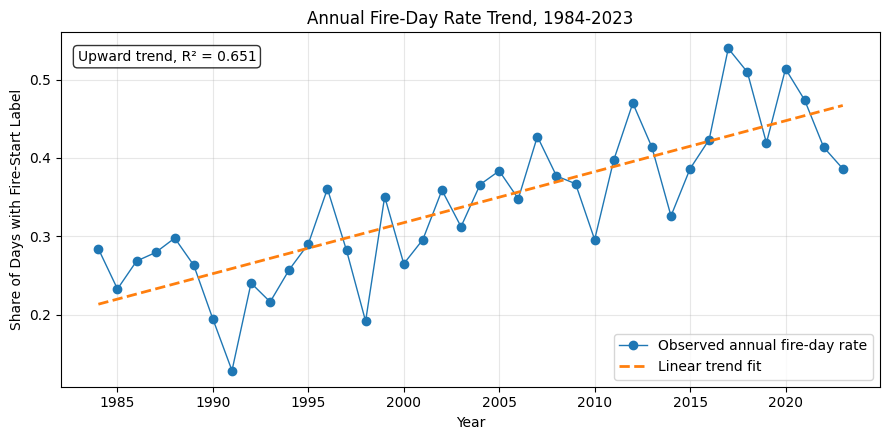

,MONTH,fire_rate
0,1,0.0718
1,2,0.0655
2,3,0.0919
3,4,0.1733
4,5,0.3976
5,6,0.6533
6,7,0.7556
7,8,0.6984
8,9,0.5483
9,10,0.3419


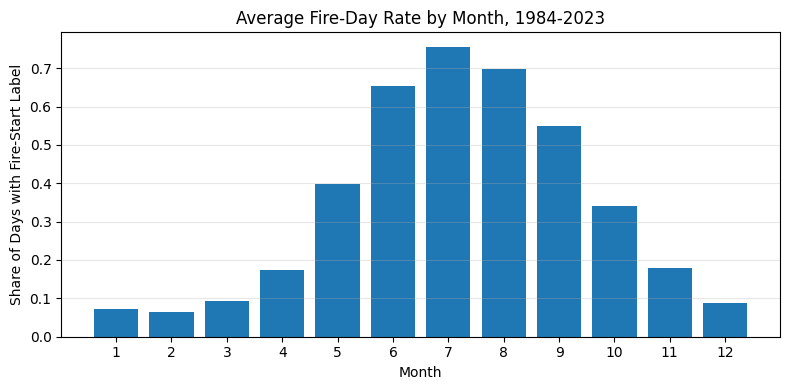

feature,AVG_WIND_SPEED,MAX_TEMP,MIN_TEMP,PRECIPITATION
lag_days,,,,
1,0.5059,0.7953,0.9224,0.2600
2,0.3035,0.5969,0.8741,0.1057
3,0.2510,0.4805,0.8417,0.1059
4,0.2311,0.4267,0.8206,0.0729
5,0.2158,0.4008,0.8055,0.0745
6,0.2095,0.3848,0.7936,0.0781
7,0.2114,0.3751,0.7837,0.0709
8,0.1900,0.3707,0.7743,0.0552
9,0.1968,0.3677,0.7673,0.0512


,total_streaks,mean_streak_days,median_streak_days,max_streak_days,single_day_streak_pct,three_plus_day_streak_pct,seven_plus_day_streak_pct
0,1907,2.6067,1.0,80,0.5422,0.2569,0.0745


In [ ]:
if RUN_TEMPORAL_EDA:
    annual_fire_rate = (
        daily_data.assign(year=daily_data[DATE_COL].dt.year)
        .groupby("year")[TARGET_COL]
        .agg(["mean", "sum", "count"])
        .reset_index()
        .rename(columns={"mean": "fire_rate", "sum": "fire_days", "count": "num_days"})
    )

    slope, intercept = np.polyfit(annual_fire_rate["year"], annual_fire_rate["fire_rate"], 1)
    fitted_fire_rate = slope * annual_fire_rate["year"] + intercept
    ss_resid = np.sum((annual_fire_rate["fire_rate"] - fitted_fire_rate) ** 2)
    ss_total = np.sum((annual_fire_rate["fire_rate"] - annual_fire_rate["fire_rate"].mean()) ** 2)
    r_squared = 1 - ss_resid / ss_total

    print(f"Annual fire-day-rate slope: {slope:.6f} per year")
    print(f"Annual fire-day-rate R^2: {r_squared:.4f}")
    print(f"Implied change across observed years: {slope * (annual_fire_rate['year'].max() - annual_fire_rate['year'].min()):.4f}")

    plt.figure(figsize=(9, 4.5))
    plt.plot(annual_fire_rate["year"], annual_fire_rate["fire_rate"], marker="o", linewidth=1, label="Observed annual fire-day rate")
    plt.plot(annual_fire_rate["year"], fitted_fire_rate, linestyle="--", linewidth=2, label="Linear trend fit")
    plt.xlabel("Year")
    plt.ylabel("Share of Days with Fire-Start Label")
    plt.title("Annual Fire-Day Rate Trend, 1984-2023")
    plt.annotate(
        f"Upward trend, R² = {r_squared:.3f}" if slope > 0 else f"Downward trend, R² = {r_squared:.3f}",
        xy=(0.02, 0.92),
        xycoords="axes fraction",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    monthly_fire_rate = daily_data.groupby("MONTH")[TARGET_COL].mean().reset_index(name="fire_rate")
    display(monthly_fire_rate.round(4))

    plt.figure(figsize=(8, 4))
    plt.bar(monthly_fire_rate["MONTH"], monthly_fire_rate["fire_rate"])
    plt.xlabel("Month")
    plt.ylabel("Share of Days with Fire-Start Label")
    plt.title("Average Fire-Day Rate by Month, 1984-2023")
    plt.xticks(range(1, 13))
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    autocorrelation_rows = []
    for feature_name in ["MAX_TEMP", "MIN_TEMP", "AVG_WIND_SPEED", "PRECIPITATION"]:
        for lag_days in range(1, 15):
            autocorrelation_rows.append({
                "feature": feature_name,
                "lag_days": lag_days,
                "autocorrelation": daily_data[feature_name].autocorr(lag=lag_days),
            })
    autocorrelation_df = pd.DataFrame(autocorrelation_rows)
    display(autocorrelation_df.pivot(index="lag_days", columns="feature", values="autocorrelation").round(4))

    fire_values = daily_data[TARGET_COL].to_numpy(dtype=int)
    streak_lengths = []
    current_streak = 0
    for fire_value in fire_values:
        if fire_value == 1:
            current_streak += 1
        elif current_streak > 0:
            streak_lengths.append(current_streak)
            current_streak = 0
    if current_streak > 0:
        streak_lengths.append(current_streak)

    streak_lengths = np.asarray(streak_lengths, dtype=int)
    streak_summary = pd.DataFrame([{
        "total_streaks": len(streak_lengths),
        "mean_streak_days": np.mean(streak_lengths) if len(streak_lengths) else np.nan,
        "median_streak_days": np.median(streak_lengths) if len(streak_lengths) else np.nan,
        "max_streak_days": np.max(streak_lengths) if len(streak_lengths) else np.nan,
        "single_day_streak_pct": np.mean(streak_lengths == 1) if len(streak_lengths) else np.nan,
        "three_plus_day_streak_pct": np.mean(streak_lengths >= 3) if len(streak_lengths) else np.nan,
        "seven_plus_day_streak_pct": np.mean(streak_lengths >= 7) if len(streak_lengths) else np.nan,
    }])
    display(streak_summary.round(4))


## 7. Original windowed primary models

This is the original temporal-windowed “1-day” setup: six previous rows are flattened and used to predict whether a fire occurs on the next day.

In [ ]:
primary_model_results = []
primary_model_objects = {}

if RUN_PRIMARY_MODELS:
    primary_windowed_data, primary_windowed_feature_names = build_windowed_horizon_dataset(
        daily_data=daily_data,
        feature_names=BASE_FEATURES,
        horizon_days=1,
        window_size=WINDOW_SIZE,
    )
    primary_windowed_split = split_windowed_by_year(primary_windowed_data)

    print("Primary windowed split sizes:")
    print(f"Train: {len(primary_windowed_split['X_train']):,}")
    print(f"Validation: {len(primary_windowed_split['X_val']):,}")
    print(f"Test: {len(primary_windowed_split['X_test']):,}")
    print(f"Windowed feature count: {len(primary_windowed_split['feature_names'])}")

    model_factories = {
        "Dummy baseline": lambda split: make_dummy_classifier(),
        "Logistic Regression": lambda split: make_logistic_regression_pipeline(),
        "Random Forest": lambda split: make_random_forest(),
        "XGBoost": lambda split: make_xgboost_classifier(split["y_train"]),
    }

    for model_name, model_factory in model_factories.items():
        print(f"Training {model_name}...")
        fitted_result = fit_and_evaluate_model(model_factory(primary_windowed_split), primary_windowed_split, model_name)
        primary_model_objects[model_name] = fitted_result
        primary_model_results.append(model_result_row(fitted_result, "baseline_features", 1, "primary_windowed_models"))

    print("Running tuned XGBoost search...")
    tuned_xgb_search_df, tuned_xgb_result = run_parameter_search(
        model_name="XGBoost",
        windowed_split=primary_windowed_split,
        param_grid=XGB_SEARCH_GRID,
        feature_set="baseline_features",
        horizon_days=1,
        section="primary_windowed_tuned_xgboost",
    )
    tuned_xgb_result["model_name"] = "Tuned XGBoost"
    primary_model_objects["Tuned XGBoost"] = tuned_xgb_result
    primary_model_results.append(model_result_row(tuned_xgb_result, "baseline_features", 1, "primary_windowed_models"))

    primary_results_df = pd.DataFrame(primary_model_results)
    display(primary_results_df.round(4))
    save_table(primary_results_df, "primary_windowed_model_results.csv")
    save_table(tuned_xgb_search_df, "primary_tuned_xgboost_search.csv")

Primary windowed split sizes:
Train: 12,410
Validation: 1,096
Test: 1,095
Windowed feature count: 66
Training Dummy baseline...
Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Running tuned XGBoost search...


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
0,primary_windowed_models,Dummy baseline,baseline_features,1,0.05,0.5000,0.4808,0.4808,1.0000,0.6494,0.5000,0.4247,0.4247,1.0000,0.5962
1,primary_windowed_models,Logistic Regression,baseline_features,1,0.45,0.8394,0.8050,0.7373,0.7989,0.7668,0.8036,0.7154,0.6787,0.7677,0.7205
2,primary_windowed_models,Random Forest,baseline_features,1,0.20,0.8385,0.8060,0.7088,0.8406,0.7691,0.8288,0.7646,0.6252,0.8538,0.7218
3,primary_windowed_models,XGBoost,baseline_features,1,0.35,0.8429,0.8210,0.7369,0.8027,0.7684,0.8291,0.7646,0.6562,0.8129,0.7262
4,primary_windowed_models,Tuned XGBoost,baseline_features,1,0.35,0.8441,0.8212,0.7420,0.7970,0.7685,0.8296,0.7688,0.6584,0.7957,0.7205


Saved: /content/wildfire_temporal_windowed_outputs/primary_windowed_model_results.csv
Saved: /content/wildfire_temporal_windowed_outputs/primary_tuned_xgboost_search.csv


In [ ]:
def extract_tree_feature_importance(result: Dict, feature_names: List[str], top_n: int = 25) -> pd.DataFrame:
    fitted_model = result["model"]
    if not hasattr(fitted_model, "feature_importances_"):
        return pd.DataFrame()
    return (
        pd.DataFrame({"feature": feature_names, "importance": fitted_model.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


def aggregate_windowed_importance(importance_data: pd.DataFrame) -> pd.DataFrame:
    if importance_data.empty:
        return importance_data
    aggregate_data = importance_data.copy()
    aggregate_data["base_feature"] = aggregate_data["feature"].str.replace(r"_day\d+$", "", regex=True)
    return (
        aggregate_data.groupby("base_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


if RUN_PRIMARY_MODELS:
    for model_name in ["Random Forest", "XGBoost", "Tuned XGBoost"]:
        if model_name in primary_model_objects:
            importance_df = extract_tree_feature_importance(primary_model_objects[model_name], primary_windowed_split["feature_names"], top_n=40)
            print(f"Top windowed features: {model_name}")
            display(importance_df.head(15).round(4))
            print(f"Aggregated base-feature importance: {model_name}")
            display(aggregate_windowed_importance(importance_df).head(15).round(4))

Top windowed features: Random Forest


,feature,importance
0,MIN_TEMP_day5,0.0523
1,MIN_TEMP_day6,0.0483
2,MIN_TEMP_day2,0.0374
3,MIN_TEMP_day4,0.0333
4,MIN_TEMP_day3,0.0315
5,DAY_OF_YEAR_day6,0.0300
6,MIN_TEMP_day1,0.0285
7,DAY_OF_YEAR_day5,0.0284
8,DAY_OF_YEAR_day4,0.0276
9,DAY_OF_YEAR_day2,0.0256


Aggregated base-feature importance: Random Forest


,base_feature,importance
0,MIN_TEMP,0.2314
1,DAY_OF_YEAR,0.1600
2,WIND_TEMP_RATIO,0.1176
3,LAGGED_AVG_WIND_SPEED,0.1093
4,MAX_TEMP,0.0964
5,AVG_WIND_SPEED,0.0882
6,TEMP_RANGE,0.0557


Top windowed features: XGBoost


...

,base_feature,importance
0,MIN_TEMP,0.2641
1,SEASON_ENC,0.2281
2,DAY_OF_YEAR,0.0967
3,LAGGED_PRECIPITATION,0.0721
4,LAGGED_AVG_WIND_SPEED,0.0474
5,MONTH,0.0395
6,PRECIPITATION,0.0210
7,WIND_TEMP_RATIO,0.0172
8,MAX_TEMP,0.0143
9,AVG_WIND_SPEED,0.0083


Top windowed features: Tuned XGBoost


,feature,importance
0,MIN_TEMP_day6,0.1593
1,SEASON_ENC_day1,0.0995
2,SEASON_ENC_day2,0.0621
3,LAGGED_PRECIPITATION_day6,0.0299
4,SEASON_ENC_day4,0.0298
5,MIN_TEMP_day5,0.0286
6,MIN_TEMP_day1,0.0244
7,MONTH_day6,0.0240
8,SEASON_ENC_day5,0.0239
9,DAY_OF_YEAR_day1,0.0185


Aggregated base-feature importance: Tuned XGBoost


,base_feature,importance
0,MIN_TEMP,0.2509
1,SEASON_ENC,0.2456
2,DAY_OF_YEAR,0.0927
3,LAGGED_PRECIPITATION,0.0727
4,MONTH,0.0513
5,LAGGED_AVG_WIND_SPEED,0.0233
6,PRECIPITATION,0.0231
7,MAX_TEMP,0.0197
8,WIND_TEMP_RATIO,0.0161
9,TEMP_RANGE,0.0154


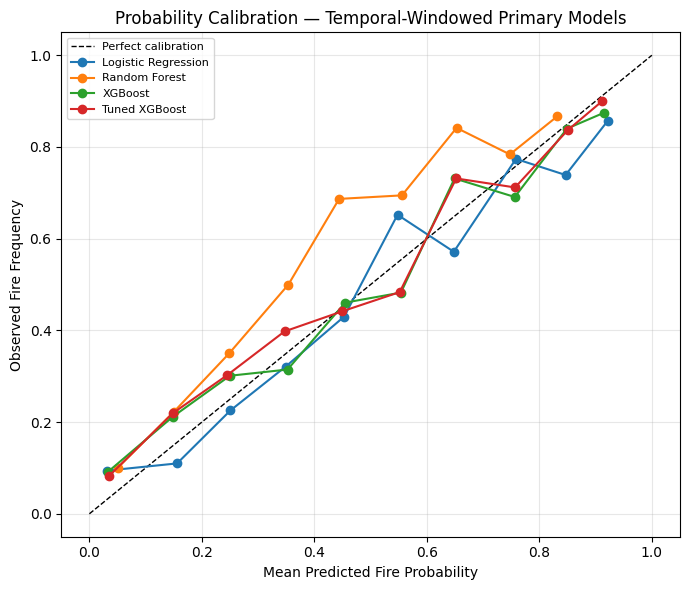

,model,brier_score,validation_selected_threshold,mean_predicted_probability,actual_positive_rate
3,Tuned XGBoost,0.1669,0.35,0.4048,0.4247
2,XGBoost,0.1671,0.35,0.4111,0.4247
0,Logistic Regression,0.1784,0.45,0.4381,0.4247
1,Random Forest,0.1788,0.20,0.3225,0.4247


Saved: /content/wildfire_temporal_windowed_outputs/temporal_windowed_calibration_summary.csv


In [ ]:
# =========================
# Probability calibration for temporal-windowed primary models
# =========================
if RUN_TEMPORAL_WINDOWED_CALIBRATION and RUN_PRIMARY_MODELS:
    from sklearn.calibration import calibration_curve
    from sklearn.metrics import brier_score_loss

    calibration_model_names = [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost",
    ]

    calibration_rows: List[Dict[str, Any]] = []
    fig, axis = plt.subplots(figsize=(7, 6))
    axis.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")

    for model_name in calibration_model_names:
        if model_name not in primary_model_objects:
            continue
        model_result = primary_model_objects[model_name]
        test_probabilities = model_result["test_probabilities"]
        y_test_values = model_result["split"]["y_test"]
        prob_true, prob_pred = calibration_curve(y_test_values, test_probabilities, n_bins=10, strategy="uniform")
        axis.plot(prob_pred, prob_true, marker="o", linewidth=1.5, label=model_name)

        calibration_rows.append({
            "model": model_name,
            "brier_score": round(float(brier_score_loss(y_test_values, test_probabilities)), 4),
            "validation_selected_threshold": model_result["best_threshold"],
            "mean_predicted_probability": round(float(np.mean(test_probabilities)), 4),
            "actual_positive_rate": round(float(np.mean(y_test_values)), 4),
        })

    axis.set_title("Probability Calibration — Temporal-Windowed Primary Models")
    axis.set_xlabel("Mean Predicted Fire Probability")
    axis.set_ylabel("Observed Fire Frequency")
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    temporal_windowed_calibration_summary = pd.DataFrame(calibration_rows).sort_values("brier_score")
    display(temporal_windowed_calibration_summary)
    save_table(temporal_windowed_calibration_summary, "temporal_windowed_calibration_summary.csv")
else:
    temporal_windowed_calibration_summary = pd.DataFrame()


## 8. Sensitivity analysis, feature ablation, and error analysis

In [ ]:
recent_history_results = []

if RUN_RECENT_HISTORY_SENSITIVITY and RUN_PRIMARY_MODELS:
    recent_train_years = (2008, 2017)
    recent_windowed_split = split_windowed_by_year(primary_windowed_data, train_years=recent_train_years)

    for model_name, model_factory in {
        "Logistic Regression": lambda split: make_logistic_regression_pipeline(),
        "Random Forest": lambda split: make_random_forest(),
        "XGBoost": lambda split: make_xgboost_classifier(split["y_train"]),
    }.items():
        print(f"Training recent-history {model_name}...")
        fitted_result = fit_and_evaluate_model(model_factory(recent_windowed_split), recent_windowed_split, model_name)
        recent_history_results.append(
            model_result_row(
                fitted_result,
                "baseline_features",
                1,
                "recent_history_sensitivity",
                extra_fields={"train_years": f"{recent_train_years[0]}-{recent_train_years[1]}"},
            )
        )

    recent_history_results_df = pd.DataFrame(recent_history_results)
    display(recent_history_results_df.round(4))
    save_table(recent_history_results_df, "recent_history_sensitivity_results.csv")


ablation_results = []
FEATURE_ABLATION_SPECS = {
    "full_baseline": BASE_FEATURES,
    "weather_only": WEATHER_FEATURES,
    "calendar_only": CALENDAR_FEATURES,
    "no_calendar": WEATHER_FEATURES,
}

if RUN_FEATURE_ABLATION:
    for ablation_name, feature_list in FEATURE_ABLATION_SPECS.items():
        ablation_windowed_data, _ = build_windowed_horizon_dataset(daily_data, feature_list, horizon_days=1, window_size=WINDOW_SIZE)
        ablation_split = split_windowed_by_year(ablation_windowed_data)

        for model_name, model_factory in {
            "Random Forest": lambda split: make_random_forest(),
            "XGBoost": lambda split: make_xgboost_classifier(split["y_train"]),
        }.items():
            print(f"Training {model_name} on {ablation_name}...")
            fitted_result = fit_and_evaluate_model(model_factory(ablation_split), ablation_split, model_name)
            ablation_results.append(model_result_row(fitted_result, ablation_name, 1, "feature_ablation"))

    ablation_results_df = pd.DataFrame(ablation_results)
    display_sorted(ablation_results_df, ["model", "feature_set"])
    save_table(ablation_results_df, "feature_ablation_results.csv")

Training recent-history Logistic Regression...
Training recent-history Random Forest...
Training recent-history XGBoost...


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned,train_years
0,recent_history_sensitivity,Logistic Regression,baseline_features,1,0.50,0.8334,0.8089,0.7315,0.7704,0.7505,0.8179,0.7343,0.6870,0.7505,0.7174,2008-2017
1,recent_history_sensitivity,Random Forest,baseline_features,1,0.30,0.8385,0.8167,0.7344,0.8027,0.7670,0.8332,0.7486,0.6767,0.8194,0.7412,2008-2017
2,recent_history_sensitivity,XGBoost,baseline_features,1,0.25,0.8493,0.8383,0.7067,0.8368,0.7663,0.8252,0.7408,0.6374,0.8430,0.7259,2008-2017


Saved: /content/wildfire_temporal_windowed_outputs/recent_history_sensitivity_results.csv
Training Random Forest on full_baseline...
Training XGBoost on full_baseline...
Training Random Forest on weather_only...
Training XGBoost on weather_only...
Training Random Forest on calendar_only...
Training XGBoost on calendar_only...
Training Random Forest on no_calendar...
Training XGBoost on no_calendar...


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
4,feature_ablation,Random Forest,calendar_only,1,0.30,0.8184,0.8082,0.6906,0.8387,0.7575,0.8194,0.7549,0.6268,0.8559,0.7236
0,feature_ablation,Random Forest,full_baseline,1,0.20,0.8385,0.8060,0.7088,0.8406,0.7691,0.8288,0.7646,0.6252,0.8538,0.7218
6,feature_ablation,Random Forest,no_calendar,1,0.25,0.8315,0.7896,0.7236,0.8197,0.7687,0.8116,0.7247,0.6591,0.8065,0.7253
2,feature_ablation,Random Forest,weather_only,1,0.25,0.8315,0.7896,0.7236,0.8197,0.7687,0.8116,0.7247,0.6591,0.8065,0.7253
5,feature_ablation,XGBoost,calendar_only,1,0.35,0.8227,0.8158,0.7193,0.8121,0.7629,0.8214,0.7594,0.6498,0.8301,0.7290
1,feature_ablation,XGBoost,full_baseline,1,0.35,0.8429,0.8210,0.7369,0.8027,0.7684,0.8291,0.7646,0.6562,0.8129,0.7262
7,feature_ablation,XGBoost,no_calendar,1,0.35,0.8313,0.7920,0.7207,0.8178,0.7662,0.8096,0.7295,0.6512,0.7871,0.7128
3,feature_ablation,XGBoost,weather_only,1,0.35,0.8313,0.7920,0.7207,0.8178,0.7662,0.8096,0.7295,0.6512,0.7871,0.7128


Saved: /content/wildfire_temporal_windowed_outputs/feature_ablation_results.csv


In [ ]:
def build_error_analysis_table(result: Dict, model_label: str) -> pd.DataFrame:
    split_data = result["split"]
    y_true = split_data["y_test"].to_numpy(dtype=int)
    y_prob = result["test_probabilities"]
    y_pred = (y_prob >= result["best_threshold"]).astype(int)

    error_data = pd.DataFrame({
        "target_date": split_data["dates_test"].reset_index(drop=True),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    })
    error_data["month"] = error_data["target_date"].dt.month
    error_data["season"] = error_data["month"].map({12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall"})
    error_data["error_type"] = np.select(
        [
            (error_data["y_true"] == 1) & (error_data["y_pred"] == 1),
            (error_data["y_true"] == 0) & (error_data["y_pred"] == 0),
            (error_data["y_true"] == 0) & (error_data["y_pred"] == 1),
            (error_data["y_true"] == 1) & (error_data["y_pred"] == 0),
        ],
        ["true_positive", "true_negative", "false_positive", "false_negative"],
        default="unknown",
    )
    error_data["model"] = model_label
    return error_data


if RUN_PRIMARY_MODELS:
    error_analysis_tables = []
    for model_name in ["Random Forest", "XGBoost", "Tuned XGBoost"]:
        if model_name in primary_model_objects:
            error_analysis_tables.append(build_error_analysis_table(primary_model_objects[model_name], model_name))

    if error_analysis_tables:
        error_analysis_df = pd.concat(error_analysis_tables, ignore_index=True)
        false_negative_rates = []
        for (model_name, season_name), season_data in error_analysis_df.groupby(["model", "season"]):
            true_fire_days = season_data.loc[season_data["y_true"] == 1]
            if len(true_fire_days) == 0:
                continue
            false_negative_count = int((true_fire_days["error_type"] == "false_negative").sum())
            false_negative_rates.append({
                "model": model_name,
                "season": season_name,
                "true_fire_days": len(true_fire_days),
                "false_negative_count": false_negative_count,
                "false_negative_rate": false_negative_count / len(true_fire_days),
            })
        false_negative_rates_df = pd.DataFrame(false_negative_rates)
        display_sorted(false_negative_rates_df, ["model", "season"])
        save_table(false_negative_rates_df, "seasonal_false_negative_rates.csv")

,model,season,true_fire_days,false_negative_count,false_negative_rate
0,Random Forest,Fall,99,11,0.1111
1,Random Forest,Spring,110,36,0.3273
2,Random Forest,Summer,227,0,0.0000
3,Random Forest,Winter,29,21,0.7241
4,Tuned XGBoost,Fall,99,17,0.1717
5,Tuned XGBoost,Spring,110,51,0.4636
6,Tuned XGBoost,Summer,227,1,0.0044
7,Tuned XGBoost,Winter,29,26,0.8966
8,XGBoost,Fall,99,13,0.1313
9,XGBoost,Spring,110,49,0.4455


Saved: /content/wildfire_temporal_windowed_outputs/seasonal_false_negative_rates.csv


## 9. Broad multi-horizon sweep and focused shortlist

Broad sweep: Random Forest, baseline_features, horizon=1
Broad sweep: XGBoost, baseline_features, horizon=1
Broad sweep: Random Forest, engineered_features, horizon=1
Broad sweep: XGBoost, engineered_features, horizon=1
Broad sweep: Random Forest, baseline_features, horizon=3
Broad sweep: XGBoost, baseline_features, horizon=3
Broad sweep: Random Forest, engineered_features, horizon=3
Broad sweep: XGBoost, engineered_features, horizon=3
Broad sweep: Random Forest, baseline_features, horizon=7
Broad sweep: XGBoost, baseline_features, horizon=7
Broad sweep: Random Forest, engineered_features, horizon=7
Broad sweep: XGBoost, engineered_features, horizon=7
Broad sweep: Random Forest, baseline_features, horizon=10
Broad sweep: XGBoost, baseline_features, horizon=10
Broad sweep: Random Forest, engineered_features, horizon=10
Broad sweep: XGBoost, engineered_features, horizon=10
Broad sweep: Random Forest, baseline_features, horizon=14
Broad sweep: XGBoost, baseline_features, horizon=14
Broad 

,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
0,broad_horizon_sweep,Random Forest,baseline_features,1,0.20,0.8385,0.8060,0.7088,0.8406,0.7691,0.8288,0.7646,0.6252,0.8538,0.7218
1,broad_horizon_sweep,XGBoost,baseline_features,1,0.35,0.8429,0.8210,0.7369,0.8027,0.7684,0.8291,0.7646,0.6562,0.8129,0.7262
2,broad_horizon_sweep,Random Forest,engineered_features,1,0.25,0.8429,0.8012,0.7317,0.8330,0.7791,0.8276,0.7464,0.6613,0.7892,0.7196
3,broad_horizon_sweep,XGBoost,engineered_features,1,0.35,0.8490,0.8200,0.7385,0.8197,0.7770,0.8271,0.7535,0.6625,0.7978,0.7239
4,broad_horizon_sweep,Random Forest,baseline_features,3,0.25,0.8796,0.9447,0.8400,0.8920,0.8652,0.8785,0.9365,0.7937,0.9255,0.8545
5,broad_horizon_sweep,XGBoost,baseline_features,3,0.20,0.8880,0.9440,0.8582,0.8933,0.8754,0.8771,0.9347,0.7915,0.9128,0.8478
6,broad_horizon_sweep,Random Forest,engineered_features,3,0.20,0.8913,0.9513,0.8296,0.9170,0.8711,0.8738,0.9343,0.7787,0.9451,0.8539
7,broad_horizon_sweep,XGBoost,engineered_features,3,0.10,0.8972,0.9457,0.8378,0.9460,0.8886,0.8681,0.9317,0.7625,0.9437,0.8435
8,broad_horizon_sweep,Random Forest,baseline_features,7,0.30,0.8894,0.9721,0.8824,0.9177,0.8997,0.8642,0.9595,0.8506,0.9269,0.8871
9,broad_horizon_sweep,XGBoost,baseline_features,7,0.05,0.8972,0.9741,0.8407,0.9829,0.9062,0.8607,0.9569,0.8168,0.9729,0.8881


Saved: /content/wildfire_temporal_windowed_outputs/broad_horizon_results.csv


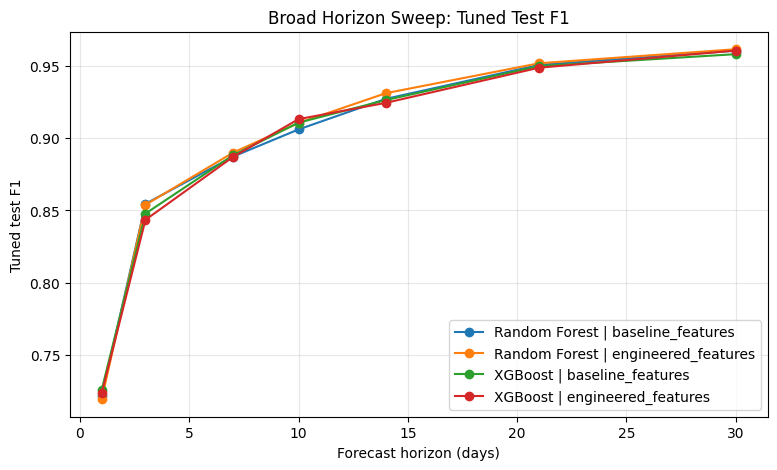

In [ ]:
broad_horizon_results = []
broad_horizon_model_objects = {}

if RUN_BROAD_HORIZON_SWEEP:
    feature_source_map = build_feature_source_map(daily_data)
    for horizon_days in BROAD_HORIZONS:
        for feature_set, source_info in feature_source_map.items():
            for model_name in ["Random Forest", "XGBoost"]:
                print(f"Broad sweep: {model_name}, {feature_set}, horizon={horizon_days}")
                horizon_output = run_horizon_model(source_info["daily_data"], source_info["feature_list"], feature_set, horizon_days, model_name, "broad_horizon_sweep")
                broad_horizon_results.append(horizon_output["row"])
                broad_horizon_model_objects[(horizon_days, feature_set, model_name)] = horizon_output

    broad_horizon_results_df = pd.DataFrame(broad_horizon_results)
    display_sorted(broad_horizon_results_df, ["horizon_days", "feature_set", "model"])
    save_table(broad_horizon_results_df, "broad_horizon_results.csv")

    plt.figure(figsize=(9, 5))
    for (model_name, feature_set), group_data in broad_horizon_results_df.groupby(["model", "feature_set"]):
        group_data = group_data.sort_values("horizon_days")
        plt.plot(group_data["horizon_days"], group_data["test_f1_tuned"], marker="o", label=f"{model_name} | {feature_set}")
    plt.xlabel("Forecast horizon (days)")
    plt.ylabel("Tuned test F1")
    plt.title("Broad Horizon Sweep: Tuned Test F1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
shortlist_results = []
shortlist_model_objects = {}

if RUN_SHORTLIST_SWEEP:
    # If the broad sweep already ran, reuse those results instead of retraining the same
    # 1/3/7/10-day RF/XGBoost models. This keeps the merged notebook much faster.
    if "broad_horizon_results_df" in globals() and not broad_horizon_results_df.empty:
        shortlist_results_df = (
            broad_horizon_results_df.loc[broad_horizon_results_df["horizon_days"].isin(SHORTLIST_HORIZONS)]
            .copy()
            .reset_index(drop=True)
        )
        if "broad_horizon_model_objects" in globals():
            shortlist_model_objects = {
                key: value for key, value in broad_horizon_model_objects.items()
                if key[0] in SHORTLIST_HORIZONS
            }
        print("Shortlist results reused from the broad horizon sweep.")
    else:
        feature_source_map = build_feature_source_map(daily_data)
        for horizon_days in SHORTLIST_HORIZONS:
            for feature_set, source_info in feature_source_map.items():
                for model_name in ["Random Forest", "XGBoost"]:
                    print(f"Shortlist sweep: {model_name}, {feature_set}, horizon={horizon_days}")
                    horizon_output = run_horizon_model(source_info["daily_data"], source_info["feature_list"], feature_set, horizon_days, model_name, "horizon_shortlist")
                    shortlist_results.append(horizon_output["row"])
                    shortlist_model_objects[(horizon_days, feature_set, model_name)] = horizon_output
        shortlist_results_df = pd.DataFrame(shortlist_results)

    display_sorted(shortlist_results_df, ["horizon_days", "feature_set", "model"])
    save_table(shortlist_results_df, "horizon_shortlist_results.csv")

    shortlist_keeper_df = (
        shortlist_results_df.sort_values(["horizon_days", "test_f1_tuned"], ascending=[True, False])
        .groupby("horizon_days")
        .head(1)
        .reset_index(drop=True)
    )
    print("Best old-branch setup by shortlisted horizon:")
    display(shortlist_keeper_df.round(4))
    save_table(shortlist_keeper_df, "horizon_shortlist_keepers.csv")

Shortlist results reused from the broad horizon sweep.


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
0,broad_horizon_sweep,Random Forest,baseline_features,1,0.20,0.8385,0.8060,0.7088,0.8406,0.7691,0.8288,0.7646,0.6252,0.8538,0.7218
1,broad_horizon_sweep,XGBoost,baseline_features,1,0.35,0.8429,0.8210,0.7369,0.8027,0.7684,0.8291,0.7646,0.6562,0.8129,0.7262
2,broad_horizon_sweep,Random Forest,engineered_features,1,0.25,0.8429,0.8012,0.7317,0.8330,0.7791,0.8276,0.7464,0.6613,0.7892,0.7196
3,broad_horizon_sweep,XGBoost,engineered_features,1,0.35,0.8490,0.8200,0.7385,0.8197,0.7770,0.8271,0.7535,0.6625,0.7978,0.7239
4,broad_horizon_sweep,Random Forest,baseline_features,3,0.25,0.8796,0.9447,0.8400,0.8920,0.8652,0.8785,0.9365,0.7937,0.9255,0.8545
5,broad_horizon_sweep,XGBoost,baseline_features,3,0.20,0.8880,0.9440,0.8582,0.8933,0.8754,0.8771,0.9347,0.7915,0.9128,0.8478
6,broad_horizon_sweep,Random Forest,engineered_features,3,0.20,0.8913,0.9513,0.8296,0.9170,0.8711,0.8738,0.9343,0.7787,0.9451,0.8539
7,broad_horizon_sweep,XGBoost,engineered_features,3,0.10,0.8972,0.9457,0.8378,0.9460,0.8886,0.8681,0.9317,0.7625,0.9437,0.8435
8,broad_horizon_sweep,Random Forest,baseline_features,7,0.30,0.8894,0.9721,0.8824,0.9177,0.8997,0.8642,0.9595,0.8506,0.9269,0.8871
9,broad_horizon_sweep,XGBoost,baseline_features,7,0.05,0.8972,0.9741,0.8407,0.9829,0.9062,0.8607,0.9569,0.8168,0.9729,0.8881


Saved: /content/wildfire_temporal_windowed_outputs/horizon_shortlist_results.csv
Best old-branch setup by shortlisted horizon:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
0,broad_horizon_sweep,XGBoost,baseline_features,1,0.35,0.8429,0.8210,0.7369,0.8027,0.7684,0.8291,0.7646,0.6562,0.8129,0.7262
1,broad_horizon_sweep,Random Forest,baseline_features,3,0.25,0.8796,0.9447,0.8400,0.8920,0.8652,0.8785,0.9365,0.7937,0.9255,0.8545
2,broad_horizon_sweep,Random Forest,engineered_features,7,0.25,0.8966,0.9738,0.8769,0.9440,0.9092,0.8626,0.9582,0.8311,0.9575,0.8899
3,broad_horizon_sweep,XGBoost,engineered_features,10,0.10,0.9029,0.9814,0.9214,0.9384,0.9298,0.8472,0.9626,0.8679,0.9631,0.9130


Saved: /content/wildfire_temporal_windowed_outputs/horizon_shortlist_keepers.csv


## 10. Temporal robustness of the shortlisted horizons

In [ ]:
TEMPORAL_ROBUSTNESS_WINDOWS = [
    {"window_order": 1, "window_label": "Test 2000-2002", "train_years": (1984, 1996), "val_years": (1997, 1999), "test_years": (2000, 2002)},
    {"window_order": 2, "window_label": "Test 2006-2008", "train_years": (1984, 2002), "val_years": (2003, 2005), "test_years": (2006, 2008)},
    {"window_order": 3, "window_label": "Test 2012-2014", "train_years": (1984, 2008), "val_years": (2009, 2011), "test_years": (2012, 2014)},
    {"window_order": 4, "window_label": "Test 2018-2020", "train_years": (1984, 2014), "val_years": (2015, 2017), "test_years": (2018, 2020)},
    {"window_order": 5, "window_label": "Test 2021-2023", "train_years": (1984, 2017), "val_years": (2018, 2020), "test_years": (2021, 2023)},
]

TEMPORAL_ROBUSTNESS_SPECS = [
    {"spec_label": "1d | XGBoost | baseline", "horizon_days": 1, "model_name": "XGBoost", "feature_set": "baseline_features"},
    {"spec_label": "3d | Random Forest | engineered", "horizon_days": 3, "model_name": "Random Forest", "feature_set": "engineered_features"},
    {"spec_label": "7d | Random Forest | engineered", "horizon_days": 7, "model_name": "Random Forest", "feature_set": "engineered_features"},
    {"spec_label": "7d | XGBoost | engineered", "horizon_days": 7, "model_name": "XGBoost", "feature_set": "engineered_features"},
    {"spec_label": "10d | Random Forest | engineered", "horizon_days": 10, "model_name": "Random Forest", "feature_set": "engineered_features"},
]


def year_block_label(years: Tuple[int, int]) -> str:
    return f"{years[0]}-{years[1]}"


temporal_robustness_results = []

if RUN_TEMPORAL_ROBUSTNESS:
    for window_config in TEMPORAL_ROBUSTNESS_WINDOWS:
        print(f"Temporal robustness window: {window_config['window_label']}")
        feature_source_map = build_feature_source_map(daily_data, train_end_year=window_config["train_years"][1])
        split_cache = {}

        for spec in TEMPORAL_ROBUSTNESS_SPECS:
            cache_key = (spec["feature_set"], spec["horizon_days"])
            if cache_key not in split_cache:
                source_info = feature_source_map[spec["feature_set"]]
                windowed_data, _ = build_windowed_horizon_dataset(source_info["daily_data"], source_info["feature_list"], spec["horizon_days"], WINDOW_SIZE)
                split_cache[cache_key] = split_windowed_by_year(windowed_data, window_config["train_years"], window_config["val_years"], window_config["test_years"])

            windowed_split = split_cache[cache_key]
            model_name = spec["model_name"]
            model = make_random_forest() if model_name == "Random Forest" else make_xgboost_classifier(windowed_split["y_train"])
            fitted_result = fit_and_evaluate_model(model, windowed_split, model_name)
            temporal_robustness_results.append(
                model_result_row(
                    fitted_result,
                    spec["feature_set"],
                    spec["horizon_days"],
                    "temporal_robustness",
                    extra_fields={
                        "window_order": window_config["window_order"],
                        "window_label": window_config["window_label"],
                        "train_years": year_block_label(window_config["train_years"]),
                        "val_years": year_block_label(window_config["val_years"]),
                        "test_years": year_block_label(window_config["test_years"]),
                        "spec_label": spec["spec_label"],
                    },
                )
            )

    temporal_robustness_results_df = pd.DataFrame(temporal_robustness_results)
    display_sorted(temporal_robustness_results_df, ["window_order", "horizon_days", "model"])
    best_by_window_df = (
        temporal_robustness_results_df.sort_values(["window_order", "test_f1_tuned"], ascending=[True, False])
        .groupby("window_order")
        .head(1)
        .reset_index(drop=True)
    )
    print("Best old-branch setup by historical test window:")
    display(best_by_window_df.round(4))
    save_table(temporal_robustness_results_df, "temporal_robustness_results.csv")
    save_table(best_by_window_df, "temporal_robustness_best_by_window.csv")

Temporal robustness window: Test 2000-2002
Temporal robustness window: Test 2006-2008
Temporal robustness window: Test 2012-2014
Temporal robustness window: Test 2018-2020
Temporal robustness window: Test 2021-2023


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,...,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned,window_order,window_label,train_years,val_years,test_years,spec_label
0,temporal_robustness,XGBoost,baseline_features,1,0.15,0.8062,0.5641,0.4721,0.8704,0.6121,...,0.6078,0.5174,0.8423,0.6410,1,Test 2000-2002,1984-1996,1997-1999,2000-2002,1d | XGBoost | baseline
1,temporal_robustness,Random Forest,engineered_features,3,0.35,0.8775,0.8556,0.7976,0.8585,0.8269,...,0.8730,0.7958,0.8086,0.8021,1,Test 2000-2002,1984-1996,1997-1999,2000-2002,3d | Random Forest | engineered
2,temporal_robustness,Random Forest,engineered_features,7,0.40,0.8992,0.9436,0.8577,0.8839,0.8706,...,0.9409,0.8573,0.8585,0.8579,1,Test 2000-2002,1984-1996,1997-1999,2000-2002,7d | Random Forest | engineered
3,temporal_robustness,XGBoost,engineered_features,7,0.20,0.9074,0.9443,0.8503,0.9071,0.8778,...,0.9359,0.8197,0.8766,0.8472,1,Test 2000-2002,1984-1996,1997-1999,2000-2002,7d | XGBoost | engineered
4,temporal_robustness,Random Forest,engineered_features,10,0.45,0.9062,0.9606,0.8919,0.8752,0.8835,...,0.9481,0.8755,0.8540,0.8646,1,Test 2000-2002,1984-1996,1997-1999,2000-2002,10d | Random Forest | engineered
5,temporal_robustness,XGBoost,baseline_features,1,0.30,0.8782,0.7663,0.6602,0.8763,0.7530,...,0.7112,0.6205,0.7767,0.6899,2,Test 2006-2008,1984-2002,2003-2005,2006-2008,1d | XGBoost | baseline
6,temporal_robustness,Random Forest,engineered_features,3,0.45,0.9078,0.9259,0.8956,0.7784,0.8329,...,0.9003,0.8469,0.7545,0.7981,2,Test 2006-2008,1984-2002,2003-2005,2006-2008,3d | Random Forest | engineered
7,temporal_robustness,Random Forest,engineered_features,7,0.30,0.8865,0.9418,0.7812,0.9207,0.8453,...,0.9461,0.8483,0.9033,0.8749,2,Test 2006-2008,1984-2002,2003-2005,2006-2008,7d | Random Forest | engineered
8,temporal_robustness,XGBoost,engineered_features,7,0.30,0.8834,0.9378,0.8345,0.8711,0.8524,...,0.9418,0.8952,0.8360,0.8646,2,Test 2006-2008,1984-2002,2003-2005,2006-2008,7d | XGBoost | engineered
9,temporal_robustness,Random Forest,engineered_features,10,0.40,0.8776,0.9479,0.8460,0.8914,0.8681,...,0.9631,0.9001,0.8757,0.8877,2,Test 2006-2008,1984-2002,2003-2005,2006-2008,10d | Random Forest | engineered


Best old-branch setup by historical test window:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,...,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned,window_order,window_label,train_years,val_years,test_years,spec_label
0,temporal_robustness,Random Forest,engineered_features,10,0.45,0.9062,0.9606,0.8919,0.8752,0.8835,...,0.9481,0.8755,0.8540,0.8646,1,Test 2000-2002,1984-1996,1997-1999,2000-2002,10d | Random Forest | engineered
1,temporal_robustness,Random Forest,engineered_features,10,0.40,0.8776,0.9479,0.8460,0.8914,0.8681,...,0.9631,0.9001,0.8757,0.8877,2,Test 2006-2008,1984-2002,2003-2005,2006-2008,10d | Random Forest | engineered
2,temporal_robustness,Random Forest,engineered_features,10,0.35,0.8782,0.9562,0.8154,0.9614,0.8824,...,0.9743,0.8786,0.9583,0.9167,3,Test 2012-2014,1984-2008,2009-2011,2012-2014,10d | Random Forest | engineered
3,temporal_robustness,Random Forest,engineered_features,10,0.30,0.8882,0.9796,0.8993,0.9485,0.9232,...,0.9791,0.9089,0.9168,0.9128,4,Test 2018-2020,1984-2014,2015-2017,2018-2020,10d | Random Forest | engineered
4,temporal_robustness,Random Forest,engineered_features,10,0.20,0.8880,0.9785,0.8756,0.9892,0.9289,...,0.9657,0.8435,0.9888,0.9104,5,Test 2021-2023,1984-2017,2018-2020,2021-2023,10d | Random Forest | engineered


Saved: /content/wildfire_temporal_windowed_outputs/temporal_robustness_results.csv
Saved: /content/wildfire_temporal_windowed_outputs/temporal_robustness_best_by_window.csv


## 11. Advanced model refinement

This section carries forward the old shortlisted horizon choices into tuned Random Forest, tuned XGBoost, and tabular MLP models.

In [ ]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for layer_width in hidden_dims:
            layers.append(nn.Linear(previous_dim, layer_width))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = layer_width
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, input_tensor):
        return self.network(input_tensor).squeeze(1)


MLP_CONFIGS = [
    {"hidden_dims": [128, 64], "dropout": 0.0, "lr": 1e-3, "weight_decay": 0.0, "batch_size": 256},
    {"hidden_dims": [128, 64], "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 256},
    {"hidden_dims": [256, 128], "dropout": 0.0, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 256},
    {"hidden_dims": [256, 128], "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 256},
    {"hidden_dims": [128, 128, 64], "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 256},
    {"hidden_dims": [128, 128, 64], "dropout": 0.3, "lr": 3e-4, "weight_decay": 1e-4, "batch_size": 256},
    {"hidden_dims": [256, 128, 64], "dropout": 0.2, "lr": 3e-4, "weight_decay": 1e-4, "batch_size": 256},
    {"hidden_dims": [256, 128, 64], "dropout": 0.3, "lr": 3e-4, "weight_decay": 1e-3, "batch_size": 256},
]
if FAST_RUN:
    MLP_CONFIGS = MLP_CONFIGS[:2]


def prepare_mlp_tensors(windowed_split: Dict) -> Dict:
    split_data = median_impute_split(windowed_split)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(split_data["X_train"]).astype(np.float32)
    X_val = scaler.transform(split_data["X_val"]).astype(np.float32)
    X_test = scaler.transform(split_data["X_test"]).astype(np.float32)
    return {
        "scaler": scaler,
        "X_train": torch.tensor(X_train, dtype=torch.float32),
        "y_train": torch.tensor(split_data["y_train"].to_numpy(dtype=np.float32), dtype=torch.float32),
        "X_val": torch.tensor(X_val, dtype=torch.float32),
        "y_val": torch.tensor(split_data["y_val"].to_numpy(dtype=np.float32), dtype=torch.float32),
        "X_test": torch.tensor(X_test, dtype=torch.float32),
        "y_test": torch.tensor(split_data["y_test"].to_numpy(dtype=np.float32), dtype=torch.float32),
    }


def predict_mlp_probabilities(model: nn.Module, input_tensor: torch.Tensor, batch_size: int = 1024) -> np.ndarray:
    model.eval()
    probabilities = []
    with torch.no_grad():
        for start_index in range(0, len(input_tensor), batch_size):
            batch_tensor = input_tensor[start_index : start_index + batch_size].to(TORCH_DEVICE)
            probabilities.append(torch.sigmoid(model(batch_tensor)).detach().cpu().numpy())
    return np.concatenate(probabilities).astype(float)


def train_single_mlp_config(windowed_split: Dict, config: Dict, max_epochs: int = 80, patience: int = 10) -> Dict:
    set_global_seed(RANDOM_STATE)
    if FAST_RUN:
        max_epochs = 8
        patience = 3

    tensor_data = prepare_mlp_tensors(windowed_split)
    model = TabularMLP(tensor_data["X_train"].shape[1], config["hidden_dims"], config["dropout"]).to(TORCH_DEVICE)

    y_train_values = windowed_split["y_train"].to_numpy(dtype=np.float32)
    positive_count = float(y_train_values.sum())
    negative_count = float(len(y_train_values) - positive_count)
    pos_weight = torch.tensor([(negative_count / positive_count) if positive_count > 0 else 1.0], dtype=torch.float32, device=TORCH_DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    train_loader = DataLoader(TensorDataset(tensor_data["X_train"], tensor_data["y_train"]), batch_size=config["batch_size"], shuffle=True, pin_memory=USE_CUDA)

    X_val = tensor_data["X_val"].to(TORCH_DEVICE)
    y_val = tensor_data["y_val"].numpy().astype(int)
    best_state = None
    best_val_pr_auc = -np.inf
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.to(TORCH_DEVICE, non_blocking=USE_CUDA)
            batch_labels = batch_labels.to(TORCH_DEVICE, non_blocking=USE_CUDA)
            optimizer.zero_grad()
            loss = criterion(model(batch_features), batch_labels)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_probabilities = torch.sigmoid(model(X_val)).detach().cpu().numpy()
        val_pr_auc = safe_average_precision(y_val, val_probabilities)

        if val_pr_auc > best_val_pr_auc:
            best_val_pr_auc = val_pr_auc
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break

    model.load_state_dict(best_state)
    val_probabilities = predict_mlp_probabilities(model, tensor_data["X_val"])
    test_probabilities = predict_mlp_probabilities(model, tensor_data["X_test"])
    y_test = tensor_data["y_test"].numpy().astype(int)
    best_threshold, threshold_search = choose_threshold_on_validation(y_val, val_probabilities)
    return {
        "model_name": "MLP",
        "model": model,
        "config": config,
        "best_epoch": best_epoch,
        "best_threshold": best_threshold,
        "threshold_search": threshold_search,
        "val_probabilities": val_probabilities,
        "test_probabilities": test_probabilities,
        "val_metrics": summarize_binary_metrics(y_val, val_probabilities, best_threshold),
        "test_metrics": summarize_binary_metrics(y_test, test_probabilities, best_threshold),
        "split": windowed_split,
    }


def run_mlp_search(windowed_split: Dict):
    mlp_rows = []
    best_result = None
    best_score = -np.inf
    for config in MLP_CONFIGS:
        result = train_single_mlp_config(windowed_split, config)
        row = model_result_row(result, "mlp_search", -1, "mlp_search", extra_fields={
            "hidden_dims": str(config["hidden_dims"]),
            "dropout": config["dropout"],
            "lr": config["lr"],
            "weight_decay": config["weight_decay"],
            "batch_size": config["batch_size"],
            "best_epoch": result["best_epoch"],
        })
        mlp_rows.append(row)
        if row["val_pr_auc"] > best_score:
            best_score = row["val_pr_auc"]
            best_result = result
    return pd.DataFrame(mlp_rows), best_result

In [ ]:
advanced_results = []
advanced_model_objects = {}

if RUN_ADVANCED_MODELS:
    advanced_feature_source_map = build_feature_source_map(daily_data)

    for horizon_days in SHORTLIST_HORIZONS:
        feature_set = KEEPER_FEATURE_SET_BY_HORIZON[horizon_days]
        source_info = advanced_feature_source_map[feature_set]
        print(f"Advanced refinement: horizon={horizon_days}, feature_set={feature_set}")

        windowed_data, _ = build_windowed_horizon_dataset(source_info["daily_data"], source_info["feature_list"], horizon_days, WINDOW_SIZE)
        windowed_split = split_windowed_by_year(windowed_data)

        rf_search_df, best_rf_result = run_parameter_search("Random Forest", windowed_split, RF_SEARCH_GRID, feature_set, horizon_days, "advanced_rf_search")
        best_rf_result["model_name"] = "Tuned Random Forest"
        advanced_results.append(model_result_row(best_rf_result, feature_set, horizon_days, "advanced_refinement"))
        advanced_model_objects[(horizon_days, "Tuned Random Forest")] = best_rf_result

        xgb_search_df, best_xgb_result = run_parameter_search("XGBoost", windowed_split, XGB_SEARCH_GRID, feature_set, horizon_days, "advanced_xgb_search")
        best_xgb_result["model_name"] = "Tuned XGBoost"
        advanced_results.append(model_result_row(best_xgb_result, feature_set, horizon_days, "advanced_refinement"))
        advanced_model_objects[(horizon_days, "Tuned XGBoost")] = best_xgb_result

        mlp_search_df, best_mlp_result = run_mlp_search(windowed_split)
        best_mlp_result["model_name"] = "MLP"
        advanced_results.append(model_result_row(best_mlp_result, feature_set, horizon_days, "advanced_refinement"))
        advanced_model_objects[(horizon_days, "MLP")] = best_mlp_result

        save_table(rf_search_df, f"advanced_rf_search_h{horizon_days}.csv")
        save_table(xgb_search_df, f"advanced_xgb_search_h{horizon_days}.csv")
        save_table(mlp_search_df, f"advanced_mlp_search_h{horizon_days}.csv")

    advanced_results_df = pd.DataFrame(advanced_results)
    display_sorted(advanced_results_df, ["horizon_days", "test_f1_tuned"])
    save_table(advanced_results_df, "advanced_model_refinement_results.csv")

    advanced_winners_df = (
        advanced_results_df.sort_values(["horizon_days", "test_f1_tuned"], ascending=[True, False])
        .groupby("horizon_days")
        .head(1)
        .reset_index(drop=True)
    )
    print("Best advanced old-branch model by horizon:")
    display(advanced_winners_df.round(4))
    save_table(advanced_winners_df, "advanced_model_winners.csv")

Advanced refinement: horizon=1, feature_set=baseline_features
Saved: /content/wildfire_temporal_windowed_outputs/advanced_rf_search_h1.csv
Saved: /content/wildfire_temporal_windowed_outputs/advanced_xgb_search_h1.csv
Saved: /content/wildfire_temporal_windowed_outputs/advanced_mlp_search_h1.csv
Advanced refinement: horizon=3, feature_set=engineered_features
Saved: /content/wildfire_temporal_windowed_outputs/advanced_rf_search_h3.csv
Saved: /content/wildfire_temporal_windowed_outputs/advanced_xgb_search_h3.csv
Saved: /content/wildfire_temporal_windowed_outputs/advanced_mlp_search_h3.csv
Advanced refinement: horizon=7, feature_set=engineered_features
Saved: /content/wildfire_temporal_windowed_outputs/advanced_rf_search_h7.csv
Saved: /content/wildfire_temporal_windowed_outputs/advanced_xgb_search_h7.csv
Saved: /content/wildfire_temporal_windowed_outputs/advanced_mlp_search_h7.csv
Advanced refinement: horizon=10, feature_set=engineered_features
Saved: /content/wildfire_temporal_windowed_out

,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
1,advanced_refinement,Tuned XGBoost,baseline_features,1,0.35,0.8441,0.8212,0.7420,0.7970,0.7685,0.8296,0.7688,0.6584,0.7957,0.7205
2,advanced_refinement,MLP,baseline_features,1,0.35,0.8482,0.8266,0.7141,0.8482,0.7754,0.8244,0.7529,0.6371,0.8344,0.7225
0,advanced_refinement,Tuned Random Forest,baseline_features,1,0.30,0.8432,0.8144,0.7625,0.7799,0.7711,0.8294,0.7542,0.6901,0.7613,0.7239
4,advanced_refinement,Tuned XGBoost,engineered_features,3,0.10,0.8994,0.9492,0.8226,0.9592,0.8856,0.8735,0.9346,0.7443,0.9578,0.8376
5,advanced_refinement,MLP,engineered_features,3,0.20,0.9052,0.9485,0.8425,0.9302,0.8842,0.8773,0.9359,0.7923,0.9226,0.8525
3,advanced_refinement,Tuned Random Forest,engineered_features,3,0.20,0.8958,0.9529,0.8358,0.9051,0.8691,0.8757,0.9360,0.7985,0.9255,0.8573
7,advanced_refinement,Tuned XGBoost,engineered_features,7,0.10,0.9080,0.9765,0.8856,0.9554,0.9192,0.8612,0.9582,0.8316,0.9611,0.8917
6,advanced_refinement,Tuned Random Forest,engineered_features,7,0.20,0.9004,0.9748,0.8842,0.9337,0.9083,0.8695,0.9607,0.8401,0.9540,0.8934
8,advanced_refinement,MLP,engineered_features,7,0.10,0.9180,0.9787,0.8969,0.9543,0.9247,0.8782,0.9633,0.8624,0.9387,0.8989
11,advanced_refinement,MLP,engineered_features,10,0.15,0.9138,0.9838,0.9286,0.9276,0.9281,0.8697,0.9702,0.8865,0.9351,0.9102


Saved: /content/wildfire_temporal_windowed_outputs/advanced_model_refinement_results.csv
Best advanced old-branch model by horizon:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
0,advanced_refinement,Tuned Random Forest,baseline_features,1,0.30,0.8432,0.8144,0.7625,0.7799,0.7711,0.8294,0.7542,0.6901,0.7613,0.7239
1,advanced_refinement,Tuned Random Forest,engineered_features,3,0.20,0.8958,0.9529,0.8358,0.9051,0.8691,0.8757,0.9360,0.7985,0.9255,0.8573
2,advanced_refinement,MLP,engineered_features,7,0.10,0.9180,0.9787,0.8969,0.9543,0.9247,0.8782,0.9633,0.8624,0.9387,0.8989
3,advanced_refinement,Tuned Random Forest,engineered_features,10,0.15,0.8953,0.9801,0.8803,0.9859,0.9301,0.8629,0.9675,0.8535,0.9843,0.9143


Saved: /content/wildfire_temporal_windowed_outputs/advanced_model_winners.csv


## 12. LSTM and GRU sequence models

This is the original sequence-model extension. It keeps the 6-row input as an ordered sequence for LSTM/GRU models.

In [ ]:
class LSTMSequenceClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        recurrent_dropout = dropout if num_layers > 1 else 0.0
        self.recurrent_layer = nn.LSTM(input_dim, hidden_size, num_layers=num_layers, dropout=recurrent_dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, input_sequence):
        sequence_output, _ = self.recurrent_layer(input_sequence)
        return self.output_layer(self.dropout(sequence_output[:, -1, :])).squeeze(1)


class GRUSequenceClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        recurrent_dropout = dropout if num_layers > 1 else 0.0
        self.recurrent_layer = nn.GRU(input_dim, hidden_size, num_layers=num_layers, dropout=recurrent_dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, input_sequence):
        sequence_output, _ = self.recurrent_layer(input_sequence)
        return self.output_layer(self.dropout(sequence_output[:, -1, :])).squeeze(1)


SEQUENCE_CONFIGS = [
    {"hidden_size": 64, "num_layers": 1, "dropout": 0.10, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 128, "max_epochs": 40, "patience": 8},
    {"hidden_size": 128, "num_layers": 1, "dropout": 0.10, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 128, "max_epochs": 40, "patience": 8},
    {"hidden_size": 64, "num_layers": 2, "dropout": 0.20, "lr": 5e-4, "weight_decay": 1e-4, "batch_size": 128, "max_epochs": 50, "patience": 10},
    {"hidden_size": 128, "num_layers": 2, "dropout": 0.20, "lr": 5e-4, "weight_decay": 1e-4, "batch_size": 128, "max_epochs": 50, "patience": 10},
    {"hidden_size": 128, "num_layers": 2, "dropout": 0.30, "lr": 3e-4, "weight_decay": 1e-3, "batch_size": 256, "max_epochs": 60, "patience": 10},
]
if FAST_RUN:
    SEQUENCE_CONFIGS = SEQUENCE_CONFIGS[:1]


def prepare_sequence_tensors(sequence_split: Dict) -> Dict:
    X_train = sequence_split["X_train"].astype(np.float32)
    X_val = sequence_split["X_val"].astype(np.float32)
    X_test = sequence_split["X_test"].astype(np.float32)
    _, _, num_features = X_train.shape
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, num_features))

    def transform_sequence_array(sequence_array):
        return scaler.transform(sequence_array.reshape(-1, num_features)).reshape(sequence_array.shape).astype(np.float32)

    return {
        "scaler": scaler,
        "X_train": torch.tensor(transform_sequence_array(X_train), dtype=torch.float32),
        "y_train": torch.tensor(sequence_split["y_train"].astype(np.float32), dtype=torch.float32),
        "X_val": torch.tensor(transform_sequence_array(X_val), dtype=torch.float32),
        "y_val": torch.tensor(sequence_split["y_val"].astype(np.float32), dtype=torch.float32),
        "X_test": torch.tensor(transform_sequence_array(X_test), dtype=torch.float32),
        "y_test": torch.tensor(sequence_split["y_test"].astype(np.float32), dtype=torch.float32),
        "input_dim": num_features,
    }


def make_sequence_model(model_family: str, input_dim: int, config: Dict) -> nn.Module:
    if model_family == "LSTM":
        return LSTMSequenceClassifier(input_dim, config["hidden_size"], config["num_layers"], config["dropout"]).to(TORCH_DEVICE)
    if model_family == "GRU":
        return GRUSequenceClassifier(input_dim, config["hidden_size"], config["num_layers"], config["dropout"]).to(TORCH_DEVICE)
    raise ValueError(f"Unsupported model family: {model_family}")


def predict_sequence_probabilities(model, loader):
    model.eval()
    y_values = []
    probabilities = []
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(TORCH_DEVICE, non_blocking=USE_CUDA)
            logits = model(batch_features)
            probabilities.append(torch.sigmoid(logits).detach().cpu().numpy())
            y_values.append(batch_labels.numpy())
    return np.concatenate(y_values).astype(int), np.concatenate(probabilities).astype(float)


def train_single_sequence_config(sequence_split: Dict, model_family: str, config: Dict) -> Dict:
    set_global_seed(RANDOM_STATE)
    active_config = dict(config)
    if FAST_RUN:
        active_config["max_epochs"] = min(active_config["max_epochs"], 5)
        active_config["patience"] = min(active_config["patience"], 2)

    tensor_data = prepare_sequence_tensors(sequence_split)
    train_loader = DataLoader(TensorDataset(tensor_data["X_train"], tensor_data["y_train"]), batch_size=active_config["batch_size"], shuffle=True, pin_memory=USE_CUDA)
    val_loader = DataLoader(TensorDataset(tensor_data["X_val"], tensor_data["y_val"]), batch_size=active_config["batch_size"], shuffle=False, pin_memory=USE_CUDA)
    test_loader = DataLoader(TensorDataset(tensor_data["X_test"], tensor_data["y_test"]), batch_size=active_config["batch_size"], shuffle=False, pin_memory=USE_CUDA)

    model = make_sequence_model(model_family, tensor_data["input_dim"], active_config)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=active_config["lr"], weight_decay=active_config["weight_decay"])

    best_state = None
    best_val_roc_auc = -np.inf
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, active_config["max_epochs"] + 1):
        model.train()
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.to(TORCH_DEVICE, non_blocking=USE_CUDA)
            batch_labels = batch_labels.to(TORCH_DEVICE, non_blocking=USE_CUDA)
            optimizer.zero_grad()
            loss = criterion(model(batch_features), batch_labels)
            loss.backward()
            optimizer.step()

        y_val, val_probabilities = predict_sequence_probabilities(model, val_loader)
        val_roc_auc = safe_roc_auc(y_val, val_probabilities)
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= active_config["patience"]:
            break

    model.load_state_dict(best_state)
    y_val, val_probabilities = predict_sequence_probabilities(model, val_loader)
    y_test, test_probabilities = predict_sequence_probabilities(model, test_loader)
    best_threshold, threshold_search = choose_threshold_on_validation(y_val, val_probabilities)
    return {
        "model_name": model_family,
        "model": model,
        "config": active_config,
        "best_epoch": best_epoch,
        "best_threshold": best_threshold,
        "threshold_search": threshold_search,
        "val_probabilities": val_probabilities,
        "test_probabilities": test_probabilities,
        "val_metrics": summarize_binary_metrics(y_val, val_probabilities, best_threshold),
        "test_metrics": summarize_binary_metrics(y_test, test_probabilities, best_threshold),
        "split": sequence_split,
    }


def run_sequence_search(sequence_split: Dict, model_family: str):
    sequence_rows = []
    best_result = None
    best_score = -np.inf
    for config in SEQUENCE_CONFIGS:
        result = train_single_sequence_config(sequence_split, model_family, config)
        row = model_result_row(result, "sequence_search", -1, "sequence_search", extra_fields={
            "hidden_size": result["config"]["hidden_size"],
            "num_layers": result["config"]["num_layers"],
            "dropout": result["config"]["dropout"],
            "lr": result["config"]["lr"],
            "weight_decay": result["config"]["weight_decay"],
            "batch_size": result["config"]["batch_size"],
            "best_epoch": result["best_epoch"],
        })
        sequence_rows.append(row)
        if row["val_roc_auc"] > best_score:
            best_score = row["val_roc_auc"]
            best_result = result
    return pd.DataFrame(sequence_rows), best_result

In [23]:
sequence_results = []
sequence_model_objects = {}

if RUN_SEQUENCE_MODELS:
    sequence_feature_source_map = build_feature_source_map(daily_data)
    for horizon_days in SHORTLIST_HORIZONS:
        feature_set = KEEPER_FEATURE_SET_BY_HORIZON[horizon_days]
        source_info = sequence_feature_source_map[feature_set]
        print(f"Sequence models: horizon={horizon_days}, feature_set={feature_set}")

        sequence_data = build_sequence_horizon_dataset(source_info["daily_data"], source_info["feature_list"], horizon_days, WINDOW_SIZE)
        sequence_split = split_sequence_by_year(sequence_data)

        for model_family in ["LSTM", "GRU"]:
            print(f"Running {model_family} search for horizon={horizon_days}...")
            sequence_search_df, best_sequence_result = run_sequence_search(sequence_split, model_family)
            sequence_results.append(
                model_result_row(
                    best_sequence_result,
                    feature_set,
                    horizon_days,
                    "sequence_models",
                    extra_fields={"model": model_family, "best_epoch": best_sequence_result["best_epoch"]},
                )
            )
            sequence_model_objects[(horizon_days, model_family)] = best_sequence_result
            save_table(sequence_search_df, f"sequence_{model_family.lower()}_search_h{horizon_days}.csv")

    sequence_results_df = pd.DataFrame(sequence_results)
    display_sorted(sequence_results_df, ["horizon_days", "model"])
    save_table(sequence_results_df, "sequence_model_results.csv")

    sequence_winners_df = (
        sequence_results_df.sort_values(["horizon_days", "test_f1_tuned"], ascending=[True, False])
        .groupby("horizon_days")
        .head(1)
        .reset_index(drop=True)
    )
    print("Best sequence model by horizon:")
    display(sequence_winners_df.round(4))
    save_table(sequence_winners_df, "sequence_model_winners.csv")

Sequence models: horizon=1, feature_set=baseline_features
Running LSTM search for horizon=1...
Saved: /content/wildfire_temporal_windowed_outputs/sequence_lstm_search_h1.csv
Running GRU search for horizon=1...
Saved: /content/wildfire_temporal_windowed_outputs/sequence_gru_search_h1.csv
Sequence models: horizon=3, feature_set=engineered_features
Running LSTM search for horizon=3...
Saved: /content/wildfire_temporal_windowed_outputs/sequence_lstm_search_h3.csv
Running GRU search for horizon=3...
Saved: /content/wildfire_temporal_windowed_outputs/sequence_gru_search_h3.csv
Sequence models: horizon=7, feature_set=engineered_features
Running LSTM search for horizon=7...
Saved: /content/wildfire_temporal_windowed_outputs/sequence_lstm_search_h7.csv
Running GRU search for horizon=7...
Saved: /content/wildfire_temporal_windowed_outputs/sequence_gru_search_h7.csv
Sequence models: horizon=10, feature_set=engineered_features
Running LSTM search for horizon=10...
Saved: /content/wildfire_temporal

,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned,best_epoch
1,sequence_models,GRU,baseline_features,1,0.25,0.8509,0.8265,0.7500,0.8083,0.7781,0.8264,0.7547,0.6778,0.7871,0.7284,34
0,sequence_models,LSTM,baseline_features,1,0.20,0.8493,0.8259,0.7170,0.8463,0.7763,0.8314,0.7626,0.6361,0.8344,0.7219,22
3,sequence_models,GRU,engineered_features,3,0.25,0.9020,0.9501,0.8584,0.9104,0.8836,0.8819,0.9401,0.8218,0.8819,0.8507,1
2,sequence_models,LSTM,engineered_features,3,0.30,0.9023,0.9448,0.8807,0.8854,0.8830,0.8757,0.9356,0.8070,0.8706,0.8376,3
5,sequence_models,GRU,engineered_features,7,0.25,0.9185,0.9790,0.9044,0.9406,0.9221,0.8743,0.9640,0.8536,0.9210,0.8860,18
4,sequence_models,LSTM,engineered_features,7,0.25,0.9177,0.9789,0.8887,0.9577,0.9219,0.8658,0.9604,0.8406,0.9517,0.8927,3
7,sequence_models,GRU,engineered_features,10,0.20,0.9196,0.9848,0.8949,0.9849,0.9377,0.8492,0.9657,0.8477,0.9653,0.9027,17
6,sequence_models,LSTM,engineered_features,10,0.20,0.9146,0.9838,0.8964,0.9730,0.9331,0.8671,0.9695,0.8724,0.9564,0.9125,8


Saved: /content/wildfire_temporal_windowed_outputs/sequence_model_results.csv
Best sequence model by horizon:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned,best_epoch
0,sequence_models,GRU,baseline_features,1,0.25,0.8509,0.8265,0.7500,0.8083,0.7781,0.8264,0.7547,0.6778,0.7871,0.7284,34
1,sequence_models,GRU,engineered_features,3,0.25,0.9020,0.9501,0.8584,0.9104,0.8836,0.8819,0.9401,0.8218,0.8819,0.8507,1
2,sequence_models,LSTM,engineered_features,7,0.25,0.9177,0.9789,0.8887,0.9577,0.9219,0.8658,0.9604,0.8406,0.9517,0.8927,3
3,sequence_models,LSTM,engineered_features,10,0.20,0.9146,0.9838,0.8964,0.9730,0.9331,0.8671,0.9695,0.8724,0.9564,0.9125,8


Saved: /content/wildfire_temporal_windowed_outputs/sequence_model_winners.csv


## 13. Source-notebook coverage supplements

The sections above consolidate the original notebooks into a cleaner workflow. This section preserves several detailed diagnostic outputs from the original notebooks that are easy to lose during cleanup: precision-recall curves, detailed error tables, full sensitivity summaries, original feature-family ablations, horizon delta tables, and model-family delta comparisons.


Precision-recall summary for primary tree models:


,model,validation_pr_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1
0,Random Forest,0.8060,0.7646,0.20,0.6252,0.8538,0.7218
1,XGBoost,0.8210,0.7646,0.35,0.6562,0.8129,0.7262
2,Tuned XGBoost,0.8212,0.7688,0.35,0.6584,0.7957,0.7205


Saved: /content/wildfire_temporal_windowed_outputs/primary_tree_precision_recall_summary.csv


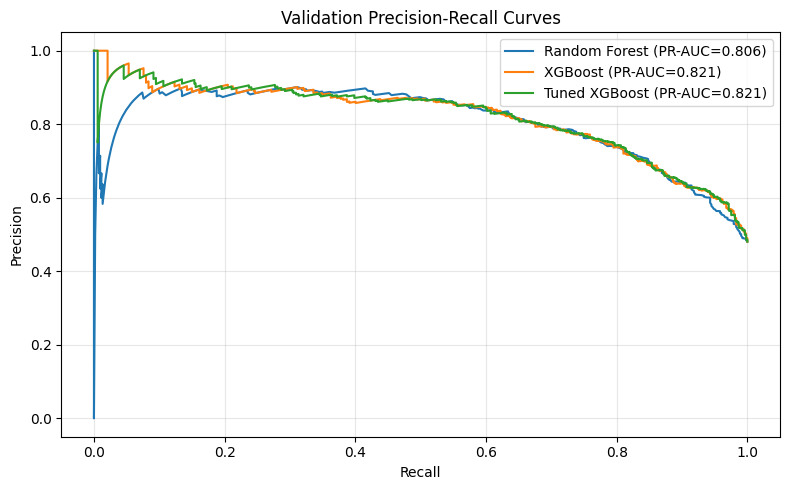

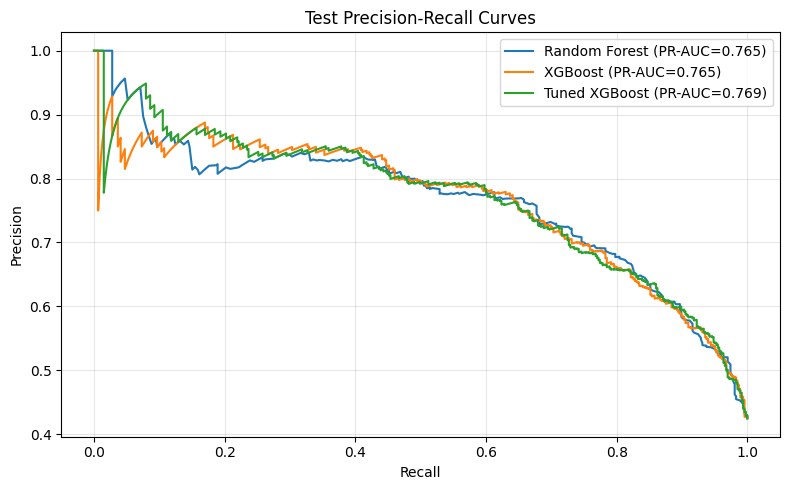

Error-type summary:


,model,error_type,count,mean_probability
0,Random Forest,false_negative,68,0.1189
1,Random Forest,false_positive,238,0.3956
2,Random Forest,true_negative,392,0.0838
3,Random Forest,true_positive,397,0.5492
4,Tuned XGBoost,false_negative,95,0.1899
5,Tuned XGBoost,false_positive,192,0.5918
6,Tuned XGBoost,true_negative,438,0.1037
7,Tuned XGBoost,true_positive,370,0.7193
8,XGBoost,false_negative,87,0.1759
9,XGBoost,false_positive,198,0.5920


Saved: /content/wildfire_temporal_windowed_outputs/primary_error_type_summary.csv
Errors by year:


,model,target_year,error_type,count,mean_probability
0,Random Forest,2021,false_negative,30,0.1207
1,Random Forest,2021,false_positive,86,0.3677
2,Random Forest,2021,true_negative,106,0.0763
3,Random Forest,2021,true_positive,143,0.5430
4,Random Forest,2022,false_negative,21,0.1077
5,Random Forest,2022,false_positive,77,0.4025
6,Random Forest,2022,true_negative,137,0.0935
7,Random Forest,2022,true_positive,130,0.5599
8,Random Forest,2023,false_negative,17,0.1296
9,Random Forest,2023,false_positive,75,0.4204


Saved: /content/wildfire_temporal_windowed_outputs/primary_errors_by_year.csv
Errors by season:


...

Saved: /content/wildfire_temporal_windowed_outputs/advanced_baseline_reference_models.csv
Advanced model deltas versus baseline reference models:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,...,test_precision_tuned,test_recall_tuned,test_f1_tuned,baseline_reference_model,baseline_reference_test_f1,baseline_reference_test_roc_auc,baseline_reference_test_pr_auc,delta_test_f1_vs_baseline_reference,delta_test_roc_auc_vs_baseline_reference,delta_test_pr_auc_vs_baseline_reference
2,advanced_refinement,MLP,baseline_features,1,0.35,0.8482,0.8266,0.7141,0.8482,0.7754,...,0.6371,0.8344,0.7225,XGBoost,0.7262,0.8291,0.7646,-0.0037,-0.0047,-0.0117
0,advanced_refinement,Tuned Random Forest,baseline_features,1,0.30,0.8432,0.8144,0.7625,0.7799,0.7711,...,0.6901,0.7613,0.7239,XGBoost,0.7262,0.8291,0.7646,-0.0023,0.0003,-0.0104
1,advanced_refinement,Tuned XGBoost,baseline_features,1,0.35,0.8441,0.8212,0.7420,0.7970,0.7685,...,0.6584,0.7957,0.7205,XGBoost,0.7262,0.8291,0.7646,-0.0057,0.0005,0.0042
5,advanced_refinement,MLP,engineered_features,3,0.20,0.9052,0.9485,0.8425,0.9302,0.8842,...,0.7923,0.9226,0.8525,Random Forest,0.8539,0.8738,0.9343,-0.0014,0.0035,0.0017
3,advanced_refinement,Tuned Random Forest,engineered_features,3,0.20,0.8958,0.9529,0.8358,0.9051,0.8691,...,0.7985,0.9255,0.8573,Random Forest,0.8539,0.8738,0.9343,0.0035,0.0019,0.0018
4,advanced_refinement,Tuned XGBoost,engineered_features,3,0.10,0.8994,0.9492,0.8226,0.9592,0.8856,...,0.7443,0.9578,0.8376,Random Forest,0.8539,0.8738,0.9343,-0.0162,-0.0003,0.0003
8,advanced_refinement,MLP,engineered_features,7,0.10,0.9180,0.9787,0.8969,0.9543,0.9247,...,0.8624,0.9387,0.8989,Random Forest,0.8899,0.8626,0.9582,0.0091,0.0156,0.0051
6,advanced_refinement,Tuned Random Forest,engineered_features,7,0.20,0.9004,0.9748,0.8842,0.9337,0.9083,...,0.8401,0.9540,0.8934,Random Forest,0.8899,0.8626,0.9582,0.0036,0.0069,0.0025
7,advanced_refinement,Tuned XGBoost,engineered_features,7,0.10,0.9080,0.9765,0.8856,0.9554,0.9192,...,0.8316,0.9611,0.8917,Random Forest,0.8899,0.8626,0.9582,0.0018,-0.0014,0.0000
11,advanced_refinement,MLP,engineered_features,10,0.15,0.9138,0.9838,0.9286,0.9276,0.9281,...,0.8865,0.9351,0.9102,XGBoost,0.9130,0.8472,0.9626,-0.0029,0.0225,0.0076


Saved: /content/wildfire_temporal_windowed_outputs/advanced_delta_vs_baseline_reference.csv
Sequence-model deltas versus prior advanced winners:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,...,test_recall_tuned,test_f1_tuned,best_epoch,prior_advanced_winner,prior_advanced_test_f1,prior_advanced_test_roc_auc,prior_advanced_test_pr_auc,delta_test_f1_vs_prior_advanced,delta_test_roc_auc_vs_prior_advanced,delta_test_pr_auc_vs_prior_advanced
1,sequence_models,GRU,baseline_features,1,0.25,0.8509,0.8265,0.7500,0.8083,0.7781,...,0.7871,0.7284,34,Tuned Random Forest,0.7239,0.8294,0.7542,0.0044,-0.0030,0.0005
0,sequence_models,LSTM,baseline_features,1,0.20,0.8493,0.8259,0.7170,0.8463,0.7763,...,0.8344,0.7219,22,Tuned Random Forest,0.7239,0.8294,0.7542,-0.0021,0.0020,0.0084
3,sequence_models,GRU,engineered_features,3,0.25,0.9020,0.9501,0.8584,0.9104,0.8836,...,0.8819,0.8507,1,Tuned Random Forest,0.8573,0.8757,0.9360,-0.0066,0.0062,0.0040
2,sequence_models,LSTM,engineered_features,3,0.30,0.9023,0.9448,0.8807,0.8854,0.8830,...,0.8706,0.8376,3,Tuned Random Forest,0.8573,0.8757,0.9360,-0.0197,0.0000,-0.0004
5,sequence_models,GRU,engineered_features,7,0.25,0.9185,0.9790,0.9044,0.9406,0.9221,...,0.9210,0.8860,18,MLP,0.8989,0.8782,0.9633,-0.0129,-0.0039,0.0008
4,sequence_models,LSTM,engineered_features,7,0.25,0.9177,0.9789,0.8887,0.9577,0.9219,...,0.9517,0.8927,3,MLP,0.8989,0.8782,0.9633,-0.0062,-0.0124,-0.0029
7,sequence_models,GRU,engineered_features,10,0.20,0.9196,0.9848,0.8949,0.9849,0.9377,...,0.9653,0.9027,17,Tuned Random Forest,0.9143,0.8629,0.9675,-0.0116,-0.0137,-0.0018
6,sequence_models,LSTM,engineered_features,10,0.20,0.9146,0.9838,0.8964,0.9730,0.9331,...,0.9564,0.9125,8,Tuned Random Forest,0.9143,0.8629,0.9675,-0.0018,0.0042,0.0019


Saved: /content/wildfire_temporal_windowed_outputs/sequence_delta_vs_prior_advanced.csv


In [24]:
# =========================
# Source-notebook coverage supplements
# =========================
from sklearn.metrics import precision_recall_curve


def _xgb_params_from_search(search_df: pd.DataFrame) -> Dict:
    """Pull XGBoost hyperparameters from the best search row."""
    if search_df is None or search_df.empty:
        return {}
    parameter_columns = list(XGB_SEARCH_GRID[0].keys())
    score_column = "val_pr_auc" if "val_pr_auc" in search_df.columns else "test_pr_auc"
    best_row = search_df.sort_values(score_column, ascending=False).iloc[0]
    params = {}
    for column_name in parameter_columns:
        if column_name not in best_row.index:
            continue
        value = best_row[column_name]
        if column_name in {"n_estimators", "max_depth"}:
            value = int(value)
        else:
            value = float(value)
        params[column_name] = value
    return params


# 13.1 Precision-recall curves and summary for the strongest primary tree models.
if RUN_PRIMARY_MODELS and "primary_model_objects" in globals():
    primary_tree_results = {
        model_name: primary_model_objects[model_name]
        for model_name in ["Random Forest", "XGBoost", "Tuned XGBoost"]
        if model_name in primary_model_objects
    }

    tree_pr_summary_rows = []
    for model_name, result in primary_tree_results.items():
        tree_pr_summary_rows.append({
            "model": model_name,
            "validation_pr_auc": result["val_metrics"]["pr_auc"],
            "test_pr_auc": result["test_metrics"]["pr_auc"],
            "best_threshold": result["best_threshold"],
            "tuned_test_precision": result["test_metrics"]["precision"],
            "tuned_test_recall": result["test_metrics"]["recall"],
            "tuned_test_f1": result["test_metrics"]["f1"],
        })
    tree_pr_summary_df = pd.DataFrame(tree_pr_summary_rows)
    print("Precision-recall summary for primary tree models:")
    display(tree_pr_summary_df.round(4))
    save_table(tree_pr_summary_df, "primary_tree_precision_recall_summary.csv")

    for split_name, label in [("val", "Validation"), ("test", "Test")]:
        plt.figure(figsize=(8, 5))
        for model_name, result in primary_tree_results.items():
            split_data = result["split"]
            y_true = split_data[f"y_{split_name}"]
            y_prob = result[f"{split_name}_probabilities"]
            precision, recall, _ = precision_recall_curve(y_true, y_prob)
            auc_value = average_precision_score(y_true, y_prob)
            plt.plot(recall, precision, label=f"{model_name} (PR-AUC={auc_value:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{label} Precision-Recall Curves")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# 13.2 Detailed error-analysis tables from the original FE/multihorizon notebook.
if "error_analysis_df" in globals() and not error_analysis_df.empty:
    detailed_error_data = error_analysis_df.copy()
    detailed_error_data["target_year"] = detailed_error_data["target_date"].dt.year

    error_type_summary_df = (
        detailed_error_data.groupby(["model", "error_type"], as_index=False)
        .agg(count=("error_type", "size"), mean_probability=("y_prob", "mean"))
        .sort_values(["model", "error_type"])
        .reset_index(drop=True)
    )
    print("Error-type summary:")
    display(error_type_summary_df.round(4))
    save_table(error_type_summary_df, "primary_error_type_summary.csv")

    errors_by_year_df = (
        detailed_error_data.groupby(["model", "target_year", "error_type"], as_index=False)
        .agg(count=("error_type", "size"), mean_probability=("y_prob", "mean"))
        .sort_values(["model", "target_year", "error_type"])
        .reset_index(drop=True)
    )
    print("Errors by year:")
    display(errors_by_year_df.round(4))
    save_table(errors_by_year_df, "primary_errors_by_year.csv")

    errors_by_season_df = (
        detailed_error_data.groupby(["model", "season", "error_type"], as_index=False)
        .agg(count=("error_type", "size"), mean_probability=("y_prob", "mean"))
        .sort_values(["model", "season", "error_type"])
        .reset_index(drop=True)
    )
    print("Errors by season:")
    display(errors_by_season_df.round(4))
    save_table(errors_by_season_df, "primary_errors_by_season.csv")

    top_false_negatives_df = (
        detailed_error_data[detailed_error_data["error_type"] == "false_negative"]
        .sort_values(["model", "y_prob"], ascending=[True, True])
        .groupby("model")
        .head(10)
        .reset_index(drop=True)
    )
    top_false_positives_df = (
        detailed_error_data[detailed_error_data["error_type"] == "false_positive"]
        .sort_values(["model", "y_prob"], ascending=[True, False])
        .groupby("model")
        .head(10)
        .reset_index(drop=True)
    )
    print("Top high-confidence false negatives:")
    display(top_false_negatives_df.round(4))
    print("Top high-confidence false positives:")
    display(top_false_positives_df.round(4))
    save_table(top_false_negatives_df, "primary_top_false_negatives.csv")
    save_table(top_false_positives_df, "primary_top_false_positives.csv")


# 13.3 Full recent-history sensitivity summary, including dummy and tuned XGBoost.
recent_history_full_results = []
recent_history_model_objects = {}
if RUN_RECENT_HISTORY_SENSITIVITY and RUN_PRIMARY_MODELS:
    if "recent_windowed_split" not in globals():
        recent_train_years = (2008, 2017)
        recent_windowed_split = split_windowed_by_year(primary_windowed_data, train_years=recent_train_years)
    recent_train_years = globals().get("recent_train_years", (2008, 2017))

    recent_model_factories = {
        "Dummy baseline": lambda split: make_dummy_classifier(),
        "Logistic Regression": lambda split: make_logistic_regression_pipeline(),
        "Random Forest": lambda split: make_random_forest(),
        "XGBoost": lambda split: make_xgboost_classifier(split["y_train"]),
    }
    for model_name, model_factory in recent_model_factories.items():
        print(f"Detailed recent-history run: {model_name}")
        fitted_result = fit_and_evaluate_model(model_factory(recent_windowed_split), recent_windowed_split, model_name)
        recent_history_model_objects[model_name] = fitted_result
        recent_history_full_results.append(
            model_result_row(
                fitted_result,
                "baseline_features",
                1,
                "recent_history_sensitivity_full",
                extra_fields={"train_years": f"{recent_train_years[0]}-{recent_train_years[1]}"},
            )
        )

    print("Detailed recent-history run: Tuned XGBoost search")
    recent_tuned_xgb_search_df, recent_tuned_xgb_result = run_parameter_search(
        "XGBoost",
        recent_windowed_split,
        XGB_SEARCH_GRID,
        "baseline_features",
        1,
        "recent_history_tuned_xgboost",
    )
    recent_tuned_xgb_result["model_name"] = "Tuned XGBoost"
    recent_history_model_objects["Tuned XGBoost"] = recent_tuned_xgb_result
    recent_history_full_results.append(
        model_result_row(
            recent_tuned_xgb_result,
            "baseline_features",
            1,
            "recent_history_sensitivity_full",
            extra_fields={"train_years": f"{recent_train_years[0]}-{recent_train_years[1]}"},
        )
    )

    recent_history_full_results_df = pd.DataFrame(recent_history_full_results)
    print("Full recent-history sensitivity results:")
    display(recent_history_full_results_df.round(4))
    save_table(recent_history_full_results_df, "recent_history_sensitivity_full_results.csv")
    save_table(recent_tuned_xgb_search_df, "recent_history_tuned_xgboost_search.csv")

    if "primary_results_df" in globals():
        sensitivity_summary_df = (
            primary_results_df[["model", "test_roc_auc", "test_f1_tuned"]]
            .rename(columns={"test_roc_auc": "primary_test_roc_auc", "test_f1_tuned": "primary_test_f1_tuned"})
            .merge(
                recent_history_full_results_df[["model", "test_roc_auc", "test_f1_tuned"]]
                .rename(columns={"test_roc_auc": "recent_train_test_roc_auc", "test_f1_tuned": "recent_train_test_f1_tuned"}),
                on="model",
                how="inner",
            )
        )
        sensitivity_summary_df["delta_test_roc_auc"] = sensitivity_summary_df["recent_train_test_roc_auc"] - sensitivity_summary_df["primary_test_roc_auc"]
        sensitivity_summary_df["delta_test_f1_tuned"] = sensitivity_summary_df["recent_train_test_f1_tuned"] - sensitivity_summary_df["primary_test_f1_tuned"]
        print("Primary vs recent-history sensitivity summary:")
        display(sensitivity_summary_df.round(4))
        save_table(sensitivity_summary_df, "primary_vs_recent_history_sensitivity_summary.csv")


# 13.4 Original-style full feature-family ablation and targeted recent-history ablation.
ORIGINAL_FEATURE_ABLATION_GROUPS = {
    "calendar_only": CALENDAR_FEATURES,
    "weather_only": [feature for feature in BASE_FEATURES if feature not in CALENDAR_FEATURES],
    "full": BASE_FEATURES,
}

full_ablation_results = []
if RUN_FEATURE_ABLATION and RUN_PRIMARY_MODELS:
    tuned_xgb_params = _xgb_params_from_search(globals().get("tuned_xgb_search_df", pd.DataFrame()))
    for feature_group_name, feature_list in ORIGINAL_FEATURE_ABLATION_GROUPS.items():
        print(f"Full primary ablation feature group: {feature_group_name}")
        ablation_windowed_data, _ = build_windowed_horizon_dataset(daily_data, feature_list, horizon_days=1, window_size=WINDOW_SIZE)
        ablation_split = split_windowed_by_year(ablation_windowed_data)
        ablation_model_factories = {
            "Dummy baseline": lambda split: make_dummy_classifier(),
            "Logistic Regression": lambda split: make_logistic_regression_pipeline(),
            "Random Forest": lambda split: make_random_forest(),
            "XGBoost": lambda split: make_xgboost_classifier(split["y_train"]),
            "Tuned XGBoost": lambda split, params=tuned_xgb_params: make_xgboost_classifier(split["y_train"], **params),
        }
        for model_name, model_factory in ablation_model_factories.items():
            print(f"  Training {model_name}...")
            fitted_result = fit_and_evaluate_model(model_factory(ablation_split), ablation_split, model_name)
            full_ablation_results.append(model_result_row(fitted_result, feature_group_name, 1, "feature_ablation_full"))

    full_ablation_results_df = pd.DataFrame(full_ablation_results)
    print("Full primary feature-family ablation:")
    display_sorted(full_ablation_results_df, ["feature_set", "model"])
    save_table(full_ablation_results_df, "feature_ablation_full_results.csv")

recent_targeted_ablation_results = []
if RUN_FEATURE_ABLATION and RUN_RECENT_HISTORY_SENSITIVITY and RUN_PRIMARY_MODELS:
    recent_xgb_params = _xgb_params_from_search(globals().get("recent_tuned_xgb_search_df", pd.DataFrame()))
    if not recent_xgb_params:
        recent_xgb_params = _xgb_params_from_search(globals().get("tuned_xgb_search_df", pd.DataFrame()))
    for feature_group_name, feature_list in ORIGINAL_FEATURE_ABLATION_GROUPS.items():
        print(f"Recent-history targeted ablation feature group: {feature_group_name}")
        recent_ablation_windowed_data, _ = build_windowed_horizon_dataset(daily_data, feature_list, horizon_days=1, window_size=WINDOW_SIZE)
        recent_ablation_split = split_windowed_by_year(recent_ablation_windowed_data, train_years=(2008, 2017))
        recent_ablation_model_factories = {
            "Random Forest": lambda split: make_random_forest(),
            "XGBoost": lambda split: make_xgboost_classifier(split["y_train"]),
            "Tuned XGBoost": lambda split, params=recent_xgb_params: make_xgboost_classifier(split["y_train"], **params),
        }
        for model_name, model_factory in recent_ablation_model_factories.items():
            print(f"  Training {model_name}...")
            fitted_result = fit_and_evaluate_model(model_factory(recent_ablation_split), recent_ablation_split, model_name)
            recent_targeted_ablation_results.append(
                model_result_row(
                    fitted_result,
                    feature_group_name,
                    1,
                    "recent_history_targeted_ablation",
                    extra_fields={"train_years": "2008-2017"},
                )
            )

    recent_targeted_ablation_results_df = pd.DataFrame(recent_targeted_ablation_results)
    print("Recent-history targeted ablation:")
    display_sorted(recent_targeted_ablation_results_df, ["feature_set", "model"])
    save_table(recent_targeted_ablation_results_df, "recent_history_targeted_ablation_results.csv")


# 13.5 Horizon-shortlist delta tables and model-refinement delta comparisons.
if "shortlist_results_df" in globals() and not shortlist_results_df.empty:
    shortlist_delta_rows = []
    for (horizon_days, model_name), group_data in shortlist_results_df.groupby(["horizon_days", "model"]):
        baseline_rows = group_data[group_data["feature_set"] == "baseline_features"]
        engineered_rows = group_data[group_data["feature_set"] == "engineered_features"]
        if baseline_rows.empty or engineered_rows.empty:
            continue
        baseline_row = baseline_rows.iloc[0]
        engineered_row = engineered_rows.iloc[0]
        shortlist_delta_rows.append({
            "horizon_days": horizon_days,
            "model": model_name,
            "delta_test_roc_auc_engineered_minus_baseline": engineered_row["test_roc_auc"] - baseline_row["test_roc_auc"],
            "delta_test_pr_auc_engineered_minus_baseline": engineered_row["test_pr_auc"] - baseline_row["test_pr_auc"],
            "delta_test_f1_engineered_minus_baseline": engineered_row["test_f1_tuned"] - baseline_row["test_f1_tuned"],
            "baseline_test_f1": baseline_row["test_f1_tuned"],
            "engineered_test_f1": engineered_row["test_f1_tuned"],
        })
    shortlist_delta_df = pd.DataFrame(shortlist_delta_rows)
    print("Engineered-minus-baseline delta table for shortlisted horizons:")
    display(shortlist_delta_df.round(4))
    save_table(shortlist_delta_df, "horizon_shortlist_engineered_delta.csv")

if "advanced_results_df" in globals() and "shortlist_results_df" in globals():
    advanced_baseline_rows = []
    for horizon_days, feature_set in KEEPER_FEATURE_SET_BY_HORIZON.items():
        reference_rows = shortlist_results_df[
            (shortlist_results_df["horizon_days"] == horizon_days)
            & (shortlist_results_df["feature_set"] == feature_set)
            & (shortlist_results_df["model"].isin(["Random Forest", "XGBoost"]))
        ]
        advanced_baseline_rows.append(reference_rows)
    advanced_baseline_reference_df = pd.concat(advanced_baseline_rows, ignore_index=True) if advanced_baseline_rows else pd.DataFrame()
    print("Baseline reference models on keeper feature setup:")
    display(advanced_baseline_reference_df.round(4))
    save_table(advanced_baseline_reference_df, "advanced_baseline_reference_models.csv")

    baseline_best_by_horizon_df = (
        advanced_baseline_reference_df.sort_values(["horizon_days", "test_f1_tuned"], ascending=[True, False])
        .groupby("horizon_days")
        .head(1)
        .reset_index(drop=True)
        .rename(columns={
            "model": "baseline_reference_model",
            "test_f1_tuned": "baseline_reference_test_f1",
            "test_roc_auc": "baseline_reference_test_roc_auc",
            "test_pr_auc": "baseline_reference_test_pr_auc",
        })
    )
    advanced_delta_df = advanced_results_df.merge(
        baseline_best_by_horizon_df[["horizon_days", "baseline_reference_model", "baseline_reference_test_f1", "baseline_reference_test_roc_auc", "baseline_reference_test_pr_auc"]],
        on="horizon_days",
        how="left",
    )
    advanced_delta_df["delta_test_f1_vs_baseline_reference"] = advanced_delta_df["test_f1_tuned"] - advanced_delta_df["baseline_reference_test_f1"]
    advanced_delta_df["delta_test_roc_auc_vs_baseline_reference"] = advanced_delta_df["test_roc_auc"] - advanced_delta_df["baseline_reference_test_roc_auc"]
    advanced_delta_df["delta_test_pr_auc_vs_baseline_reference"] = advanced_delta_df["test_pr_auc"] - advanced_delta_df["baseline_reference_test_pr_auc"]
    print("Advanced model deltas versus baseline reference models:")
    display_sorted(advanced_delta_df, ["horizon_days", "model"])
    save_table(advanced_delta_df, "advanced_delta_vs_baseline_reference.csv")

if "sequence_results_df" in globals() and "advanced_winners_df" in globals():
    sequence_delta_df = sequence_results_df.merge(
        advanced_winners_df[["horizon_days", "model", "test_f1_tuned", "test_roc_auc", "test_pr_auc"]].rename(columns={
            "model": "prior_advanced_winner",
            "test_f1_tuned": "prior_advanced_test_f1",
            "test_roc_auc": "prior_advanced_test_roc_auc",
            "test_pr_auc": "prior_advanced_test_pr_auc",
        }),
        on="horizon_days",
        how="left",
    )
    sequence_delta_df["delta_test_f1_vs_prior_advanced"] = sequence_delta_df["test_f1_tuned"] - sequence_delta_df["prior_advanced_test_f1"]
    sequence_delta_df["delta_test_roc_auc_vs_prior_advanced"] = sequence_delta_df["test_roc_auc"] - sequence_delta_df["prior_advanced_test_roc_auc"]
    sequence_delta_df["delta_test_pr_auc_vs_prior_advanced"] = sequence_delta_df["test_pr_auc"] - sequence_delta_df["prior_advanced_test_pr_auc"]
    print("Sequence-model deltas versus prior advanced winners:")
    display_sorted(sequence_delta_df, ["horizon_days", "model"])
    save_table(sequence_delta_df, "sequence_delta_vs_prior_advanced.csv")


## 14. Temporal-analysis outputs

This section integrates the temporal-analysis.

These analyses were created before the TA clarified the dataset interpretation. They are retained because they provide useful temporal EDA, seasonality, anomaly, and model-behavior diagnostics. The findings show aggregate temporal structure in the dataset, but they should not be interpreted as proof that 6-row rolling windows are valid same-location temporal sequences.

In [25]:
# =========================
# Exploratory temporal-analysis helpers
# =========================
MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
DAY_OF_YEAR_TICKS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
TEMPORAL_DIAGNOSTIC_HORIZON = 1


def print_analysis_block(title: str) -> None:
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)


def prepare_exploratory_temporal_data(input_data: pd.DataFrame) -> pd.DataFrame:
    """Prepare date-derived columns needed for the exploratory temporal analysis."""
    temporal_data = input_data.copy().sort_values(DATE_COL).reset_index(drop=True)
    temporal_data[DATE_COL] = pd.to_datetime(temporal_data[DATE_COL])
    temporal_data["YEAR"] = temporal_data[DATE_COL].dt.year
    temporal_data["MONTH"] = temporal_data[DATE_COL].dt.month
    temporal_data["DAY_OF_YEAR"] = temporal_data[DATE_COL].dt.dayofyear
    temporal_data["DECADE"] = (temporal_data["YEAR"] // 10) * 10
    if "SEASON" not in temporal_data.columns:
        temporal_data["SEASON"] = temporal_data["MONTH"].map({
            12: "Winter", 1: "Winter", 2: "Winter",
            3: "Spring", 4: "Spring", 5: "Spring",
            6: "Summer", 7: "Summer", 8: "Summer",
            9: "Fall", 10: "Fall", 11: "Fall",
        })
    return temporal_data


def analyze_annual_fire_trend(temporal_data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    annual_fire_summary = (
        temporal_data.groupby("YEAR")[TARGET_COL]
        .agg(fire_days="sum", fire_rate="mean", num_days="count")
        .reset_index()
    )
    slope, intercept, r_value, p_value, _ = stats.linregress(
        annual_fire_summary["YEAR"], annual_fire_summary["fire_rate"]
    )
    annual_fire_summary["linear_trend"] = slope * annual_fire_summary["YEAR"] + intercept
    trend_stats = pd.DataFrame([{
        "slope_per_year": slope,
        "r_squared": r_value ** 2,
        "p_value": p_value,
        "significant_at_0_05": p_value < 0.05,
        "implied_change_1984_2023": slope * (annual_fire_summary["YEAR"].max() - annual_fire_summary["YEAR"].min()),
    }])

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].bar(annual_fire_summary["YEAR"], annual_fire_summary["fire_days"], alpha=0.75, label="Observed annual count")
    axes[0].plot(
        annual_fire_summary["YEAR"],
        annual_fire_summary["fire_days"].rolling(5, min_periods=1).mean(),
        linewidth=2.5,
        label="5-year rolling mean of fire-positive days",
    )
    axes[0].axvline(PRIMARY_TRAIN_YEARS[1], linestyle="--", alpha=0.7, label="Train/Val split")
    axes[0].axvline(PRIMARY_VAL_YEARS[1], linestyle="--", alpha=0.7, label="Val/Test split")
    axes[0].set_title("Total Fire-Positive Days Per Year (1984-2023)")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Number of Fire-Positive Days")
    axes[0].legend()

    axes[1].scatter(annual_fire_summary["YEAR"], annual_fire_summary["fire_rate"], alpha=0.65, label="Observed annual fire-day rate")
    axes[1].plot(
        annual_fire_summary["YEAR"],
        annual_fire_summary["linear_trend"],
        linestyle="--",
        linewidth=2,
        label="Linear trend fit",
    )
    axes[1].axvline(PRIMARY_TRAIN_YEARS[1], linestyle="--", alpha=0.7)
    axes[1].axvline(PRIMARY_VAL_YEARS[1], linestyle="--", alpha=0.7)
    axes[1].set_title("Annual Fire-Day Rate Trend with Linear Fit")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Share of Days with Fire-Start Label")
    axes[1].annotate(
        f"Upward trend, R² = {r_value ** 2:.3f}" if slope > 0 else f"Downward trend, R² = {r_value ** 2:.3f}",
        xy=(0.02, 0.90),
        xycoords="axes fraction",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return annual_fire_summary, trend_stats


def plot_fire_season_shape_by_decade(temporal_data: pd.DataFrame) -> pd.DataFrame:
    decade_day_summary = (
        temporal_data.groupby(["DECADE", "DAY_OF_YEAR"])[TARGET_COL]
        .mean()
        .reset_index(name="fire_probability")
    )
    plt.figure(figsize=(14, 5))
    for decade in sorted(decade_day_summary["DECADE"].unique()):
        decade_data = decade_day_summary.loc[decade_day_summary["DECADE"] == decade].set_index("DAY_OF_YEAR")
        smoothed_probability = decade_data["fire_probability"].rolling(14, center=True, min_periods=1).mean()
        plt.plot(smoothed_probability.index, smoothed_probability.values, label=str(decade), linewidth=1.8)
    plt.title("Seasonal Fire-Day Rate by Decade")
    plt.xlabel("Day of Year")
    plt.ylabel("14-Day Rolling Fire-Day Rate")
    plt.xticks(DAY_OF_YEAR_TICKS, MONTH_LABELS)
    plt.legend(title="Decade")
    plt.tight_layout()
    plt.show()
    return decade_day_summary


def analyze_first_fire_day_trend(temporal_data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    first_fire_day = (
        temporal_data.loc[temporal_data[TARGET_COL] == 1]
        .groupby("YEAR")["DAY_OF_YEAR"]
        .min()
        .reset_index(name="first_fire_day_of_year")
    )
    slope, intercept, r_value, p_value, _ = stats.linregress(
        first_fire_day["YEAR"], first_fire_day["first_fire_day_of_year"]
    )
    first_fire_day["linear_trend"] = slope * first_fire_day["YEAR"] + intercept
    first_fire_summary = pd.DataFrame([{
        "slope_days_per_year": slope,
        "r_squared": r_value ** 2,
        "p_value": p_value,
        "significant_at_0_05": p_value < 0.05,
        "implied_shift_days": slope * (first_fire_day["YEAR"].max() - first_fire_day["YEAR"].min()),
    }])

    plt.figure(figsize=(12, 4))
    plt.scatter(first_fire_day["YEAR"], first_fire_day["first_fire_day_of_year"], alpha=0.65)
    plt.plot(first_fire_day["YEAR"], first_fire_day["linear_trend"], linestyle="--", linewidth=2,
             label=f"Trend {slope:.2f} days/yr, p={p_value:.3f}")
    plt.title("First Fire-Positive Day of Year Over Time")
    plt.xlabel("Year")
    plt.ylabel("Day of Year")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return first_fire_day, first_fire_summary


def analyze_annual_weather_trends(temporal_data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    weather_features = ["MAX_TEMP", "MIN_TEMP", "PRECIPITATION", "AVG_WIND_SPEED"]
    annual_weather_summary = temporal_data.groupby("YEAR")[weather_features].mean().reset_index()
    weather_trend_rows = []

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for axis, feature_name in zip(axes.flatten(), weather_features):
        slope, intercept, r_value, p_value, _ = stats.linregress(
            annual_weather_summary["YEAR"], annual_weather_summary[feature_name]
        )
        weather_trend_rows.append({
            "feature": feature_name,
            "slope_per_year": slope,
            "r_squared": r_value ** 2,
            "p_value": p_value,
            "significant_at_0_05": p_value < 0.05,
        })
        axis.scatter(annual_weather_summary["YEAR"], annual_weather_summary[feature_name], alpha=0.55)
        axis.plot(annual_weather_summary["YEAR"], slope * annual_weather_summary["YEAR"] + intercept,
                  linestyle="--", linewidth=2)
        axis.set_title(f"{feature_name} (slope={slope:.4f}/yr, p={p_value:.3f})")
        axis.set_xlabel("Year")
        axis.axvline(PRIMARY_TRAIN_YEARS[1], linestyle=":", alpha=0.6)
    plt.suptitle("Annual Mean Weather Features Over Time", fontsize=13)
    plt.tight_layout()
    plt.show()

    return annual_weather_summary, pd.DataFrame(weather_trend_rows)


def plot_base_feature_acf_pacf(temporal_data: pd.DataFrame) -> None:
    """Plot fast ACF/PACF diagnostics without the slower statsmodels plotting wrapper."""
    autocorrelation_features = ["MAX_TEMP", "MIN_TEMP", "PRECIPITATION", "AVG_WIND_SPEED", TARGET_COL]
    max_lag = 14
    fig, axes = plt.subplots(len(autocorrelation_features), 2, figsize=(14, 18))
    lag_index = np.arange(max_lag + 1)
    for row_index, feature_name in enumerate(autocorrelation_features):
        feature_series = temporal_data[feature_name].dropna().to_numpy(dtype=float)
        acf_values = compute_acf(feature_series, nlags=max_lag, fft=True)
        pacf_values = compute_pacf(feature_series, nlags=max_lag, method="ywm")

        axes[row_index][0].bar(lag_index, acf_values, alpha=0.75)
        axes[row_index][0].axhline(0, linewidth=0.8)
        axes[row_index][0].set_title(f"{feature_name} — ACF")
        axes[row_index][0].set_xlabel("Lag (days)")
        axes[row_index][0].set_ylabel("Correlation")

        axes[row_index][1].bar(lag_index, pacf_values, alpha=0.75)
        axes[row_index][1].axhline(0, linewidth=0.8)
        axes[row_index][1].set_title(f"{feature_name} — PACF")
        axes[row_index][1].set_xlabel("Lag (days)")
        axes[row_index][1].set_ylabel("Partial correlation")
    plt.suptitle("Day-to-Day Temporal Persistence in Aggregate Statewide Features", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

def compute_lag_correlation_table(
    temporal_data: pd.DataFrame,
    feature_names: List[str],
    lag_days: List[int],
) -> pd.DataFrame:
    lag_rows = []
    for feature_name in feature_names:
        for lag_day in lag_days:
            lag_rows.append({
                "feature": feature_name,
                "lag_days": lag_day,
                "correlation_with_fire_day": temporal_data[TARGET_COL].corr(temporal_data[feature_name].shift(lag_day)),
            })
    return pd.DataFrame(lag_rows)


def compute_autocorrelation_by_era(temporal_data: pd.DataFrame) -> pd.DataFrame:
    era_definitions = [
        (1984, 1999, "1984-1999"),
        (2000, 2009, "2000-2009"),
        (2010, 2017, "2010-2017"),
        (2018, 2023, "2018-2023"),
    ]
    feature_names = ["MAX_TEMP", "MIN_TEMP", "AVG_WIND_SPEED", "PRECIPITATION"]
    era_rows = []
    for start_year, end_year, era_label in era_definitions:
        era_data = temporal_data.loc[temporal_data["YEAR"].between(start_year, end_year)]
        for feature_name in feature_names:
            era_rows.append({
                "era": era_label,
                "feature": feature_name,
                "lag_1_autocorrelation": era_data[feature_name].corr(era_data[feature_name].shift(1)),
            })
    return pd.DataFrame(era_rows)


def compute_seasonal_fire_autocorrelation(temporal_data: pd.DataFrame) -> pd.DataFrame:
    season_rows = []
    for season_name in ["Winter", "Spring", "Summer", "Fall"]:
        season_series = temporal_data.loc[temporal_data["SEASON"] == season_name, TARGET_COL]
        season_rows.append({
            "season": season_name,
            "lag_1_fire_day_autocorrelation": season_series.corr(season_series.shift(1)),
            "num_days": int(len(season_series)),
        })
    return pd.DataFrame(season_rows)


def build_anomaly_flag_data(temporal_data: pd.DataFrame) -> pd.DataFrame:
    training_period_data = temporal_data.loc[temporal_data["YEAR"] <= PRIMARY_TRAIN_YEARS[1]].copy()
    anomaly_definitions = {
        "MAX_TEMP": "high",
        "AVG_WIND_SPEED": "high",
        "PRECIPITATION": "low",
        "MIN_TEMP": "low",
    }
    anomaly_data = temporal_data.copy()
    for feature_name, direction in anomaly_definitions.items():
        training_mean = training_period_data[feature_name].mean()
        training_std = training_period_data[feature_name].std()
        z_score_column = f"{feature_name}_Z"
        anomaly_column = f"{feature_name}_ANOM"
        anomaly_data[z_score_column] = (anomaly_data[feature_name] - training_mean) / training_std
        if direction == "high":
            anomaly_data[anomaly_column] = (anomaly_data[z_score_column] > 2).astype(int)
        else:
            anomaly_data[anomaly_column] = (anomaly_data[z_score_column] < -2).astype(int)
    anomaly_columns = [f"{feature_name}_ANOM" for feature_name in anomaly_definitions]
    anomaly_data["N_ANOMALIES"] = anomaly_data[anomaly_columns].sum(axis=1)
    anomaly_data["COMPOUND_ANOM"] = (anomaly_data["N_ANOMALIES"] >= 2).astype(int)
    return anomaly_data


def summarize_anomaly_fire_rates(anomaly_data: pd.DataFrame) -> pd.DataFrame:
    condition_masks = {
        "Normal days": anomaly_data["COMPOUND_ANOM"] == 0,
        "Extreme heat only": anomaly_data["MAX_TEMP_ANOM"] == 1,
        "Extreme wind only": anomaly_data["AVG_WIND_SPEED_ANOM"] == 1,
        "Extreme dry only": anomaly_data["PRECIPITATION_ANOM"] == 1,
        "Low MIN_TEMP only": anomaly_data["MIN_TEMP_ANOM"] == 1,
        "Compound (2+ flags)": anomaly_data["COMPOUND_ANOM"] == 1,
    }
    summary_rows = []
    for condition_name, condition_mask in condition_masks.items():
        condition_data = anomaly_data.loc[condition_mask]
        summary_rows.append({
            "condition": condition_name,
            "fire_rate": condition_data[TARGET_COL].mean(),
            "num_days": int(condition_mask.sum()),
        })
    return pd.DataFrame(summary_rows)


def plot_anomaly_patterns(anomaly_data: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    monthly_anomaly_rate = anomaly_data.groupby("MONTH")["COMPOUND_ANOM"].mean()
    monthly_anomaly_rate.plot(kind="bar", ax=axes[0], alpha=0.85)
    axes[0].set_title("Compound Weather-Anomaly Rate by Month")
    axes[0].set_xticklabels(MONTH_LABELS, rotation=45)
    axes[0].set_ylabel("Proportion of Anomalous Days")
    axes[0].set_xlabel("Month")

    season_compound_summary = (
        anomaly_data.groupby(["SEASON", "COMPOUND_ANOM"])[TARGET_COL]
        .mean()
        .unstack()
        .rename(columns={0: "Normal", 1: "Compound Anomaly"})
    )
    season_compound_summary.plot(kind="bar", ax=axes[1], alpha=0.85)
    axes[1].set_title("Fire-Day Rate: Normal vs Compound Anomaly by Season")
    axes[1].set_xlabel("Season")
    axes[1].set_ylabel("Fire Rate")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_day_of_year_fire_probability(temporal_data: pd.DataFrame) -> pd.DataFrame:
    day_of_year_fire_rate = temporal_data.groupby("DAY_OF_YEAR")[TARGET_COL].mean().reset_index(name="fire_probability")
    day_of_year_fire_rate["smoothed_fire_probability"] = (
        day_of_year_fire_rate["fire_probability"].rolling(14, center=True, min_periods=1).mean()
    )
    plt.figure(figsize=(14, 4))
    plt.fill_between(
        day_of_year_fire_rate["DAY_OF_YEAR"],
        day_of_year_fire_rate["smoothed_fire_probability"],
        alpha=0.25,
    )
    plt.plot(
        day_of_year_fire_rate["DAY_OF_YEAR"],
        day_of_year_fire_rate["smoothed_fire_probability"],
        linewidth=2,
    )
    plt.axhline(temporal_data[TARGET_COL].mean(), linestyle="--", label=f"Overall mean ({temporal_data[TARGET_COL].mean():.3f})")
    plt.title("Fire-Day Rate by Day of Year, 1984-2023 (14-Day Rolling)")
    plt.xlabel("Day of Year")
    plt.ylabel("Fire Probability")
    plt.xticks(DAY_OF_YEAR_TICKS, MONTH_LABELS)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return day_of_year_fire_rate


def summarize_fire_streaks(temporal_data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    sorted_data = temporal_data.sort_values(DATE_COL).reset_index(drop=True)
    streak_lengths = []
    current_streak_length = 0
    for target_value in sorted_data[TARGET_COL]:
        if target_value == 1:
            current_streak_length += 1
        else:
            if current_streak_length > 0:
                streak_lengths.append(current_streak_length)
            current_streak_length = 0
    if current_streak_length > 0:
        streak_lengths.append(current_streak_length)

    streak_series = pd.Series(streak_lengths, name="streak_length")
    streak_summary = pd.DataFrame([{
        "total_streaks": int(len(streak_series)),
        "mean_streak_days": streak_series.mean(),
        "median_streak_days": streak_series.median(),
        "max_streak_days": int(streak_series.max()),
        "single_day_streak_share": (streak_series == 1).mean(),
        "three_plus_day_streak_share": (streak_series >= 3).mean(),
        "seven_plus_day_streak_share": (streak_series >= 7).mean(),
    }])
    streak_distribution = streak_series.value_counts().sort_index().reset_index()
    streak_distribution.columns = ["streak_length", "num_streaks"]

    streak_distribution.head(15).plot(x="streak_length", y="num_streaks", kind="bar", figsize=(12, 4), legend=False, alpha=0.85)
    plt.title("Distribution of Consecutive Fire-Positive Day Streaks")
    plt.xlabel("Streak Length (days)")
    plt.ylabel("Number of Streaks")
    plt.tight_layout()
    plt.show()
    return streak_summary, streak_distribution


def plot_monthly_fire_rate_heatmap(temporal_data: pd.DataFrame) -> pd.DataFrame:
    monthly_fire_heatmap = temporal_data.pivot_table(index="YEAR", columns="MONTH", values=TARGET_COL, aggfunc="mean")
    monthly_fire_heatmap = monthly_fire_heatmap.reindex(columns=range(1, 13))
    monthly_fire_heatmap.columns = MONTH_LABELS

    fig, axis = plt.subplots(figsize=(14, 10))
    heatmap = axis.imshow(monthly_fire_heatmap.values, aspect="auto")
    plt.colorbar(heatmap, ax=axis, label="Fire Rate")
    axis.set_xticks(range(12))
    axis.set_xticklabels(MONTH_LABELS)
    axis.set_yticks(range(len(monthly_fire_heatmap.index)))
    axis.set_yticklabels(monthly_fire_heatmap.index.astype(int))
    axis.set_title("Monthly Fire Rate by Year (1984-2023)")
    axis.set_xlabel("Month")
    axis.set_ylabel("Year")

    year_list = list(monthly_fire_heatmap.index)
    if PRIMARY_TRAIN_YEARS[1] in year_list:
        axis.axhline(year_list.index(PRIMARY_TRAIN_YEARS[1]) + 0.5, linewidth=2, linestyle="--", label="Train/Val split")
    if PRIMARY_VAL_YEARS[1] in year_list:
        axis.axhline(year_list.index(PRIMARY_VAL_YEARS[1]) + 0.5, linewidth=2, linestyle="--", label="Val/Test split")
    axis.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
    return monthly_fire_heatmap.reset_index()


def run_exploratory_temporal_diagnostic_model(temporal_data: pd.DataFrame) -> Dict:
    """Train the exploratory's temporal-windowed 6-row + 1-day Random Forest diagnostic model."""
    diagnostic_windowed_data, diagnostic_feature_names = build_windowed_horizon_dataset(
        temporal_data, BASE_FEATURES, horizon_days=TEMPORAL_DIAGNOSTIC_HORIZON, window_size=WINDOW_SIZE
    )
    diagnostic_split = split_windowed_by_year(diagnostic_windowed_data)
    print(f"Train windows:      {len(diagnostic_split['X_train'])} ({diagnostic_split['y_train'].mean():.3f} fire rate)")
    print(f"Validation windows: {len(diagnostic_split['X_val'])} ({diagnostic_split['y_val'].mean():.3f} fire rate)")
    print(f"Test windows:       {len(diagnostic_split['X_test'])} ({diagnostic_split['y_test'].mean():.3f} fire rate)")
    print(f"Feature count:      {len(diagnostic_feature_names)}")

    diagnostic_model = RandomForestClassifier(
        n_estimators=80 if FAST_RUN else 400,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    print("Training exploratory diagnostic Random Forest on the sklearn CPU path.")
    print("Note: XGBoost and PyTorch sections use CUDA when available; sklearn RandomForest is CPU-bound unless RAPIDS/cuML is installed and intentionally substituted.")
    start_time = time.time()
    diagnostic_result = fit_and_evaluate_model(diagnostic_model, diagnostic_split, "Exploratory Temporal Diagnostic RF")
    print(f"Diagnostic RF training/evaluation finished in {time.time() - start_time:.1f}s")
    return diagnostic_result


def summarize_diagnostic_model_metrics(diagnostic_result: Dict) -> pd.DataFrame:
    metric_rows = []
    for split_name, metric_values in [("validation", diagnostic_result["val_metrics"]), ("test", diagnostic_result["test_metrics"] )]:
        metric_rows.append({
            "split": split_name,
            "roc_auc": metric_values["roc_auc"],
            "pr_auc": metric_values["pr_auc"],
            "precision": metric_values["precision"],
            "recall": metric_values["recall"],
            "f1": metric_values["f1"],
            "threshold": diagnostic_result["best_threshold"],
        })
    return pd.DataFrame(metric_rows)


def plot_diagnostic_confusion_matrices(diagnostic_result: Dict) -> None:
    split_data = diagnostic_result["split"]
    validation_predictions = (diagnostic_result["val_probabilities"] >= diagnostic_result["best_threshold"]).astype(int)
    test_predictions = (diagnostic_result["test_probabilities"] >= diagnostic_result["best_threshold"]).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        split_data["y_val"], validation_predictions, display_labels=["No Fire", "Fire"], cmap="Oranges", ax=axes[0]
    )
    axes[0].set_title(f"Validation — Threshold {diagnostic_result['best_threshold']:.2f}")
    ConfusionMatrixDisplay.from_predictions(
        split_data["y_test"], test_predictions, display_labels=["No Fire", "Fire"], cmap="Blues", ax=axes[1]
    )
    axes[1].set_title(f"Test — Threshold {diagnostic_result['best_threshold']:.2f}")
    plt.tight_layout()
    plt.show()


def build_temporal_test_analysis(temporal_data: pd.DataFrame, anomaly_data: pd.DataFrame, diagnostic_result: Dict) -> pd.DataFrame:
    split_data = diagnostic_result["split"]
    test_predictions = (diagnostic_result["test_probabilities"] >= diagnostic_result["best_threshold"]).astype(int)
    prediction_data = pd.DataFrame({
        DATE_COL: split_data["dates_test"].reset_index(drop=True),
        "y_true": split_data["y_test"].reset_index(drop=True).astype(int),
        "y_pred": test_predictions.astype(int),
        "y_proba": diagnostic_result["test_probabilities"],
    })
    test_period_anomaly_data = anomaly_data.loc[
        anomaly_data["YEAR"].between(PRIMARY_TEST_YEARS[0], PRIMARY_TEST_YEARS[1])
    ].copy()
    temporal_test_analysis = test_period_anomaly_data.merge(prediction_data, on=DATE_COL, how="inner")
    alignment_rate = (temporal_test_analysis["y_true"] == temporal_test_analysis[TARGET_COL]).mean()
    print(f"Matched test rows: {len(temporal_test_analysis)}")
    print(f"Alignment check:   {alignment_rate:.4f}")
    print(f"True fire days:    {int(temporal_test_analysis['y_true'].sum())}")
    print(f"Predicted fires:   {int(temporal_test_analysis['y_pred'].sum())}")
    return temporal_test_analysis


def summarize_false_negatives_by_season(temporal_test_analysis: pd.DataFrame) -> pd.DataFrame:
    season_rows = []
    for season_name in ["Winter", "Spring", "Summer", "Fall"]:
        seasonal_fire_data = temporal_test_analysis.loc[
            (temporal_test_analysis["SEASON"] == season_name) & (temporal_test_analysis["y_true"] == 1)
        ]
        if seasonal_fire_data.empty:
            continue
        missed_count = int((seasonal_fire_data["y_pred"] == 0).sum())
        season_rows.append({
            "season": season_name,
            "false_negative_rate": missed_count / len(seasonal_fire_data),
            "missed_fire_days": missed_count,
            "total_fire_days": int(len(seasonal_fire_data)),
        })
    false_negative_summary = pd.DataFrame(season_rows)
    fig, axis = plt.subplots(figsize=(8, 4))
    axis.bar(false_negative_summary["season"], false_negative_summary["false_negative_rate"], alpha=0.85)
    axis.set_title("False-Negative Rate by Season (Test Years 2021-2023)")
    axis.set_ylabel("False Negative Rate")
    axis.set_ylim(0, 1)
    axis.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.show()
    return false_negative_summary


def summarize_error_profiles(temporal_test_analysis: pd.DataFrame) -> pd.DataFrame:
    error_groups = {
        "false_negative": temporal_test_analysis.loc[(temporal_test_analysis["y_true"] == 1) & (temporal_test_analysis["y_pred"] == 0)],
        "true_positive": temporal_test_analysis.loc[(temporal_test_analysis["y_true"] == 1) & (temporal_test_analysis["y_pred"] == 1)],
        "false_positive": temporal_test_analysis.loc[(temporal_test_analysis["y_true"] == 0) & (temporal_test_analysis["y_pred"] == 1)],
    }
    profile_rows = []
    for error_label, error_data in error_groups.items():
        profile_rows.append({
            "error_group": error_label,
            "count": int(len(error_data)),
            "compound_anomaly_rate": error_data["COMPOUND_ANOM"].mean(),
            "mean_max_temp": error_data["MAX_TEMP"].mean(),
            "mean_avg_wind_speed": error_data["AVG_WIND_SPEED"].mean(),
            "mean_precipitation": error_data["PRECIPITATION"].mean(),
            "mean_model_probability": error_data["y_proba"].mean(),
            "low_confidence_count_lt_0_2": int((error_data["y_proba"] < 0.2).sum()) if "y_proba" in error_data else 0,
        })
    return pd.DataFrame(profile_rows)


def plot_confidence_and_monthly_errors(temporal_test_analysis: pd.DataFrame) -> pd.DataFrame:
    false_negative_data = temporal_test_analysis.loc[(temporal_test_analysis["y_true"] == 1) & (temporal_test_analysis["y_pred"] == 0)]
    true_positive_data = temporal_test_analysis.loc[(temporal_test_analysis["y_true"] == 1) & (temporal_test_analysis["y_pred"] == 1)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(false_negative_data["y_proba"], bins=20, alpha=0.6, label=f"Missed fires (n={len(false_negative_data)})")
    axes[0].hist(true_positive_data["y_proba"], bins=20, alpha=0.6, label=f"Caught fires (n={len(true_positive_data)})")
    axes[0].set_title("Model Confidence for Caught vs Missed Fire Days")
    axes[0].set_xlabel("Predicted Fire Probability")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    false_negatives_by_month = false_negative_data.groupby("MONTH").size()
    real_fires_by_month = temporal_test_analysis.loc[temporal_test_analysis["y_true"] == 1].groupby("MONTH").size()
    false_negative_rate_by_month = (false_negatives_by_month / real_fires_by_month).fillna(0).reindex(range(1, 13), fill_value=0)
    false_negative_rate_by_month.plot(kind="bar", ax=axes[1], alpha=0.85)
    axes[1].set_title("False-Negative Rate by Month (Test Years 2021-2023)")
    axes[1].set_xticklabels(MONTH_LABELS, rotation=45)
    axes[1].set_ylabel("False Negative Rate")
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.show()

    return false_negative_rate_by_month.reset_index().rename(columns={"index": "month", 0: "false_negative_rate"})


def plot_probability_calibration(temporal_test_analysis: pd.DataFrame) -> pd.DataFrame:
    observed_probability, predicted_probability = calibration_curve(
        temporal_test_analysis["y_true"], temporal_test_analysis["y_proba"], n_bins=10
    )
    plt.figure(figsize=(6, 6))
    plt.plot(predicted_probability, observed_probability, marker="o", label="Diagnostic RF")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.title("Probability Calibration — Test Years 2021-2023")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return pd.DataFrame({"mean_predicted_probability": predicted_probability, "observed_fire_rate": observed_probability})



Exploratory temporal analysis: annual fire trend


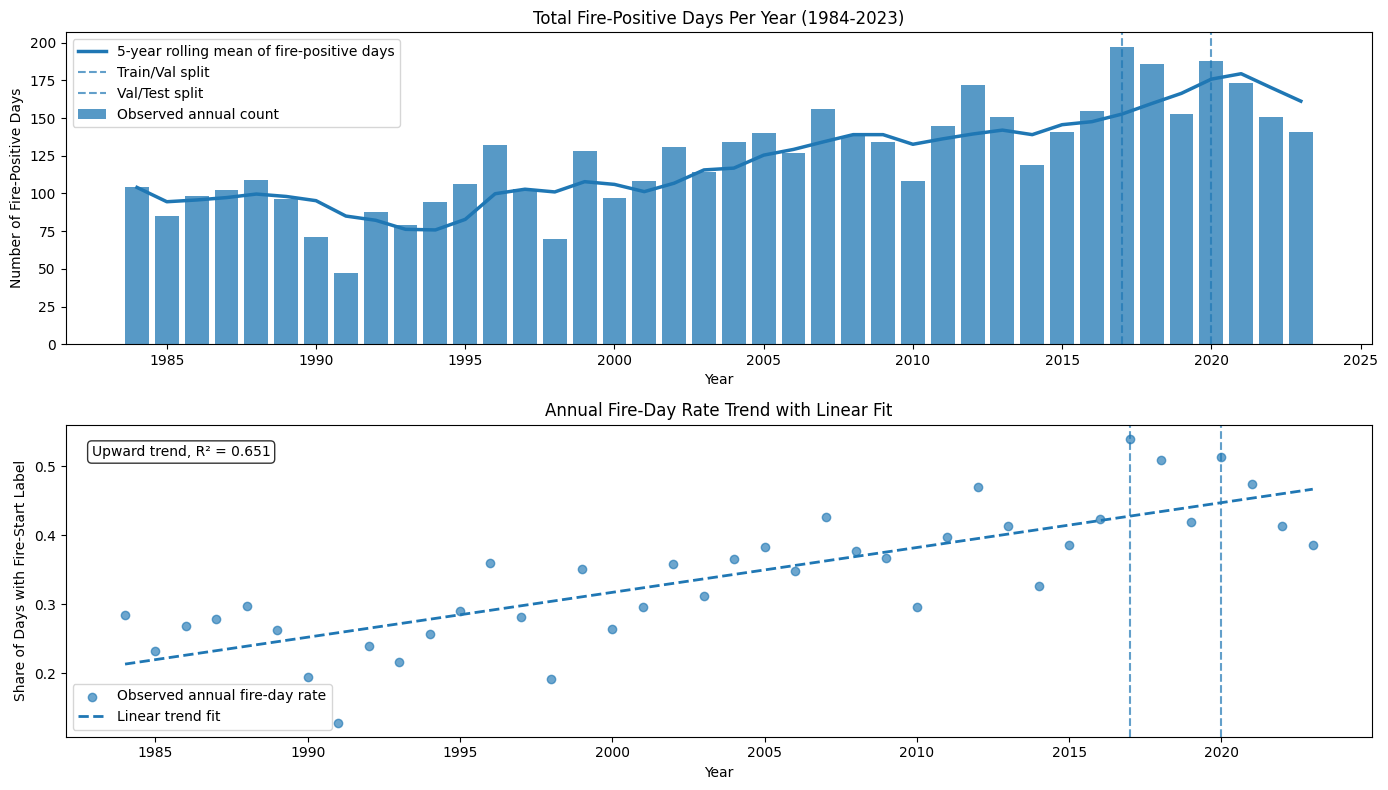

,slope_per_year,r_squared,p_value,significant_at_0_05,implied_change_1984_2023
0,0.0065,0.6514,0.0,True,0.2535


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_annual_fire_summary.csv
Saved: /content/wildfire_temporal_windowed_outputs/exploratory_fire_trend_stats.csv

Exploratory temporal analysis: fire-season shape by decade


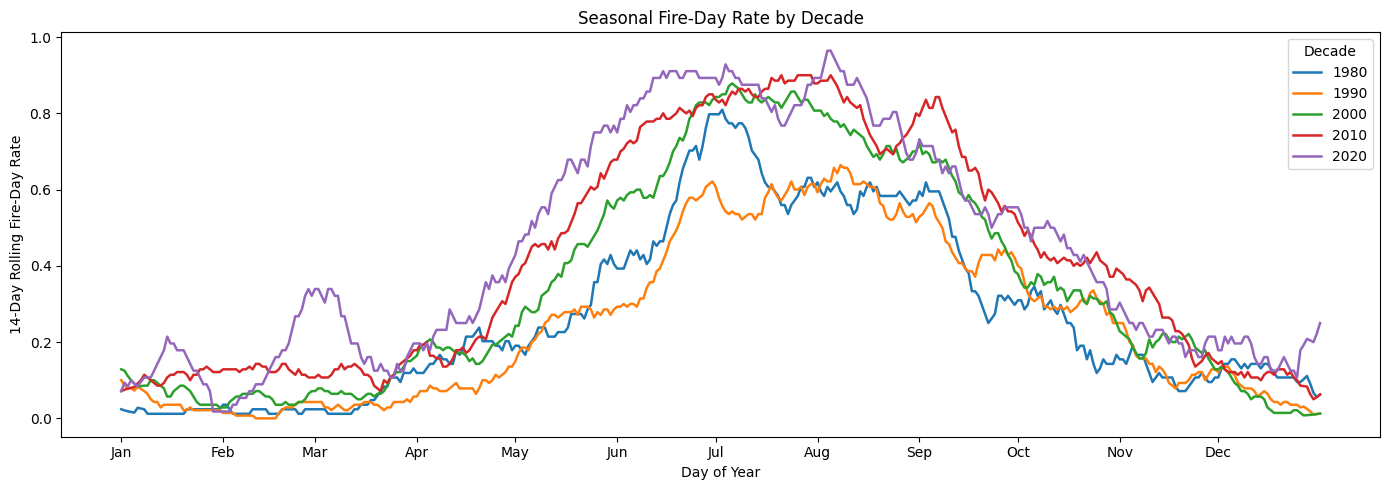

Saved: /content/wildfire_temporal_windowed_outputs/exploratory_decade_day_fire_probability.csv

Exploratory temporal analysis: first fire day trend


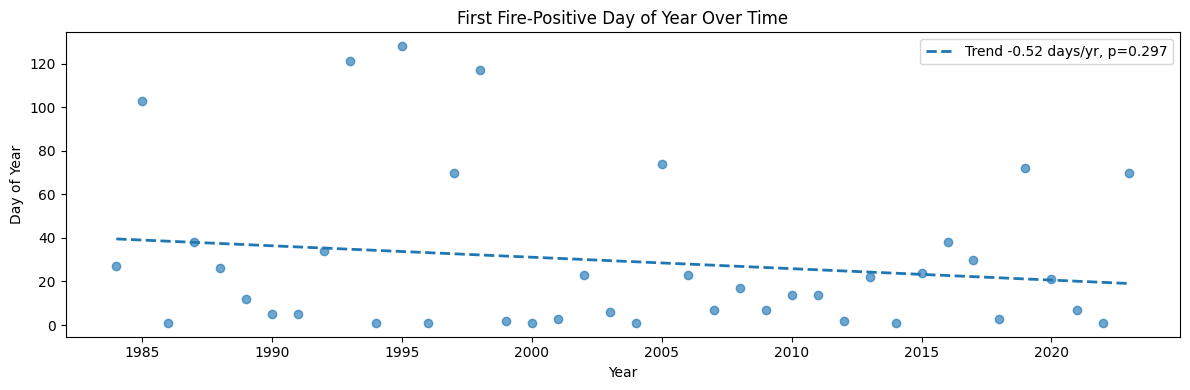

,slope_days_per_year,r_squared,p_value,significant_at_0_05,implied_shift_days
0,-0.5248,0.0285,0.2974,False,-20.4659


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_first_fire_day_by_year.csv
Saved: /content/wildfire_temporal_windowed_outputs/exploratory_first_fire_day_summary.csv

Exploratory temporal analysis: annual weather feature trends


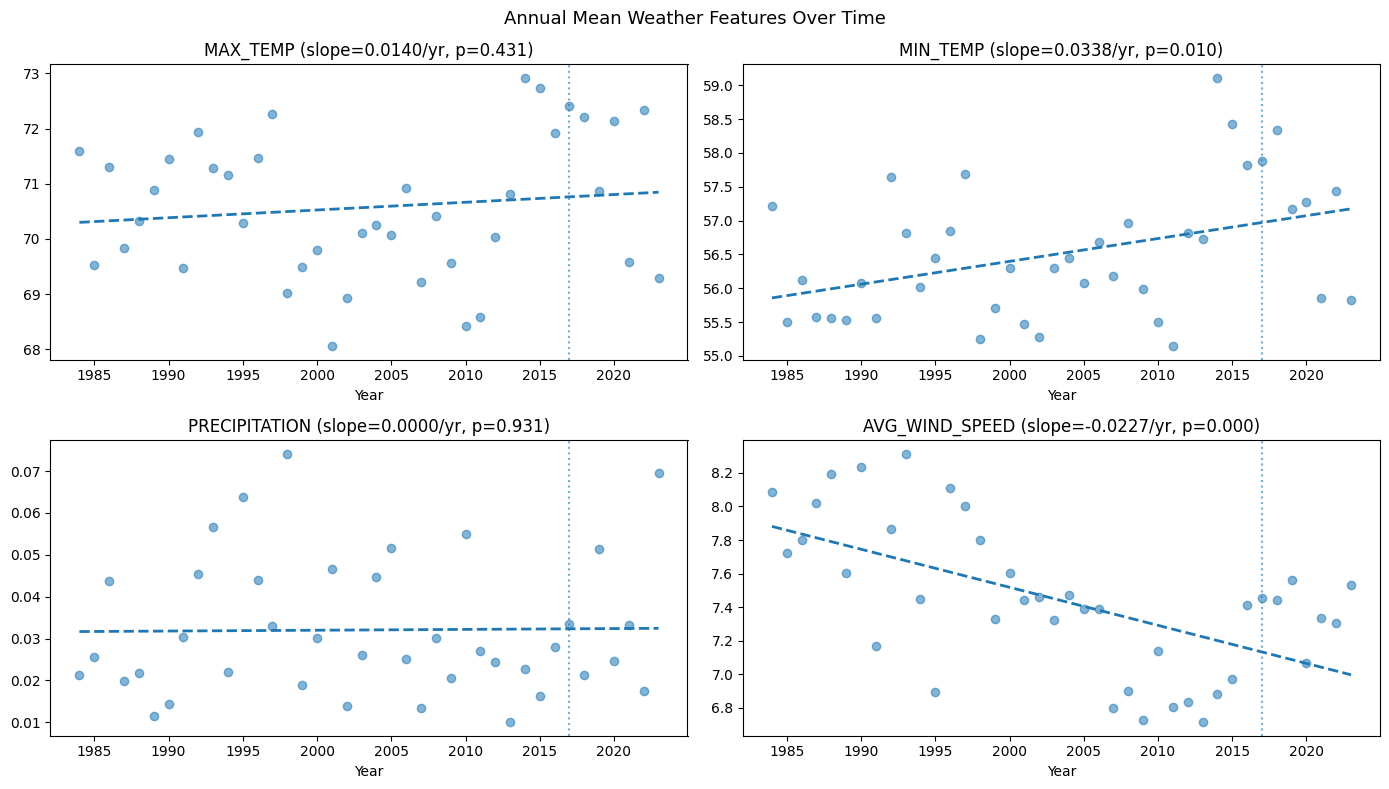

,feature,slope_per_year,r_squared,p_value,significant_at_0_05
0,MAX_TEMP,0.0140,0.0164,0.4312,False
1,MIN_TEMP,0.0338,0.1619,0.0101,True
2,PRECIPITATION,0.0000,0.0002,0.9313,False
3,AVG_WIND_SPEED,-0.0227,0.3524,0.0001,True


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_annual_weather_summary.csv
Saved: /content/wildfire_temporal_windowed_outputs/exploratory_weather_trend_summary.csv


In [26]:
# 14.1 Annual trends and seasonal shape from the exploratory analysis.
exploratory_temporal_data = prepare_exploratory_temporal_data(daily_data)

print_analysis_block("Exploratory temporal analysis: annual fire trend")
exploratory_annual_fire_summary, exploratory_fire_trend_stats_df = analyze_annual_fire_trend(exploratory_temporal_data)
display(exploratory_fire_trend_stats_df.round(4))
save_table(exploratory_annual_fire_summary, "exploratory_annual_fire_summary.csv")
save_table(exploratory_fire_trend_stats_df, "exploratory_fire_trend_stats.csv")

print_analysis_block("Exploratory temporal analysis: fire-season shape by decade")
exploratory_decade_day_summary = plot_fire_season_shape_by_decade(exploratory_temporal_data)
save_table(exploratory_decade_day_summary, "exploratory_decade_day_fire_probability.csv")

print_analysis_block("Exploratory temporal analysis: first fire day trend")
exploratory_first_fire_day_df, exploratory_first_fire_day_summary = analyze_first_fire_day_trend(exploratory_temporal_data)
display(exploratory_first_fire_day_summary.round(4))
save_table(exploratory_first_fire_day_df, "exploratory_first_fire_day_by_year.csv")
save_table(exploratory_first_fire_day_summary, "exploratory_first_fire_day_summary.csv")

print_analysis_block("Exploratory temporal analysis: annual weather feature trends")
exploratory_annual_weather_summary, exploratory_weather_trend_summary = analyze_annual_weather_trends(exploratory_temporal_data)
display(exploratory_weather_trend_summary.round(4))
save_table(exploratory_annual_weather_summary, "exploratory_annual_weather_summary.csv")
save_table(exploratory_weather_trend_summary, "exploratory_weather_trend_summary.csv")



Exploratory temporal analysis: ACF/PACF diagnostics


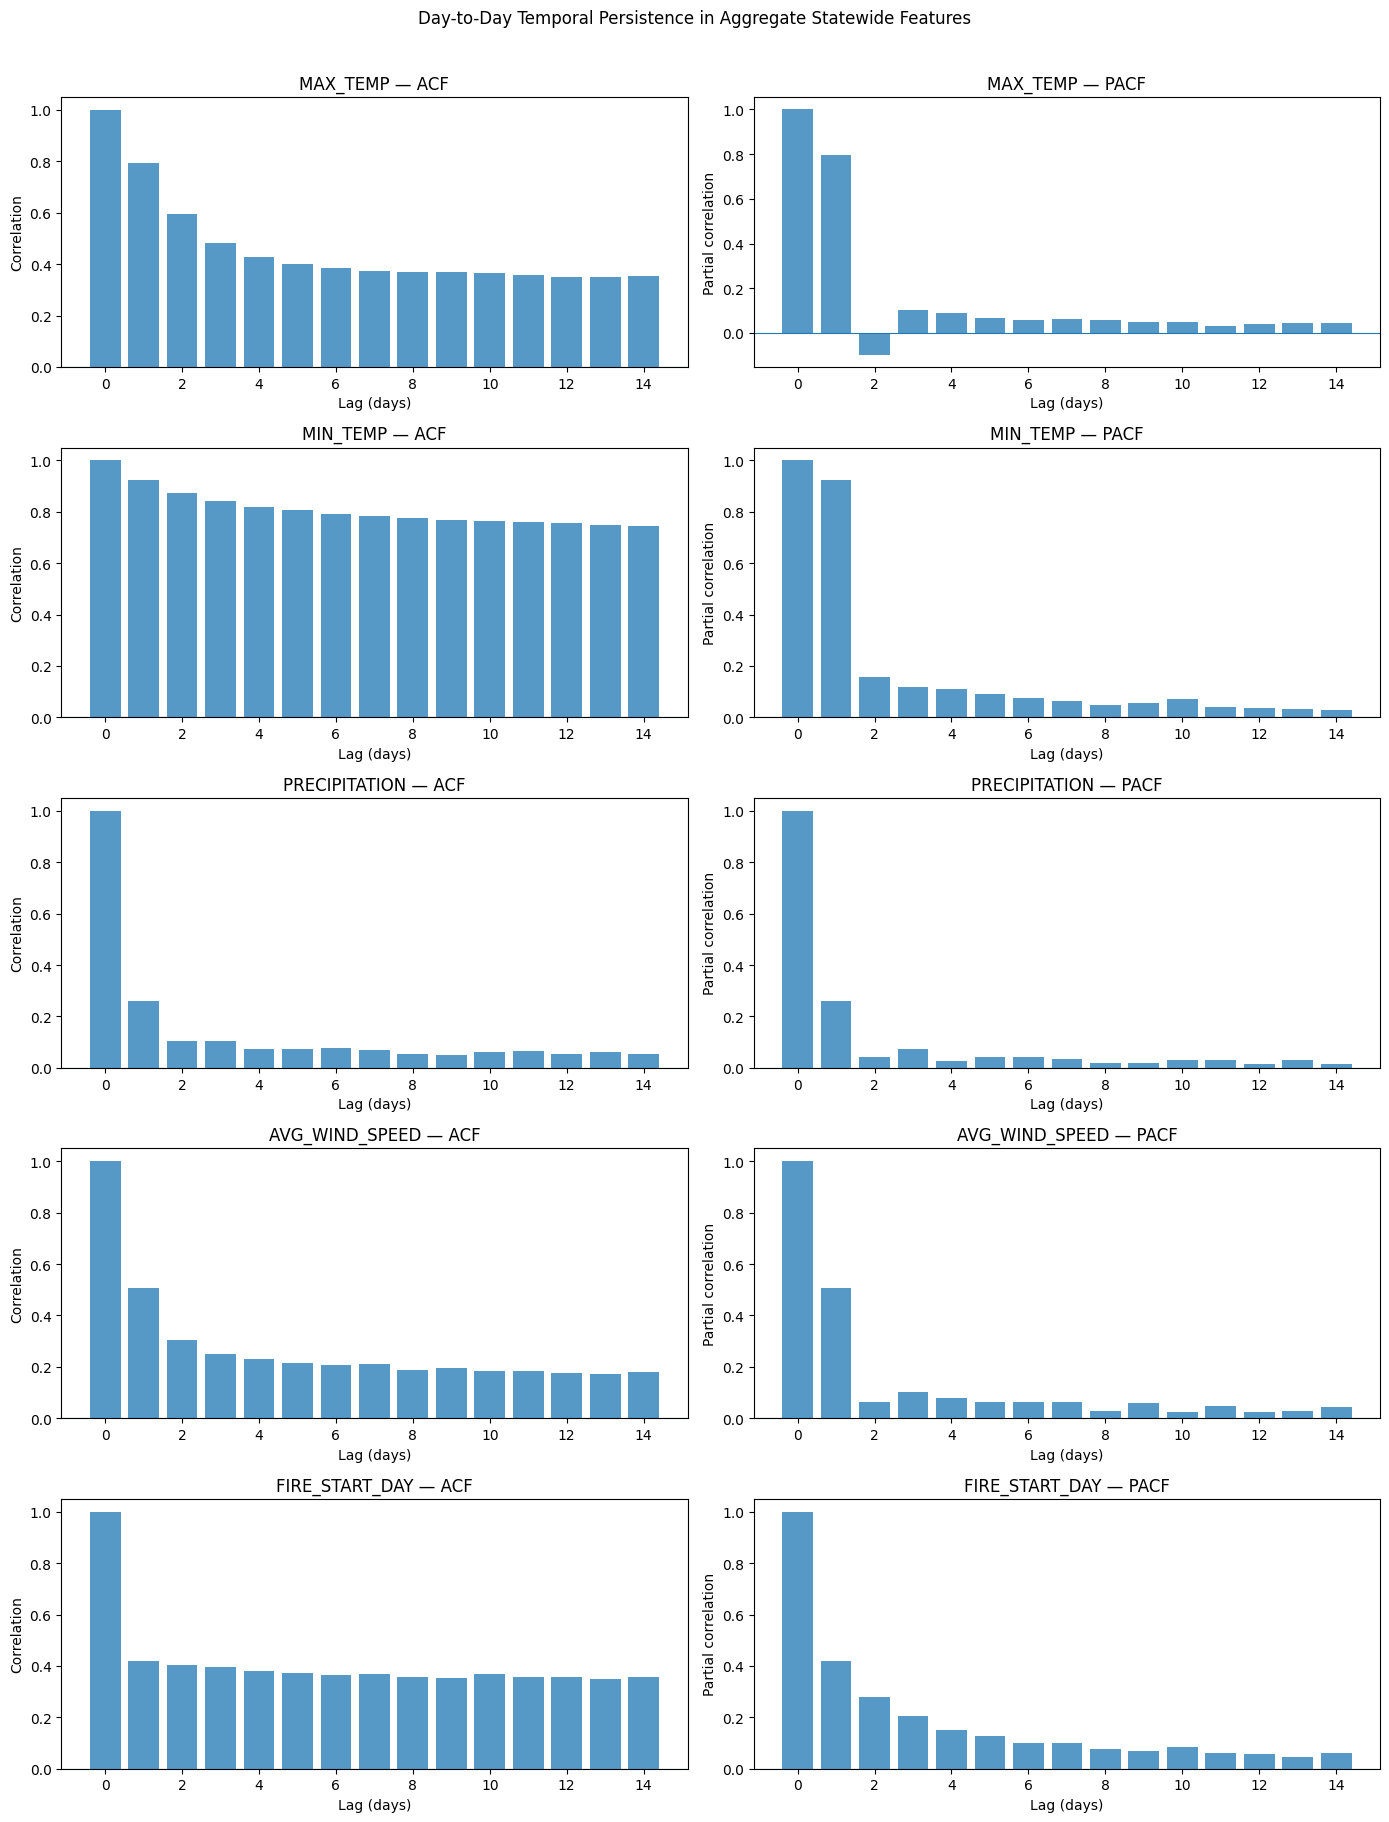


Exploratory temporal analysis: lag correlations with fire label


lag_days,1,2,3,5,7
feature,,,,,
AVG_WIND_SPEED,0.029,0.047,0.063,0.057,0.067
MAX_TEMP,0.351,0.325,0.309,0.288,0.270
MIN_TEMP,0.465,0.458,0.451,0.448,0.440
PRECIPITATION,-0.116,-0.114,-0.112,-0.109,-0.108
TEMP_RANGE,-0.099,-0.123,-0.134,-0.156,-0.169
WIND_TEMP_RATIO,-0.093,-0.070,-0.051,-0.050,-0.038


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_lag_correlation_table.csv

Exploratory temporal analysis: lag-1 autocorrelation by era


feature,AVG_WIND_SPEED,MAX_TEMP,MIN_TEMP,PRECIPITATION
era,,,,
1984-1999,0.5030,0.7921,0.9216,0.2398
2000-2009,0.5021,0.7769,0.9186,0.2609
2010-2017,0.4898,0.8102,0.9242,0.3030
2018-2023,0.4753,0.8055,0.9261,0.2708


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_era_autocorrelation.csv

Exploratory temporal analysis: fire-day autocorrelation by season


,season,lag_1_fire_day_autocorrelation,num_days
0,Winter,0.2724,3610
1,Spring,0.2482,3680
2,Summer,0.2034,3680
3,Fall,0.2261,3640


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_seasonal_fire_autocorrelation.csv


In [27]:
# 14.2 Autocorrelation and lag diagnostics.
print_analysis_block("Exploratory temporal analysis: ACF/PACF diagnostics")
plot_base_feature_acf_pacf(exploratory_temporal_data)

print_analysis_block("Exploratory temporal analysis: lag correlations with fire label")
exploratory_lag_correlation_table = compute_lag_correlation_table(
    exploratory_temporal_data,
    feature_names=["MAX_TEMP", "MIN_TEMP", "PRECIPITATION", "AVG_WIND_SPEED", "TEMP_RANGE", "WIND_TEMP_RATIO"],
    lag_days=[1, 2, 3, 5, 7],
)
display(exploratory_lag_correlation_table.pivot(index="feature", columns="lag_days", values="correlation_with_fire_day").round(3))
save_table(exploratory_lag_correlation_table, "exploratory_lag_correlation_table.csv")

print_analysis_block("Exploratory temporal analysis: lag-1 autocorrelation by era")
exploratory_era_autocorrelation_df = compute_autocorrelation_by_era(exploratory_temporal_data)
display(exploratory_era_autocorrelation_df.pivot(index="era", columns="feature", values="lag_1_autocorrelation").round(4))
save_table(exploratory_era_autocorrelation_df, "exploratory_era_autocorrelation.csv")

print_analysis_block("Exploratory temporal analysis: fire-day autocorrelation by season")
exploratory_seasonal_fire_autocorrelation_df = compute_seasonal_fire_autocorrelation(exploratory_temporal_data)
display(exploratory_seasonal_fire_autocorrelation_df.round(4))
save_table(exploratory_seasonal_fire_autocorrelation_df, "exploratory_seasonal_fire_autocorrelation.csv")



Exploratory temporal analysis: anomaly flags


,condition,fire_rate,num_days
0,Normal days,0.3404,14599
1,Extreme heat only,0.5971,546
2,Extreme wind only,0.1225,547
3,Extreme dry only,NaN,0
4,Low MIN_TEMP only,0.0431,255
5,Compound (2+ flags),0.1818,11


Compound anomaly days: 11 (0.001 rate)
Saved: /content/wildfire_temporal_windowed_outputs/exploratory_anomaly_rate_summary.csv


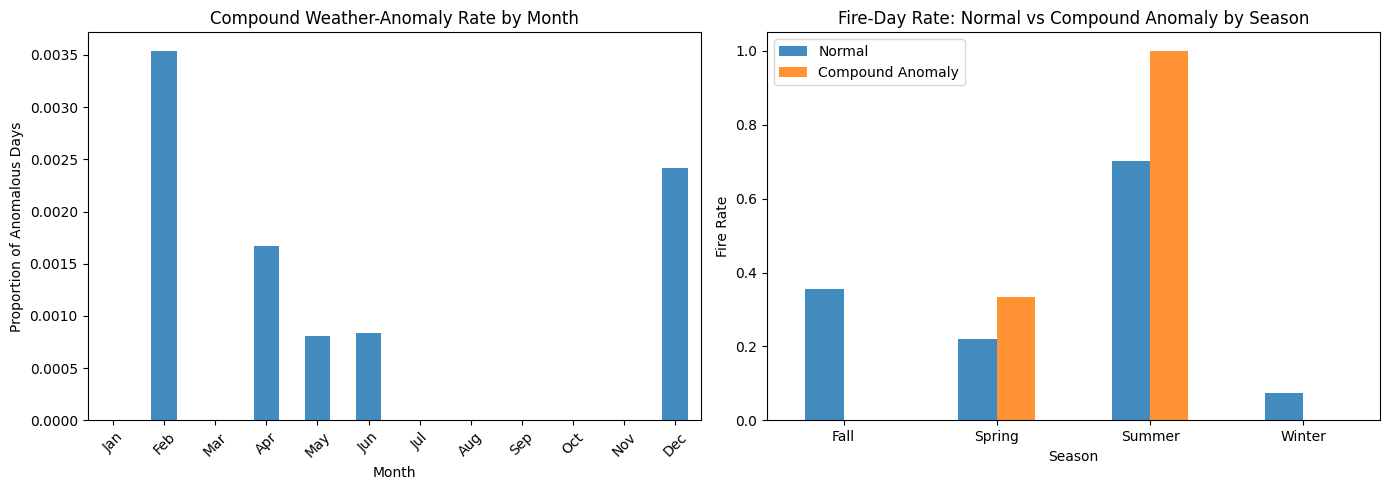


Exploratory temporal analysis: day-of-year fire probability


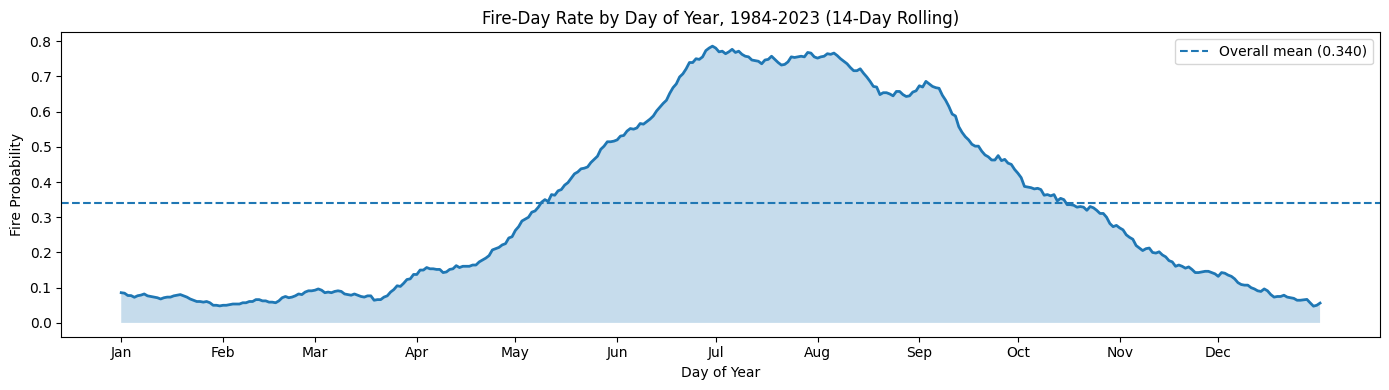

Saved: /content/wildfire_temporal_windowed_outputs/exploratory_day_of_year_fire_probability.csv

Exploratory temporal analysis: consecutive fire-day streaks


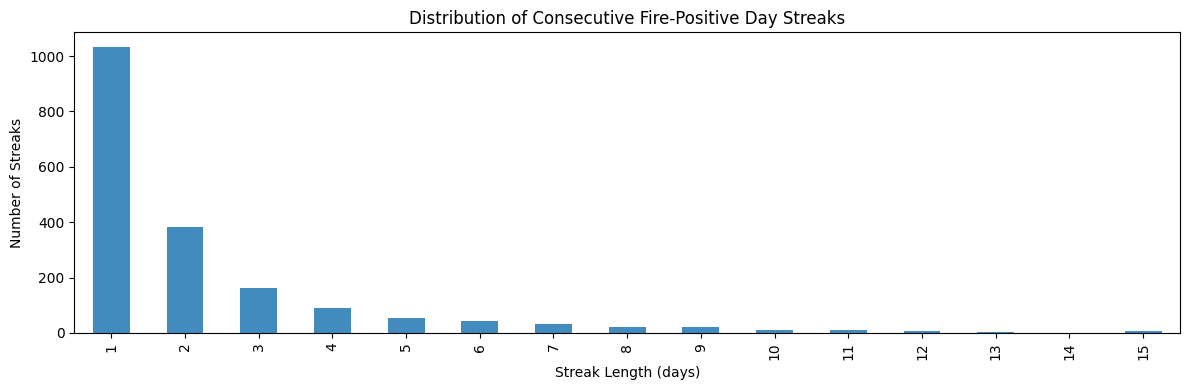

,total_streaks,mean_streak_days,median_streak_days,max_streak_days,single_day_streak_share,three_plus_day_streak_share,seven_plus_day_streak_share
0,1907,2.6067,1.0,80,0.5422,0.2569,0.0745


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_fire_streak_summary.csv
Saved: /content/wildfire_temporal_windowed_outputs/exploratory_fire_streak_distribution.csv

Exploratory temporal analysis: monthly fire-rate heatmap


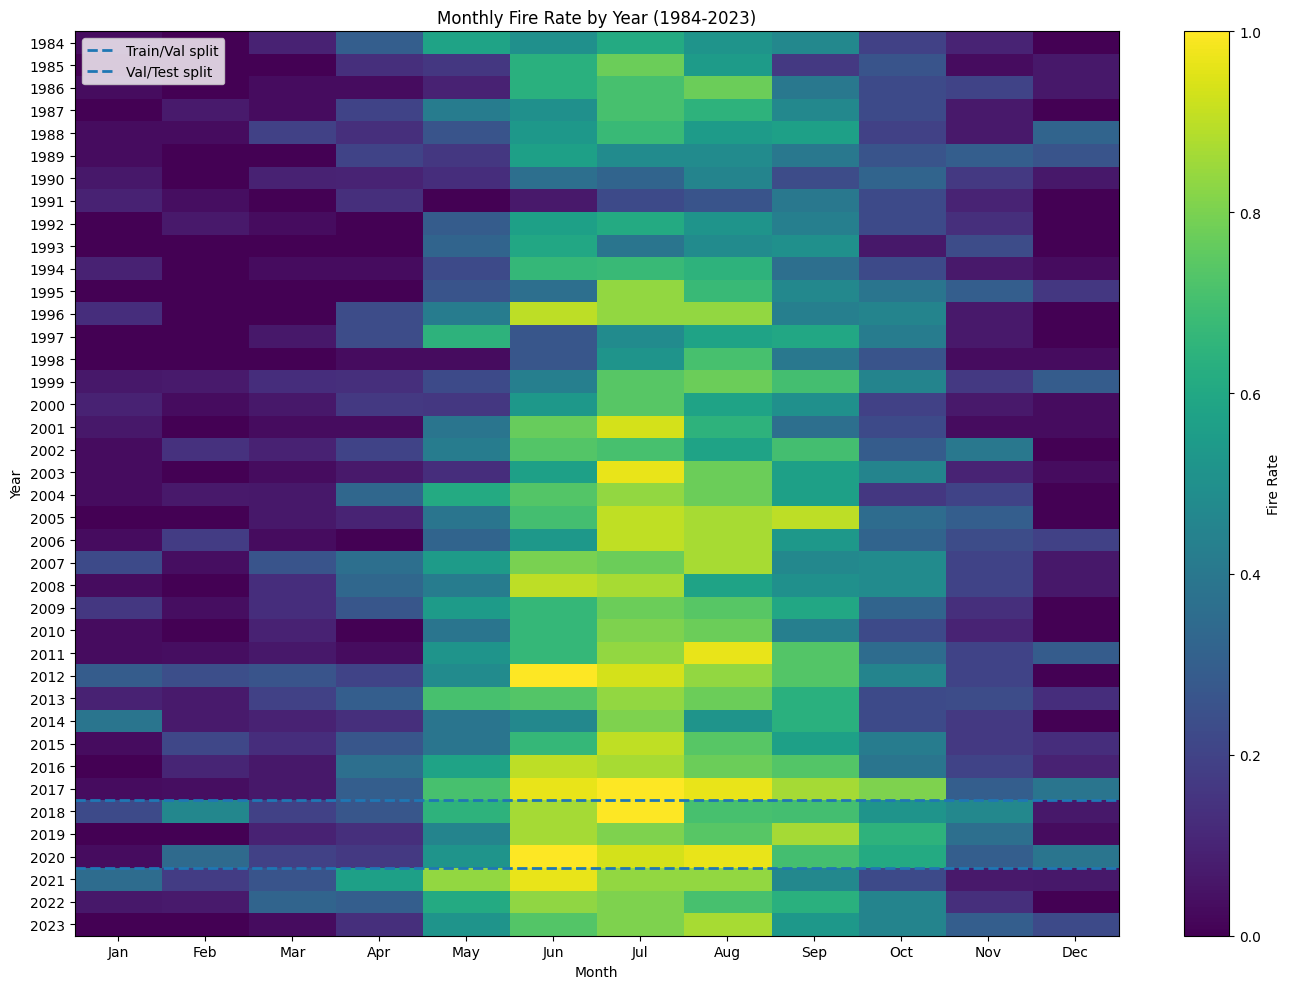

Saved: /content/wildfire_temporal_windowed_outputs/exploratory_monthly_fire_heatmap.csv


In [28]:
# 14.3 Anomaly, streak, and monthly fire-pattern diagnostics.
print_analysis_block("Exploratory temporal analysis: anomaly flags")
exploratory_anomaly_data = build_anomaly_flag_data(exploratory_temporal_data)
exploratory_anomaly_rate_summary = summarize_anomaly_fire_rates(exploratory_anomaly_data)
display(exploratory_anomaly_rate_summary.round(4))
print(f"Compound anomaly days: {int(exploratory_anomaly_data['COMPOUND_ANOM'].sum())} ({exploratory_anomaly_data['COMPOUND_ANOM'].mean():.3f} rate)")
save_table(exploratory_anomaly_rate_summary, "exploratory_anomaly_rate_summary.csv")
plot_anomaly_patterns(exploratory_anomaly_data)

print_analysis_block("Exploratory temporal analysis: day-of-year fire probability")
exploratory_day_of_year_fire_probability = plot_day_of_year_fire_probability(exploratory_temporal_data)
save_table(exploratory_day_of_year_fire_probability, "exploratory_day_of_year_fire_probability.csv")

print_analysis_block("Exploratory temporal analysis: consecutive fire-day streaks")
exploratory_fire_streak_summary, exploratory_fire_streak_distribution = summarize_fire_streaks(exploratory_temporal_data)
display(exploratory_fire_streak_summary.round(4))
save_table(exploratory_fire_streak_summary, "exploratory_fire_streak_summary.csv")
save_table(exploratory_fire_streak_distribution, "exploratory_fire_streak_distribution.csv")

print_analysis_block("Exploratory temporal analysis: monthly fire-rate heatmap")
exploratory_monthly_fire_heatmap = plot_monthly_fire_rate_heatmap(exploratory_temporal_data)
save_table(exploratory_monthly_fire_heatmap, "exploratory_monthly_fire_heatmap.csv")



Exploratory temporal diagnostic model: 6-row window + 1-day horizon
Train windows:      12410 (0.321 fire rate)
Validation windows: 1096 (0.481 fire rate)
Test windows:       1095 (0.425 fire rate)
Feature count:      66
Training exploratory diagnostic Random Forest on the sklearn CPU path.
Note: XGBoost and PyTorch sections use CUDA when available; sklearn RandomForest is CPU-bound unless RAPIDS/cuML is installed and intentionally substituted.
Diagnostic RF training/evaluation finished in 17.5s


,split,roc_auc,pr_auc,precision,recall,f1,threshold
0,validation,0.8425,0.8149,0.7644,0.7818,0.7730,0.3
1,test,0.8289,0.7544,0.6885,0.7699,0.7269,0.3


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_temporal_rf_metrics.csv


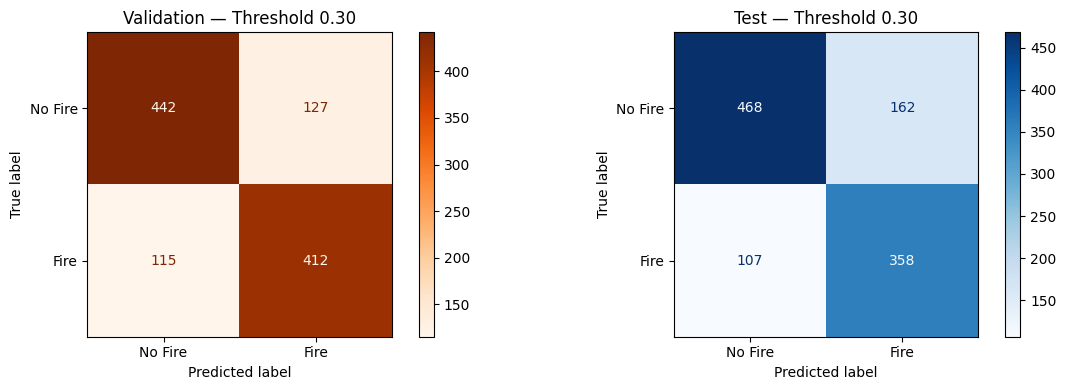

Top diagnostic Random Forest feature importances:


,feature,importance
0,MIN_TEMP_day5,0.0553
1,MIN_TEMP_day6,0.0507
2,MIN_TEMP_day2,0.0372
3,MIN_TEMP_day4,0.0354
4,MIN_TEMP_day3,0.0324
5,DAY_OF_YEAR_day6,0.0304
6,DAY_OF_YEAR_day5,0.0298
7,MIN_TEMP_day1,0.0296
8,DAY_OF_YEAR_day2,0.0277
9,DAY_OF_YEAR_day4,0.0276


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_temporal_rf_feature_importance.csv


In [29]:
# 14.4 Exploratory temporal-windowed temporal diagnostic Random Forest.
# This preserves the exploratory's diagnostic model output while keeping the code integrated with shared helpers.
print_analysis_block("Exploratory temporal diagnostic model: 6-row window + 1-day horizon")
exploratory_temporal_rf_result = run_exploratory_temporal_diagnostic_model(exploratory_temporal_data)
exploratory_temporal_rf_metrics_df = summarize_diagnostic_model_metrics(exploratory_temporal_rf_result)
display(exploratory_temporal_rf_metrics_df.round(4))
save_table(exploratory_temporal_rf_metrics_df, "exploratory_temporal_rf_metrics.csv")

plot_diagnostic_confusion_matrices(exploratory_temporal_rf_result)

exploratory_rf_feature_importance_df = extract_tree_feature_importance(
    exploratory_temporal_rf_result,
    exploratory_temporal_rf_result["split"]["feature_names"],
    top_n=40,
)
print("Top diagnostic Random Forest feature importances:")
display(exploratory_rf_feature_importance_df.head(20).round(4))
save_table(exploratory_rf_feature_importance_df, "exploratory_temporal_rf_feature_importance.csv")



Exploratory temporal diagnostic model: test-period error analysis
Matched test rows: 1095
Alignment check:   1.0000
True fire days:    465
Predicted fires:   520
Saved: /content/wildfire_temporal_windowed_outputs/exploratory_temporal_test_analysis.csv

False-negative rate by season


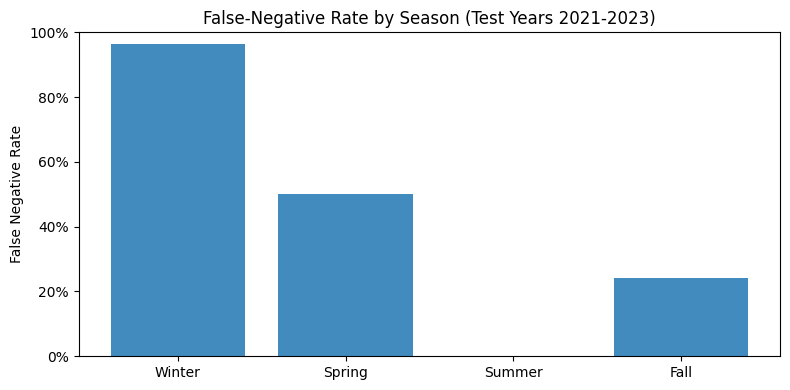

,season,false_negative_rate,missed_fire_days,total_fire_days
0,Winter,0.9655,28,29
1,Spring,0.5000,55,110
2,Summer,0.0000,0,227
3,Fall,0.2424,24,99


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_false_negative_by_season.csv

Error profile: missed fires, caught fires, and false positives


,error_group,count,compound_anomaly_rate,mean_max_temp,mean_avg_wind_speed,mean_precipitation,mean_model_probability,low_confidence_count_lt_0_2
0,false_negative,107,0.0,70.9252,7.1271,0.0378,0.1804,58
1,true_positive,358,0.0,74.1872,7.8199,0.0026,0.6198,0
2,false_positive,162,0.0,74.1358,7.3899,0.0149,0.5078,0


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_error_profile_summary.csv

Confidence and monthly error diagnostics


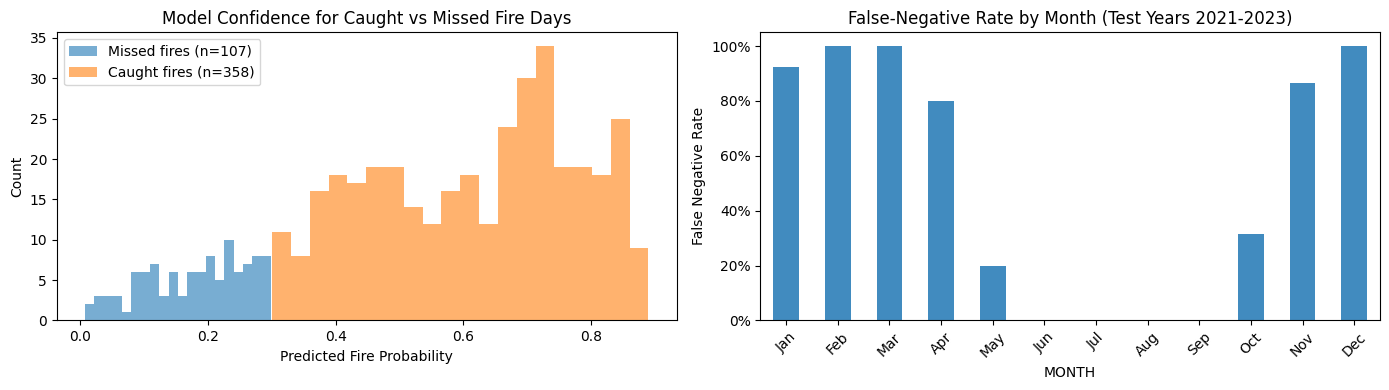

,MONTH,false_negative_rate
0,1,0.9231
1,2,1.0000
2,3,1.0000
3,4,0.8000
4,5,0.1967
5,6,0.0000
6,7,0.0000
7,8,0.0000
8,9,0.0000
9,10,0.3143


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_false_negative_by_month.csv

Probability calibration


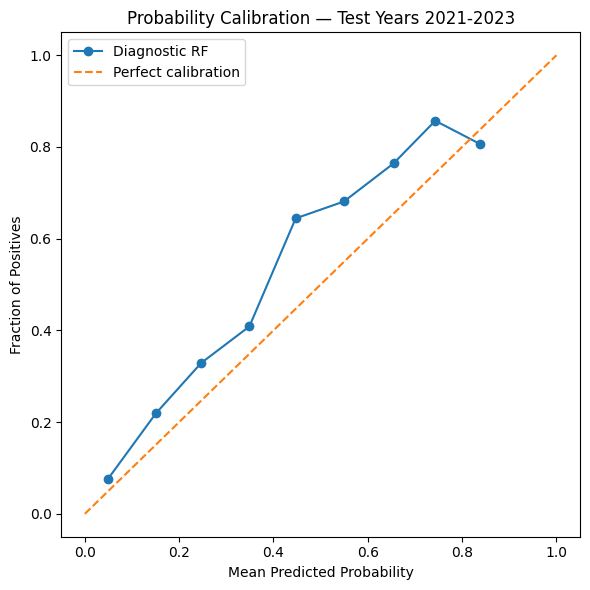

,mean_predicted_probability,observed_fire_rate
0,0.0494,0.0766
1,0.1507,0.2191
2,0.2466,0.3289
3,0.3489,0.4086
4,0.4471,0.6442
5,0.5495,0.6812
6,0.6545,0.7640
7,0.7431,0.8571
8,0.8390,0.8060


Saved: /content/wildfire_temporal_windowed_outputs/exploratory_probability_calibration.csv


In [30]:
# 14.5 Exploratory model-behavior diagnostics: seasonal false negatives, confidence, and calibration.
print_analysis_block("Exploratory temporal diagnostic model: test-period error analysis")
exploratory_temporal_test_analysis = build_temporal_test_analysis(
    exploratory_temporal_data,
    exploratory_anomaly_data,
    exploratory_temporal_rf_result,
)
save_table(exploratory_temporal_test_analysis, "exploratory_temporal_test_analysis.csv")

print_analysis_block("False-negative rate by season")
exploratory_false_negative_season_df = summarize_false_negatives_by_season(exploratory_temporal_test_analysis)
display(exploratory_false_negative_season_df.round(4))
save_table(exploratory_false_negative_season_df, "exploratory_false_negative_by_season.csv")

print_analysis_block("Error profile: missed fires, caught fires, and false positives")
exploratory_error_profile_df = summarize_error_profiles(exploratory_temporal_test_analysis)
display(exploratory_error_profile_df.round(4))
save_table(exploratory_error_profile_df, "exploratory_error_profile_summary.csv")

print_analysis_block("Confidence and monthly error diagnostics")
exploratory_false_negative_month_df = plot_confidence_and_monthly_errors(exploratory_temporal_test_analysis)
display(exploratory_false_negative_month_df.round(4))
save_table(exploratory_false_negative_month_df, "exploratory_false_negative_by_month.csv")

print_analysis_block("Probability calibration")
exploratory_calibration_summary_df = plot_probability_calibration(exploratory_temporal_test_analysis)
display(exploratory_calibration_summary_df.round(4))
save_table(exploratory_calibration_summary_df, "exploratory_probability_calibration.csv")


In [31]:
# 14.6 Exploratory temporal analysis summary, rewritten to align with the later dataset-scope correction.
print_analysis_block("Exploratory temporal analysis summary")
print("""
FINDING 1 — Fire frequency changes over time.
Annual fire-rate analysis shows a clear upward trend across 1984-2023. This supports the use of chronological splits and helps explain why training-period choice matters.

FINDING 2 — Several weather features show aggregate day-to-day persistence.
MAX_TEMP and MIN_TEMP retain strong lag-1 autocorrelation. This explains why a temporal modeling direction originally seemed reasonable, but it does not by itself prove that rolling rows form same-location sequences.

FINDING 3 — Calendar and seasonality carry a large amount of signal.
The day-of-year fire probability curve and monthly heatmap show a strong seasonal prior. This helps explain why calendar-oriented features perform surprisingly well in the temporal-windowed models.

FINDING 4 — Winter fire days are harder under the temporal-windowed diagnostic model.
The diagnostic Random Forest catches summer fire days much more easily than winter fire days. This suggests that a statewide daily average may miss localized winter/offshore-wind fire conditions.

INTERPRETATION AFTER TA FEEDBACK
These temporal findings remain useful dataset context. They should be used to explain trends, seasonality, and model behavior, not to claim that the 6-row windowed setup is the final valid modeling scope. The row-level notebook should treat each row as an independent one-day observation.
""")



Exploratory temporal analysis summary

FINDING 1 — Fire frequency changes over time.
Annual fire-rate analysis shows a clear upward trend across 1984-2023. This supports the use of chronological splits and helps explain why training-period choice matters.

FINDING 2 — Several weather features show aggregate day-to-day persistence.
MAX_TEMP and MIN_TEMP retain strong lag-1 autocorrelation. This explains why a temporal modeling direction originally seemed reasonable, but it does not by itself prove that rolling rows form same-location sequences.

FINDING 3 — Calendar and seasonality carry a large amount of signal.
The day-of-year fire probability curve and monthly heatmap show a strong seasonal prior. This helps explain why calendar-oriented features perform surprisingly well in the temporal-windowed models.

FINDING 4 — Winter fire days are harder under the temporal-windowed diagnostic model.
The diagnostic Random Forest catches summer fire days much more easily than winter fire days. 

## 15. Consolidated temporal-windowed results

These tables summarize the old/exploratory branch. The row-level TA-aligned notebook should be the source of truth for final row-level 1-day modeling.

In [32]:
consolidated_tables = {}
for table_name in [
    "primary_results_df",
    "recent_history_results_df",
    "ablation_results_df",
    "broad_horizon_results_df",
    "shortlist_results_df",
    "shortlist_keeper_df",
    "temporal_robustness_results_df",
    "best_by_window_df",
    "advanced_results_df",
    "advanced_winners_df",
    "sequence_results_df",
    "sequence_winners_df",
    "tree_pr_summary_df",
    "error_type_summary_df",
    "errors_by_year_df",
    "errors_by_season_df",
    "recent_history_full_results_df",
    "sensitivity_summary_df",
    "full_ablation_results_df",
    "recent_targeted_ablation_results_df",
    "shortlist_delta_df",
    "advanced_baseline_reference_df",
    "advanced_delta_df",
    "sequence_delta_df",
    "exploratory_fire_trend_stats_df",
    "exploratory_first_fire_day_summary",
    "exploratory_weather_trend_summary",
    "exploratory_lag_correlation_table",
    "exploratory_era_autocorrelation_df",
    "exploratory_seasonal_fire_autocorrelation_df",
    "exploratory_anomaly_rate_summary",
    "exploratory_fire_streak_summary",
    "exploratory_temporal_rf_metrics_df",
    "exploratory_rf_feature_importance_df",
    "exploratory_false_negative_season_df",
    "exploratory_error_profile_df",
    "exploratory_false_negative_month_df",
    "exploratory_calibration_summary_df",
]:
    if table_name in globals():
        consolidated_tables[table_name] = globals()[table_name]

print("Available result tables:")
display(pd.DataFrame({
    "table_name": list(consolidated_tables.keys()),
    "num_rows": [len(table_data) for table_data in consolidated_tables.values()],
}))

for table_name in [
    "primary_results_df",
    "tree_pr_summary_df",
    "sensitivity_summary_df",
    "shortlist_keeper_df",
    "best_by_window_df",
    "advanced_winners_df",
    "sequence_winners_df",
]:
    if table_name in consolidated_tables:
        print(f"\n{table_name}:")
        display(consolidated_tables[table_name].round(4))

elapsed_minutes = (time.time() - NOTEBOOK_START_TIME) / 60
print(f"[DONE] Notebook finished in {elapsed_minutes:.2f} minutes.")
print(f"Output directory: {OUTPUT_DIR}")

Available result tables:


,table_name,num_rows
0,primary_results_df,5
1,recent_history_results_df,3
2,ablation_results_df,8
3,broad_horizon_results_df,28
4,shortlist_results_df,16
5,shortlist_keeper_df,4
6,temporal_robustness_results_df,25
7,best_by_window_df,5
8,advanced_results_df,12
9,advanced_winners_df,4



primary_results_df:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
0,primary_windowed_models,Dummy baseline,baseline_features,1,0.05,0.5000,0.4808,0.4808,1.0000,0.6494,0.5000,0.4247,0.4247,1.0000,0.5962
1,primary_windowed_models,Logistic Regression,baseline_features,1,0.45,0.8394,0.8050,0.7373,0.7989,0.7668,0.8036,0.7154,0.6787,0.7677,0.7205
2,primary_windowed_models,Random Forest,baseline_features,1,0.20,0.8385,0.8060,0.7088,0.8406,0.7691,0.8288,0.7646,0.6252,0.8538,0.7218
3,primary_windowed_models,XGBoost,baseline_features,1,0.35,0.8429,0.8210,0.7369,0.8027,0.7684,0.8291,0.7646,0.6562,0.8129,0.7262
4,primary_windowed_models,Tuned XGBoost,baseline_features,1,0.35,0.8441,0.8212,0.7420,0.7970,0.7685,0.8296,0.7688,0.6584,0.7957,0.7205



tree_pr_summary_df:


...


advanced_winners_df:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned
0,advanced_refinement,Tuned Random Forest,baseline_features,1,0.30,0.8432,0.8144,0.7625,0.7799,0.7711,0.8294,0.7542,0.6901,0.7613,0.7239
1,advanced_refinement,Tuned Random Forest,engineered_features,3,0.20,0.8958,0.9529,0.8358,0.9051,0.8691,0.8757,0.9360,0.7985,0.9255,0.8573
2,advanced_refinement,MLP,engineered_features,7,0.10,0.9180,0.9787,0.8969,0.9543,0.9247,0.8782,0.9633,0.8624,0.9387,0.8989
3,advanced_refinement,Tuned Random Forest,engineered_features,10,0.15,0.8953,0.9801,0.8803,0.9859,0.9301,0.8629,0.9675,0.8535,0.9843,0.9143



sequence_winners_df:


,section,model,feature_set,horizon_days,best_threshold,val_roc_auc,val_pr_auc,val_precision_tuned,val_recall_tuned,val_f1_tuned,test_roc_auc,test_pr_auc,test_precision_tuned,test_recall_tuned,test_f1_tuned,best_epoch
0,sequence_models,GRU,baseline_features,1,0.25,0.8509,0.8265,0.7500,0.8083,0.7781,0.8264,0.7547,0.6778,0.7871,0.7284,34
1,sequence_models,GRU,engineered_features,3,0.25,0.9020,0.9501,0.8584,0.9104,0.8836,0.8819,0.9401,0.8218,0.8819,0.8507,1
2,sequence_models,LSTM,engineered_features,7,0.25,0.9177,0.9789,0.8887,0.9577,0.9219,0.8658,0.9604,0.8406,0.9517,0.8927,3
3,sequence_models,LSTM,engineered_features,10,0.20,0.9146,0.9838,0.8964,0.9730,0.9331,0.8671,0.9695,0.8724,0.9564,0.9125,8


[DONE] Notebook finished in 32.33 minutes.
Output directory: /content/wildfire_temporal_windowed_outputs
